## CNN for Fossil Classification

In [1]:
# Import dependencies
import numpy as np 
import keras
from keras import layers
import tensorflow_datasets as tfds
from tensorflow import data as tf_data
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import random
from skimage import io
import pandas as pd
import gc
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# You don't need this unless you are using google colab - this was to get my data to read
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

First, we import and split the data into testing, training, and validation sets. This should be written as a function so we can test on different folds during cross validation, where we will tune hyperparameters. 

In [2]:
# This file path will need to change
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
header_name = 'samples'

# Takes in a list of samples (csv) and a target opb, opc, etc and returns a random sample as a string
def GetRandomThinSections(target, samplelist, headername, num_sections):
    target = str(target)

    # Filter list of samples so we only deal with those involving target
    filtered_samples = samplelist[samplelist[headername].str.contains(target)]
    
    #randomly select one row (ie one thin section)
    if not filtered_samples.empty:
        random_thin_sections = filtered_samples.sample(n=num_sections).to_string(index=False, header=False) # Select 1 random row
        return random_thin_sections
    else:
        print(f"No rows found with '{target}' in 'samples'")


In [2]:
#TO DO: Edit so we also get labels, wrap model in a function, write k fold CV for params
# 
#  For each opx (x = b thru f) we will hold back one total thin section and all of its related patches for testing data

# This function takes in a folder of patches and pre-determined sections to remove and splits into train, test, val data
def TrainTestValSplit(image_folder, sections):
    #image_folder = input_patches
    # randomly select a thin section (thin_section_nums)
    #thin_sections = random.sample(thin_section_nums, num_sections)
    #thin_sections = [str(ts) for ts in thin_sections]

    # Initialize empty lists
    test_data_names = []
    validation_data_names = []
    training_data_names = []
    remaining_data_names = []
    remaining_data = []
    test_data = []
    train_data = []
    val_data = []

    # Loop through targets to pull one random thin section and add to test data
    for section in sections:
        # Add thin sections corresponding to random choice to test data, then split remaining data into test and validation sets
        for filename in os.listdir(image_folder):
            if filename.lower().endswith((".jpg", ".png", ".jpeg")):
                filepath = os.path.join(image_folder, filename)
            if section in filename:
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)
    # We now have the names of the files we want.
    # Now, split remaining data into training and validation sets at random
    print(f"Test Data Names from {image_folder}")
    print(test_data_names)
    random.shuffle(remaining_data_names) #randomly shuffles remaining image patches
    split = int(len(remaining_data_names) * 0.8)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]

    # Read in images to add to data
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    #Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data
    
augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    #layers.RandomRotation(0.25)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x


2026-09-28 15:07:20.359708: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-09-28 15:07:20.359744: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-09-28 15:07:20.359751: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
I0000 00:00:1790633240.359773   36125 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1790633240.359834   36125 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:

# Change file paths depending on your data - note that fossils but not centered and center fossils are classified as being fossil posiive here
center_folder = "../../Data/Center_Fossil"
fossil_nocenter_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"
targets = ["opb", "opc", "opd", "ope", "opf"]
sections = []

#This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
for target in targets:
    test_section = GetRandomThinSections(target, image_samples, header_name)
    sections.append(test_section)
print("Sections Isolated for Testing:")
print(sections)
sections = ['opb_76.4', 'opc_64.1', 'opd_0.0', 'ope_70.0', 'opf_44.9']
print("Sections that match center classification algorithm")
print(sections)

train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(fossil_nocenter_folder, sections)
train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

# Now, get label data setting fossils to 1 and no fossil to 0

Y_train = np.concatenate([np.ones(train_center.shape[0]), np.zeros(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
Y_val = np.concatenate([np.ones(val_center.shape[0]), np.zeros(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
Y_test = np.concatenate([np.ones(test_center.shape[0]), np.zeros(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

TypeError: GetRandomThinSections() missing 1 required positional argument: 'num_sections'

In [11]:
# Transform numpy arrays to tf datasets

training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))


2026-09-17 12:11:47.483334: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


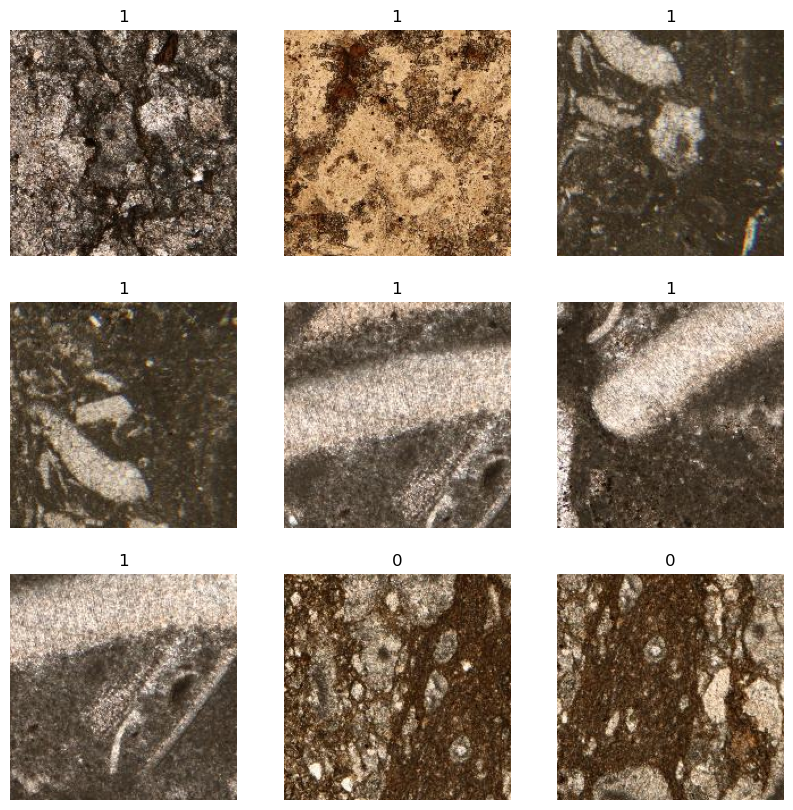

In [12]:

# Shuffle data
training_data = training_data.shuffle(len(Y_train))
validation_data = validation_data.shuffle(len(Y_val))
#testing_data = testing_data.shuffle(len(Y_test))

# Verify we did this correctly by plotting
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(testing_data.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(int(label))
    plt.axis("off")



We will use transfer learning using different pre-trained models on the imagenet dataset. We first train the Xception model. 

In [13]:
# Our images are already resized, but we could include optional resizing in the final model
# We start with data augmentation
augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    #layers.RandomRotation(0.25)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x

training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
)
# Create augmented data - Check with Lucy about what we want to do here
#training_data = training_data.map(lambda x, y: (data_augmentation(x), y))

nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

#aug_nonfossil_1 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
#aug_nonfossil_2 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
augfossil = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))
augfossil2 = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))
augfossil3 = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))

#training_data = training_data.concatenate(aug_nonfossil_1)
training_data = training_data.concatenate(augfossil)
training_data = training_data.concatenate(augfossil2)
training_data = training_data.concatenate(augfossil3)

training_data = training_data.shuffle(1000)
#training_data = training_data.concatenate(augmented_data)

# Visualize training data with augmented data
#plt.figure(figsize=(10, 10))
#for i, (image, label) in enumerate(augmented_data.take(9)):
 #   ax = plt.subplot(3, 3, i + 1)
 #   plt.imshow(image)
 #   plt.title(int(label))
 #   plt.axis("off")
#print(augmented_data)

In [14]:
# Batch and prefetch data ?

batch_size = 36 # this could change

training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()

2026-09-17 12:11:56.056640: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-09-17 12:11:56.098388: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


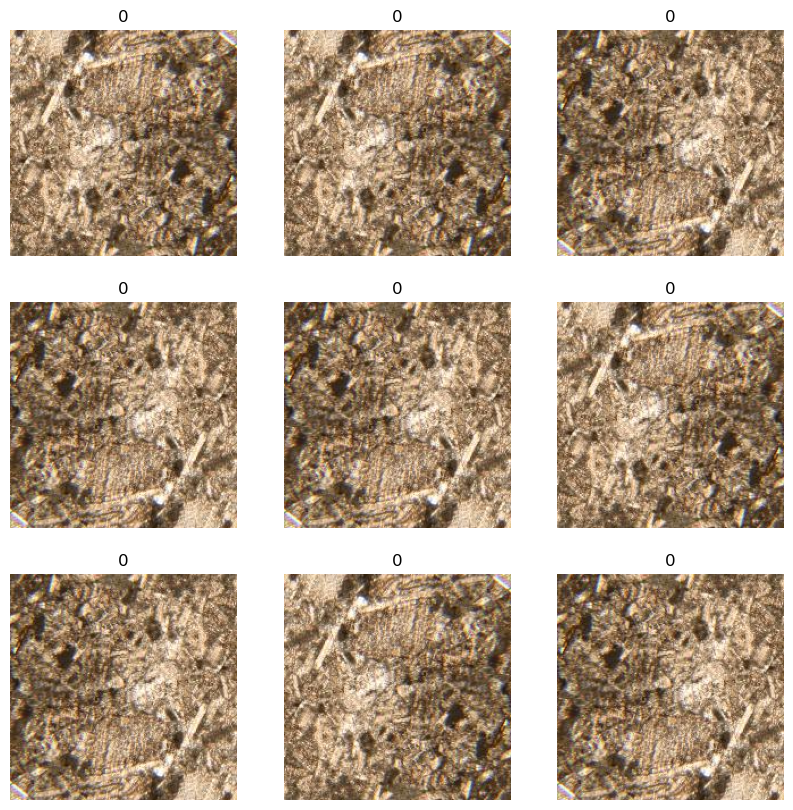

In [15]:
# Visualize augmented data

for images, labels in training_data.take(1):
    plt.figure(figsize=(10, 10))
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(np.expand_dims(first_image, 0))
        plt.imshow(np.array(augmented_image[0]).astype("int32"))
        plt.title(int(labels[0]))
        plt.axis("off")

In [16]:
# We will use transfer learning using different pre-trained models on the imagenet dataset

# Create the base model with the pre-trained imagenet weights
base_model = keras.applications.Xception(
    weights = 'imagenet',
    input_shape = (200, 200, 3),
    include_top = False) # Why do we not include imagenet at the top? 

# Freeze the base model weights (they will not be trained)

base_model.trainable = False

In [17]:
# Create a new model that goes on top of the base imagenet model
inputs = keras.Input(shape = (200, 200, 3))
# We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
scale_layer = keras.layers.Rescaling(scale = 1/127.5, offset = -1)
x = scale_layer(inputs)

# We want to keep batchnorm layers of base model in inference (predict) mode so we do not train of them. 
# Make sure that base model is running on inference mode

x = base_model(x, training = False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.1)(x)
outputs = keras.layers.Dense(1, activation = 'sigmoid')(x)
model = keras.Model(inputs, outputs)

model.summary(show_trainable = True)
# I think we should play with the layers we use here. We should try the setup they have, but maybe add more or different layers depending on how well the model does. 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 7, 7, 2048)    │ 20,861,480 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [18]:
# Train the new top layer of the model
model.compile(
    optimizer = keras.optimizers.Adam(), # play with this also
    loss = keras.losses.BinaryCrossentropy(), #check this also
    metrics = [keras.metrics.BinaryAccuracy(), keras.metrics.AUC(), keras.metrics.Precision, keras.metrics.Recall(), keras.metrics.SpecificityAtSensitivity(0.9)]
)

epochs = 10 # also play with this
print("Fitting top layer of model")
history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data)

Fitting top layer of model
Epoch 1/10
    165/Unknown 92s 549ms/step - auc: 0.6638 - binary_accuracy: 0.7478 - loss: 0.5513 - precision: 0.6119 - recall: 0.3093 - specificity_at_sensitivity: 0.2297

/opt/miniconda3/envs/mlgeo/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


165/165 ━━━━━━━━━━━━━━━━━━━━ 118s 710ms/step - auc: 0.8558 - binary_accuracy: 0.7954 - loss: 0.4593 - precision: 0.8541 - recall: 0.7671 - specificity_at_sensitivity: 0.4842 - val_auc: 0.7130 - val_binary_accuracy: 0.2453 - val_loss: 1.8045 - val_precision: 0.2436 - val_recall: 1.0000 - val_specificity_at_sensitivity: 0.3518
Epoch 2/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - auc: 0.7121 - binary_accuracy: 0.6819 - loss: 0.6759 - precision: 0.5146 - recall: 0.5139 - specificity_at_sensitivity: 0.3227

2026-09-17 12:26:51.416117: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


165/165 ━━━━━━━━━━━━━━━━━━━━ 796s 5s/step - auc: 0.8599 - binary_accuracy: 0.7893 - loss: 0.4668 - precision: 0.8163 - recall: 0.8070 - specificity_at_sensitivity: 0.5697 - val_auc: 0.7523 - val_binary_accuracy: 0.2465 - val_loss: 1.7239 - val_precision: 0.2439 - val_recall: 1.0000 - val_specificity_at_sensitivity: 0.4117
Epoch 3/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - auc: 0.8734 - binary_accuracy: 0.7984 - loss: 0.4444 - precision: 0.8225 - recall: 0.8180 - specificity_at_sensitivity: 0.6155 - val_auc: 0.7843 - val_binary_accuracy: 0.2581 - val_loss: 1.6414 - val_precision: 0.2468 - val_recall: 1.0000 - val_specificity_at_sensitivity: 0.4808
Epoch 4/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 80s 487ms/step - auc: 0.8870 - binary_accuracy: 0.8096 - loss: 0.4199 - precision: 0.8300 - recall: 0.8315 - specificity_at_sensitivity: 0.6586 - val_auc: 0.8062 - val_binary_accuracy: 0.2663 - val_loss: 1.5718 - val_precision: 0.2488 - val_recall: 1.0000 - val_specificity_at_sensitivity: 0.5300
Epoc

2026-09-17 12:34:18.513671: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


165/165 ━━━━━━━━━━━━━━━━━━━━ 76s 462ms/step - auc: 0.9057 - binary_accuracy: 0.8264 - loss: 0.3858 - precision: 0.8460 - recall: 0.8450 - specificity_at_sensitivity: 0.7013 - val_auc: 0.8394 - val_binary_accuracy: 0.2930 - val_loss: 1.4613 - val_precision: 0.2558 - val_recall: 1.0000 - val_specificity_at_sensitivity: 0.6114
Epoch 7/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 76s 464ms/step - auc: 0.9129 - binary_accuracy: 0.8328 - loss: 0.3719 - precision: 0.8520 - recall: 0.8504 - specificity_at_sensitivity: 0.7248 - val_auc: 0.8522 - val_binary_accuracy: 0.3198 - val_loss: 1.4097 - val_precision: 0.2632 - val_recall: 1.0000 - val_specificity_at_sensitivity: 0.6375
Epoch 8/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 76s 462ms/step - auc: 0.9195 - binary_accuracy: 0.8418 - loss: 0.3590 - precision: 0.8598 - recall: 0.8585 - specificity_at_sensitivity: 0.7552 - val_auc: 0.8621 - val_binary_accuracy: 0.3349 - val_loss: 1.3680 - val_precision: 0.2676 - val_recall: 1.0000 - val_specificity_at_sensitivity: 0.6605


Note: I don't think two epochs was enough here. This is something we should go through with CV, plotting accuracy and loss over each iteration

In [19]:
# Fine tune entire model
base_model.trainable = True
model.summary(show_trainable=True)

model.compile(
    optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
    loss = keras.losses.BinaryCrossentropy(),
   metrics = [keras.metrics.BinaryAccuracy(), keras.metrics.AUC(), keras.metrics.Precision, keras.metrics.Recall(), keras.metrics.SpecificityAtSensitivity(0.9)] #check this -- we have a binary model so it should be ok
)

epochs = 3 #??
print("Fitting end-to-end model")
history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 7, 7, 2048)    │ 20,861,480 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,867,629 (79.60 MB)

 Trainable params: 20,809,001 (79.38 MB)

 Non-trainable params: 54,528 (213.00 KB)

 Optimizer params: 4,100 (16.02 KB)

Fitting end-to-end model
Epoch 1/3
165/165 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - auc_1: 0.7494 - binary_accuracy: 0.6965 - loss: 0.5909 - precision_1: 0.7294 - recall_1: 0.7314 - specificity_at_sensitivity_1: 0.4184 - val_auc_1: 0.8801 - val_binary_accuracy: 0.5616 - val_loss: 0.7572 - val_precision_1: 0.3557 - val_recall_1: 0.9904 - val_specificity_at_sensitivity_1: 0.6498
Epoch 2/3
165/165 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - auc_1: 0.9555 - binary_accuracy: 0.8812 - loss: 0.3295 - precision_1: 0.8674 - recall_1: 0.9311 - specificity_at_sensitivity_1: 0.8599 - val_auc_1: 1.0000 - val_binary_accuracy: 0.9186 - val_loss: 0.2605 - val_precision_1: 0.7491 - val_recall_1: 1.0000 - val_specificity_at_sensitivity_1: 1.0000
Epoch 3/3
165/165 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - auc_1: 0.9963 - binary_accuracy: 0.9678 - loss: 0.1882 - precision_1: 0.9578 - recall_1: 0.9862 - specificity_at_sensitivity_1: 0.9927 - val_auc_1: 1.0000 - val_binary_accuracy: 0.9965 - val_loss: 0.0838 - val_precision_1

In [20]:
# Validate model on test data
print("Test dataset evaluation:")
test_eval = model.evaluate(testing_data)

Test dataset evaluation:
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - auc_1: 1.0000 - binary_accuracy: 1.0000 - loss: 0.0940 - precision_1: 1.0000 - recall_1: 1.0000 - specificity_at_sensitivity_1: 1.0000 


We now test on data that the model has never seen before!

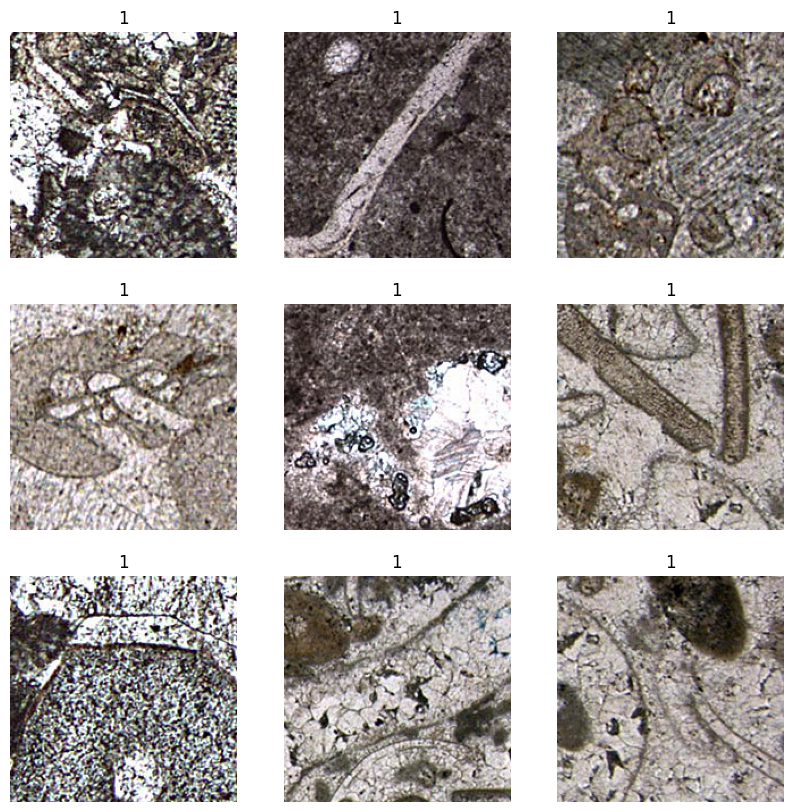

In [18]:
# First, upload and format carbonate world data as testing data
Unseen_CenterFossil_Data_Filepath = "/content/drive/MyDrive/MLGeoProject/CWfossil_center"
Unseen_EdgeFossil_Data_Filepath = "/content/drive/MyDrive/MLGeoProject/CWfossil_edge"
Unseen_NonFossil_Data_Filepath = "/content/drive/MyDrive/MLGeoProject/Carbonate_World_No_Fossil"

Unseen_CenterFossil_Data_Names = []
# Read images 
for filename in os.listdir(Unseen_CenterFossil_Data_Filepath):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        filepath = os.path.join(Unseen_CenterFossil_Data_Filepath, filename)
        Unseen_CenterFossil_Data_Names.append(filepath)
unseen_test_centerfossil_data = [io.imread(im) for im in Unseen_CenterFossil_Data_Names]
unseen_test_centerfossil_data = np.stack(unseen_test_centerfossil_data)

Unseen_EdgeFossil_Data_Names = []
for filename in os.listdir(Unseen_EdgeFossil_Data_Filepath):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        filepath = os.path.join(Unseen_EdgeFossil_Data_Filepath, filename)
        Unseen_EdgeFossil_Data_Names.append(filepath)
unseen_test_edgefossil_data = [io.imread(im) for im in Unseen_EdgeFossil_Data_Names]
unseen_test_edgefossil_data = np.stack(unseen_test_edgefossil_data)

Unseen_NonFossil_Data_Names = []
for filename in os.listdir(Unseen_NonFossil_Data_Filepath):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        filepath = os.path.join(Unseen_NonFossil_Data_Filepath, filename)
        Unseen_NonFossil_Data_Names.append(filepath)
unseen_test_nonfossil_data = [io.imread(im) for im in Unseen_NonFossil_Data_Names]
unseen_test_nonfossil_data = np.stack(unseen_test_nonfossil_data)

unseen_test_vals = np.concatenate([np.ones(unseen_test_centerfossil_data.shape[0]), np.zeros(unseen_test_edgefossil_data.shape[0]), np.zeros(unseen_test_nonfossil_data.shape[0])])
unseen_test_data = np.concatenate([unseen_test_centerfossil_data, unseen_test_edgefossil_data, unseen_test_nonfossil_data])

# Put into correct format
unseen_test_data = tf.data.Dataset.from_tensor_slices((unseen_test_data, unseen_test_vals))

# Verify via plotting
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(unseen_test_data.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(int(label))
    plt.axis("off")

# Batch
unseen_test_data = unseen_test_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()


In [19]:
print("Unseen Test Data Evaluation:")
unseen_test_eval = model.evaluate(unseen_test_data)

Unseen Test Data Evaluation:
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - auc_1: 0.5712 - binary_accuracy: 0.5600 - loss: 0.7816 - precision_1: 0.4000 - recall_1: 0.4444 - specificity_at_sensitivity_1: 0.2500


Plotting Accuracy and Loss

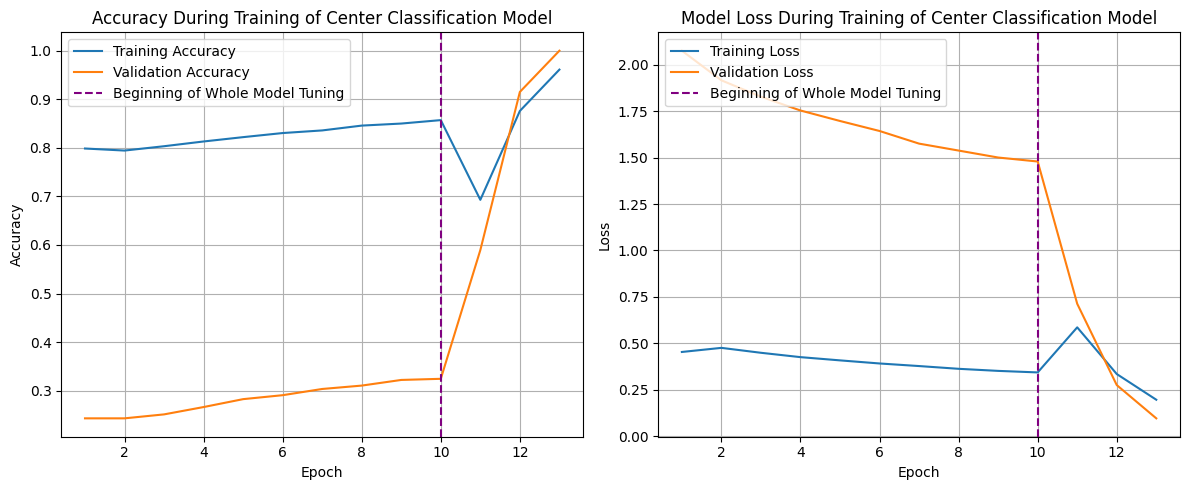

In [20]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(np.arange(1,14), np.concatenate([history_our_layers.history['binary_accuracy'], history_whole_model.history['binary_accuracy']]), label='Training Accuracy')
plt.plot(np.arange(1,14),np.concatenate([history_our_layers.history['val_binary_accuracy'],history_whole_model.history['val_binary_accuracy']]), label='Validation Accuracy')
plt.axvline(x = 10, linestyle = '--', color = 'purple', label = 'Beginning of Whole Model Tuning')
plt.title('Accuracy During Training of Center Classification Model')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.grid()
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(np.arange(1,14), np.concatenate([history_our_layers.history['loss'], history_whole_model.history['loss']]), label='Training Loss')
plt.plot(np.arange(1,14), np.concatenate([history_our_layers.history['val_loss'], history_whole_model.history['val_loss']]), label='Validation Loss')
plt.axvline(x = 10, linestyle = '--', color = 'purple', label = 'Beginning of Whole Model Tuning')
plt.title('Model Loss During Training of Center Classification Model')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.grid()
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [21]:
preds = model.predict(unseen_test_data)
predictions = np.zeros(preds.shape)
for i in range(len(preds)):
    if preds[i] >= 0.5:
        predictions[i] = 1
    else:
        predictions[i] = 0
print(predictions)
print(unseen_test_vals)

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step
[[1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]


In [22]:
i=0

for (feature, label) in nonfossil_train_data:
    i += 1
print(i)

j = 0
for (feature, label) in fossil_train_data:
    j+=1
print(j)

2598
834


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step  


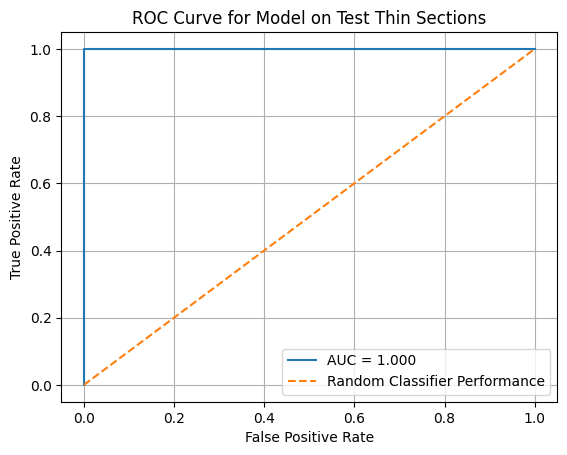

<Figure size 640x480 with 0 Axes>

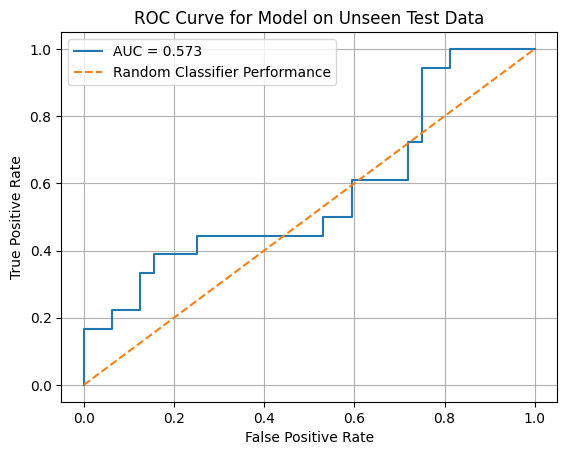

: 

In [ ]:
# ROC Curve Plot
predictions_test = model.predict(testing_data)
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(Y_test, predictions_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label = f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle = "--", label = "Random Classifier Performance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Model on Test Thin Sections")
plt.grid()
plt.legend()
plt.show()

plt.figure()
fpr, tpr, thresholds = roc_curve(unseen_test_vals, preds)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label = f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle = "--", label = "Random Classifier Performance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Model on Unseen Test Data")
plt.grid()
plt.legend()
plt.show()


### As an experiment, we train and test the model on different thin section test sets (randomly selected)

Iteration: 1
Sections Isolated for Testing in Iteration 1:
['opb_34.1', 'opc_39.6', 'opd_59.0', 'ope_34.0', 'opf_33.0']
['/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opc_39.6_patch4.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opd_59.0b_patch1.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opd_59.0a_patch1.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opd_59.0a_patch2.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opd_59.0c_patch1.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opd_59.0a_patch5.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opd_59.0c_patch2.png']
['/content/drive/MyDrive/MLGeoProject/No_Center_Fossil/resized_opc_39.6_patch3.png', '/content/drive/MyDrive/MLGeoProject/No_Center_Fossil/resized_opc_39.6_patch2.png', '/content/drive/MyDrive/MLGeoProject/No_Center_Fossil/resized_opc_39.6_patch1.png', '/content/drive/MyDrive/MLGeoProject/No_Center_Fossil

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_1 (Rescaling)     │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 7, 7, 2048)    │ 20,861,480 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

...

 Total params: 20,867,629 (79.60 MB)

 Trainable params: 20,809,001 (79.38 MB)

 Non-trainable params: 54,528 (213.00 KB)

 Optimizer params: 4,100 (16.02 KB)

Fitting end-to-end model iteration 5
Epoch 1/3
165/165 ━━━━━━━━━━━━━━━━━━━━ 157s 721ms/step - auc_11: 0.7630 - binary_accuracy: 0.6910 - loss: 0.5898 - precision_11: 0.7532 - recall_11: 0.6675 - specificity_at_sensitivity_11: 0.4139 - val_auc_11: 0.8797 - val_binary_accuracy: 0.5285 - val_loss: 0.8058 - val_precision_11: 0.3361 - val_recall_11: 0.9712 - val_specificity_at_sensitivity_11: 0.6498
Epoch 2/3
165/165 ━━━━━━━━━━━━━━━━━━━━ 87s 527ms/step - auc_11: 0.9557 - binary_accuracy: 0.8850 - loss: 0.3306 - precision_11: 0.8806 - recall_11: 0.9196 - specificity_at_sensitivity_11: 0.8682 - val_auc_11: 1.0000 - val_binary_accuracy: 0.8522 - val_loss: 0.3402 - val_precision_11: 0.6209 - val_recall_11: 1.0000 - val_specificity_at_sensitivity_11: 1.0000
Epoch 3/3
165/165 ━━━━━━━━━━━━━━━━━━━━ 86s 522ms/step - auc_11: 0.9963 - binary_accuracy: 0.9657 - loss: 0.1918 - precision_11: 0.9542 - recall_11: 0.9861 - specificity_at_sensitivity_11: 0.9954 - val_auc_11: 1.0000 - val_binary_accuracy: 0.9

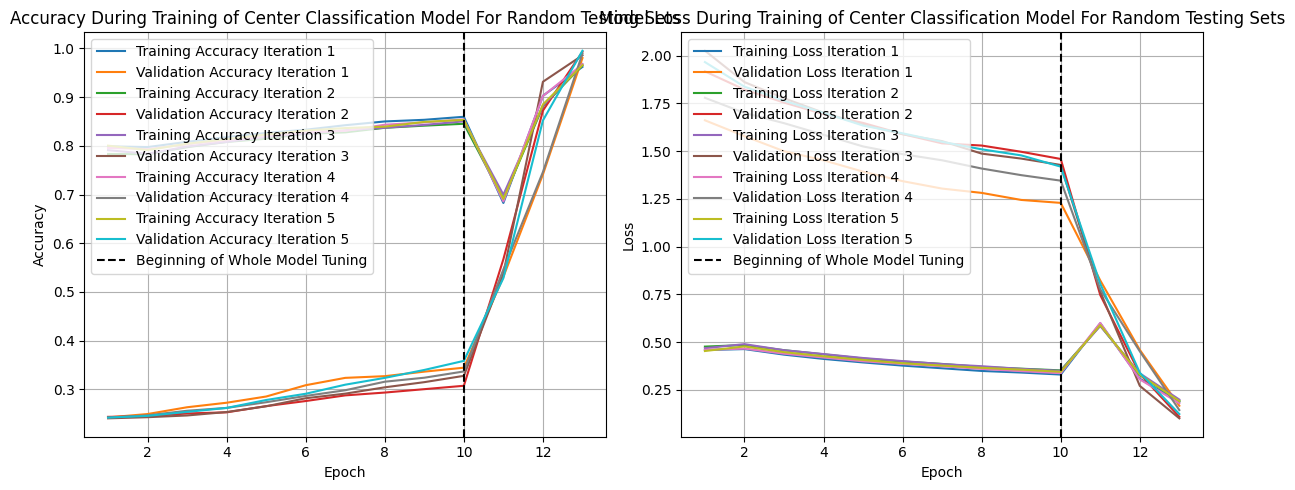

In [12]:
center_folder = "/content/drive/MyDrive/MLGeoProject/Center_Fossil"
fossil_nocenter_folder = "/content/drive/MyDrive/MLGeoProject/No_Center_Fossil"
no_fossil_folder = "/content/drive/MyDrive/MLGeoProject/No_Fossil"
targets = ["opb", "opc", "opd", "ope", "opf"]

plt.figure(figsize=(12, 5))

for i in range(1,6):
    print(f"Iteration: {i}")
    
    sections = []

    #This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
    for target in targets:
        test_section = GetRandomThinSections(target, image_samples, header_name)
        sections.append(test_section)
    print(f"Sections Isolated for Testing in Iteration {i}:")
    print(sections)

    train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
    train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(fossil_nocenter_folder, sections)
    train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

    # Now, get label data setting fossils to 1 and no fossil to 0

    Y_train = np.concatenate([np.ones(train_center.shape[0]), np.zeros(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
    Y_val = np.concatenate([np.ones(val_center.shape[0]), np.zeros(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
    Y_test = np.concatenate([np.ones(test_center.shape[0]), np.zeros(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
    training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
    validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
    testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

    # Transform numpy arrays to tf datasets

    training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
    validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
    testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))

    # Shuffle data
    training_data = training_data.shuffle(len(Y_train))
    validation_data = validation_data.shuffle(len(Y_val))
    testing_data = testing_data.shuffle(len(Y_test))

    # Augment Data
    training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
    )

    nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
    fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

    augfossil = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil2 = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil3 = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))

    training_data = training_data.concatenate(augfossil)
    training_data = training_data.concatenate(augfossil2)
    training_data = training_data.concatenate(augfossil3)

    training_data = training_data.shuffle(1000)

    # Batch and prefetch data 

    batch_size = 36 # this could change

    training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
    validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
    testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()

    # Create the base model with the pre-trained imagenet weights
    base_model = keras.applications.Xception(
        weights = 'imagenet',
        input_shape = (200, 200, 3),
        include_top = False) # Why do we not include imagenet at the top? 

    # Freeze the base model weights (they will not be trained)
    base_model.trainable = False

    # Create a new model that goes on top of the base imagenet model
    inputs = keras.Input(shape = (200, 200, 3))
    # We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
    scale_layer = keras.layers.Rescaling(scale = 1/127.5, offset = -1)
    x = scale_layer(inputs)

    # We want to keep batchnorm layers of base model in inference (predict) mode so we do not train of them. 
    # Make sure that base model is running on inference mode

    x = base_model(x, training = False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.1)(x)
    outputs = keras.layers.Dense(1, activation = 'sigmoid')(x)
    model = keras.Model(inputs, outputs)

    model.summary(show_trainable = True)

    # Train the new top layer of the model
    model.compile(
        optimizer = keras.optimizers.Adam(), # play with this also
        loss = keras.losses.BinaryCrossentropy(), #check this also
        metrics = [keras.metrics.BinaryAccuracy(), keras.metrics.AUC(), keras.metrics.Precision, keras.metrics.Recall(), keras.metrics.SpecificityAtSensitivity(0.9)]
    )

    epochs = 10 # also play with this
    print(f"Fitting top layer of model iteration {i}")
    history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data)

    # Fine tune entire model
    base_model.trainable = True
    model.summary(show_trainable=True)

    model.compile(
        optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
        loss = keras.losses.BinaryCrossentropy(),
        metrics = [keras.metrics.BinaryAccuracy(), keras.metrics.AUC(), keras.metrics.Precision, keras.metrics.Recall(), keras.metrics.SpecificityAtSensitivity(0.9)] #check this -- we have a binary model so it should be ok
    )

    epochs = 3 #??
    print(f"Fitting end-to-end model iteration {i}")
    history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data)

    # Validate model on test data
    print(f"Test dataset evaluation iteration {i}:")
    test_eval = model.evaluate(testing_data)


    plt.subplot(1, 2, 1)
    plt.plot(np.arange(1,14), np.concatenate([history_our_layers.history['binary_accuracy'], history_whole_model.history['binary_accuracy']]), label=f'Training Accuracy Iteration {i}')
    plt.plot(np.arange(1,14),np.concatenate([history_our_layers.history['val_binary_accuracy'],history_whole_model.history['val_binary_accuracy']]), label=f'Validation Accuracy Iteration {i}')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(np.arange(1,14), np.concatenate([history_our_layers.history['loss'], history_whole_model.history['loss']]), label=f'Training Loss Iteration {i}')
    plt.plot(np.arange(1,14), np.concatenate([history_our_layers.history['val_loss'], history_whole_model.history['val_loss']]), label=f'Validation Loss Iteration {i}')

plt.subplot(1, 2, 1)
plt.axvline(x = 10, linestyle = '--', color = 'black', label = 'Beginning of Whole Model Tuning')
plt.title('Accuracy During Training of Center Classification Model For Random Testing Sets')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.grid()
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.axvline(x = 10, linestyle = '--', color = 'black', label = 'Beginning of Whole Model Tuning')
plt.title('Model Loss During Training of Center Classification Model For Random Testing Sets')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.grid()
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


### Testing Number of Thin Sections Needed
Goals: Write a function that runs the model given a number of test sections. This will increase over time. Then, plot the end accuracy on the testing data vs. the number of training sections used. 

'''
import matplotlib.pyplot as plt

# Store results across multiple training runs
all_histories = []

for i, (X_train, y_train) in enumerate(list_of_training_sets):
    print(f"Training on set {i}")
    
    model = build_model()  # fresh model each time, if desired
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=32,
        verbose=0
    )
    
    all_histories.append(history.history)  # dict of lists: 'accuracy', 'val_accuracy', 'loss', etc.
'''

In [29]:
# This file path will need to change
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
header_name = 'samples'
center_folder = "../../Data/Center_Fossil"
fossil_nocenter_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"

# Takes in a list of samples (csv) returns a random sample as a string
def GetRandomThinSections(samplelist, num_sections):
    if samplelist.empty:
        print("No rows found in sample list")
        return []

    n = min(num_sections, len(samplelist))

    return (
        samplelist.iloc[:, 0]   # first (only) column, no header name needed
        .astype(str)
        .str.strip()
        .sample(n=n)
        .tolist()
    )

def TrainTestValSplit(image_folder, sections):
    test_data_names = []
    remaining_data_names = []

    # List the folder ONCE; each file is checked against ALL sections
    for filename in os.listdir(image_folder):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            filepath = os.path.join(image_folder, filename)
            if any(section in filename for section in sections):
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)

    print(f"Test Data Names from {image_folder}: {np.sort(test_data_names)}")

    # Split remaining data into training and validation sets at random
    random.shuffle(remaining_data_names)
    split = int(len(remaining_data_names) * 0.8)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]
    print(f"Training Data: {np.sort(training_data_names)}")
    print(f"Validation Data: {np.sort(validation_data_names)}")

    # Read in images
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    # Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data

augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    #layers.RandomRotation(0.25)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x

#TO DO: Edit so we also get labels, wrap model in a function, write k fold CV for params
# 
#  For each opx (x = b thru f) we will hold back one total thin section and all of its related patches for testing data

# This function takes in a folder of patches and pre-determined sections to remove and splits into train, test, val data
def TrainTestValSplit2(image_folder, sections):
    #image_folder = input_patches
    # randomly select a thin section (thin_section_nums)
    #thin_sections = random.sample(thin_section_nums, num_sections)
    #thin_sections = [str(ts) for ts in thin_sections]

    # Initialize empty lists
    test_data_names = []
    validation_data_names = []
    training_data_names = []
    remaining_data_names = []
    remaining_data = []
    test_data = []
    train_data = []
    val_data = []

    # Loop through targets to pull one random thin section and add to test data
    for section in sections:
        # Add thin sections corresponding to random choice to test data, then split remaining data into test and validation sets
        for filename in os.listdir(image_folder):
            if filename.lower().endswith((".jpg", ".png", ".jpeg")):
                filepath = os.path.join(image_folder, filename)
            if section in filename:
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)
    # We now have the names of the files we want.
    # Now, split remaining data into training and validation sets at random
    print(test_data_names)
    random.shuffle(remaining_data_names) #randomly shuffles remaining image patches
    split = int(len(remaining_data_names) * 0.8)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]
    print(f"Training Data: {np.sort(training_data_names)}")
    print(f"Validation Data: {np.sort(validation_data_names)}")

    # Read in images to add to data
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    #Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data
    
augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    #layers.RandomRotation(0.25)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x


def model_fit_numbersections(num_test_sections):
    center_folder = "../../Data/Center_Fossil"
    fossil_nocenter_folder = "../../Data/No_Center_Fossil"
    no_fossil_folder = "../../Data/No_Fossil"

    #This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
    sections = GetRandomThinSections(image_samples, num_test_sections)
    print(f"Sections Isolated for Testing:")
    print(sections)

    train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
    train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(fossil_nocenter_folder, sections)
    train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

    # Now, get label data setting fossils to 1 and no fossil to 0

    Y_train = np.concatenate([np.ones(train_center.shape[0]), np.zeros(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
    Y_val = np.concatenate([np.ones(val_center.shape[0]), np.zeros(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
    Y_test = np.concatenate([np.ones(test_center.shape[0]), np.zeros(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
    training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
    validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
    testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

    # Transform numpy arrays to tf datasets

    training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
    validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
    testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))

    # Shuffle data
    training_data = training_data.shuffle(len(Y_train))
    #validation_data = validation_data.shuffle(len(Y_val))
    #testing_data = testing_data.shuffle(len(Y_test))
    '''
    # Augment Data
    training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
    )

    nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
    fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

    augfossil = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil2 = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil3 = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))

    training_data = training_data.concatenate(augfossil)
    training_data = training_data.concatenate(augfossil2)
    training_data = training_data.concatenate(augfossil3)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos

    training_data = training_data.shuffle(4*n_pos + n_neg)
    '''
    #### FIX THIS LATER
    n_train = sum(1 for _ in training_data)
    training_data = training_data.apply(tf.data.experimental.assert_cardinality(n_train))

    # Batch and prefetch data 

    batch_size = 32 # this could change

    training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos
    class_weight = {0: len(Y_train) / (2 * n_neg), 1: len(Y_train) / (2 * n_pos)}
    print(f"train: {len(Y_train)} samples ({n_pos} pos, {n_neg} neg), class_weight={class_weight}")

    THRESH = 0.6   # change this to whatever cutoff you want
    # Create the base model with the pre-trained imagenet weights
    base_model = keras.applications.Xception(
        weights = 'imagenet',
        input_shape = (200, 200, 3),
        include_top = False) # Why do we not include imagenet at the top? 

    # Freeze the base model weights (they will not be trained)
    base_model.trainable = False

    # Create a new model that goes on top of the base imagenet model
    inputs = keras.Input(shape = (200, 200, 3))
    # We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    #x = layers.RandomRotation(1.0, fill_mode="constant")(x)   # full rotation, black corners
    #x = layers.RandomContrast(0.2)(x)
    #x = layers.RandomBrightness(0.2, value_range=(0, 255))(x)

    x = layers.Rescaling(scale=1/127.5, offset=-1)(x)
    x = base_model(x, training=False)                         # (batch, 7, 7, 2048)

    # Central-region pooling + global context
    center = layers.Cropping2D(cropping=((2, 2), (2, 2)))(x)  # central 3x3 of the 7x7 map
    center = layers.GlobalAveragePooling2D()(center)
    context = layers.GlobalAveragePooling2D()(x)
    x = layers.Concatenate()([center, context])

    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)

    model.summary(show_trainable = True)

    # Train the new top layer of the model
    model.compile(
        optimizer = keras.optimizers.Adam(), # play with this also
        loss = keras.losses.BinaryCrossentropy(), #check this also
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)]
    )

    epochs = 8 # also play with this
    print(f"Fitting top layer of model")
    history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data, class_weight = class_weight)

    # Fine tune entire model
    base_model.trainable = True
    model.summary(show_trainable=True)

    model.compile(
        optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
        loss = keras.losses.BinaryCrossentropy(),
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)] #check this -- we have a binary model so it should be ok
    )

    epochs = 5 #??
    print(f"Fitting end-to-end model")
    history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data, class_weight = class_weight)

    # Validate model on test data
    print(f"Test dataset evaluation:")
    test_eval = model.evaluate(testing_data)
        # ---- Confusion matrix on the test set ----
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    # Test data is not shuffled, so predictions line up with Y_test
    y_prob = model.predict(testing_data).ravel()
    y_pred = (y_prob >= THRESH).astype(int)
    y_true = Y_test.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion matrix ({num_test_sections} test sections):")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

    fig, ax = plt.subplots(figsize=(10, 12))
    ConfusionMatrixDisplay(cm, display_labels=["No centered fossil", "Centered fossil"]).plot(
        ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Test confusion matrix ({num_test_sections} sections)")
    plt.tight_layout()
    plt.show()

    # Where do the false positives come from? Test order is: center, nocenter, nofossil
    n_c, n_n = test_center.shape[0], test_nocenter.shape[0]
    pred_nocenter = y_pred[n_c:n_c + n_n]
    pred_nofossil = y_pred[n_c + n_n:]
    print(f"Centered fossils correctly found: {y_pred[:n_c].sum()} / {n_c}")
    print(f"Off-center fossils wrongly called centered: {pred_nocenter.sum()} / {n_n}")
    print(f"No-fossil patches wrongly called centered: {pred_nofossil.sum()} / {len(pred_nofossil)}")
    del model, base_model, training_data, validation_data, testing_data
    keras.backend.clear_session()
    gc.collect()
    return history_our_layers, history_whole_model, test_eval

Sections Isolated for Testing:
['opd_76.0', 'opd_53.0', 'ope_0.0', 'opd_80.0', 'opb_67.5']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opd_53.0a_patch3.png'
 '../../Data/Center_Fossil/resized_opd_53.0a_patch4.png'
 '../../Data/Center_Fossil/resized_opd_53.0a_patch5.png'
 '../../Data/Center_Fossil/resized_opd_53.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opd_76.0a_patch2.png'
 '../../Data/Center_Fossil/resized_opd_76.0b_patch4.png'
 '../../Data/Center_Fossil/resized_opd_80.0a_patch3.png'
 '../../Data/Center_Fossil/resized_opd_80.0a_patch5.png'
 '../../Data/Center_Fossil/resized_opd_80.0b_patch3.png'
 '../../Data/Center_Fossil/resized_opd_80.0b_patch5.png']
Training Data: ['../../Data/Center_Fossil/resized_opb_19.2b_patch1.png'
 '../../Data/Center_Fossil/resized_opb_19.2b_patch3.png'
 '../../Data/Center_Fossil/resized_opb_19.2b_patch5.png'
 '../../Data/Center_Fossil/resized_opb_19.2c_patch2.png'
 '../../Data/Center_Fossil/resized_opb_19.2e_pat

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip_3     │ (None, 200,     │         0 │ input_layer_3… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling_1       │ (None, 200,     │         0 │ random_flip_3… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling_1[0… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ cropping2d_1      │ (None, 3, 3,    │         0 │ xception[0][0] │   -   │
│ (Cropping2D)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ cropping2d_1[… │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate_1     │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_averag… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 4096)    │         0 │ concatenate_1… │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │     4,097 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 20,865,577 (79.60 MB)

 Trainable params: 4,097 (16.00 KB)

...

 Total params: 20,873,773 (79.63 MB)

 Trainable params: 20,811,049 (79.39 MB)

 Non-trainable params: 54,528 (213.00 KB)

 Optimizer params: 8,196 (32.02 KB)

Fitting end-to-end model
Epoch 1/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 128s 5s/step - auc_3: 0.5969 - binary_accuracy: 0.7718 - loss: 0.9430 - precision_3: 0.6250 - recall_3: 0.1250 - specificity_at_sensitivity_3: 0.2134 - val_auc_3: 0.6524 - val_binary_accuracy: 0.7545 - val_loss: 0.5642 - val_precision_3: 0.4706 - val_recall_3: 0.2000 - val_specificity_at_sensitivity_3: 0.2283
Epoch 2/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - auc_3: 0.7043 - binary_accuracy: 0.7718 - loss: 0.7328 - precision_3: 0.5606 - recall_3: 0.2313 - specificity_at_sensitivity_3: 0.2747 - val_auc_3: 0.6645 - val_binary_accuracy: 0.7186 - val_loss: 0.5946 - val_precision_3: 0.3793 - val_recall_3: 0.2750 - val_specificity_at_sensitivity_3: 0.2992
Epoch 3/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - auc_3: 0.7460 - binary_accuracy: 0.7748 - loss: 0.6311 - precision_3: 0.5556 - recall_3: 0.3125 - specificity_at_sensitivity_3: 0.3696 - val_auc_3: 0.6740 - val_binary_accuracy: 0.6946 - val_loss: 0.6335 - val_precision_3: 0.3659

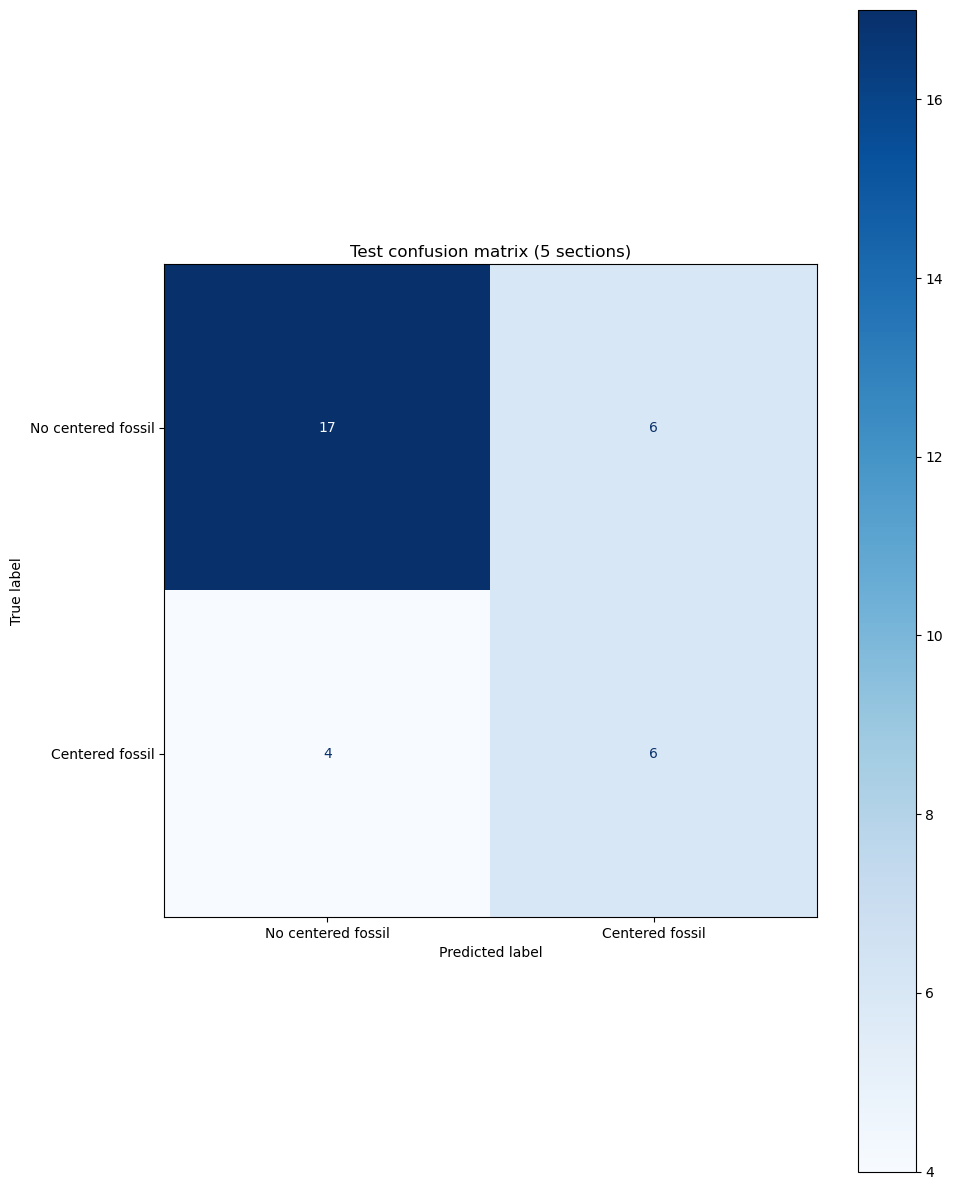

Centered fossils correctly found: 6 / 10
Off-center fossils wrongly called centered: 6 / 21
No-fossil patches wrongly called centered: 0 / 2
Sections Isolated for Testing:
['ope_37.5', 'opd_53.0', 'ope_26.0', 'ope_101.0', 'ope_101.1', 'opf_29.0', 'opf_16.0', 'opf_19.0', 'opf_53.0', 'ope_39.6', 'opd_76.0', 'opd_84.0', 'opf_7.0', 'opf_11.2', 'opc_39.6', 'opf_77.0', 'ope_78.0', 'opd_49.0', 'ope_30.0', 'ope_82.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_opd_53.0a_patch3.png'
 '../../Data/Center_Fossil/resized_opd_53.0a_patch4.png'
 '../../Data/Center_Fossil/resized_opd_53.0a_patch5.png'
 '../../Data/Center_Fossil/resized_opd_53.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opd_76.0a_patch2.png'
 '../../Data/Center_Fossil/resized_opd_76.0b_patch4.png'
 '../../Data/Center_Fossil/resized_ope_101.0(1)_patch1.png'
 '../../Data/Center_Fossil/resized_ope_101.0(1)_patch2.png'
 '../../Data/Center_F

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ cropping2d        │ (None, 3, 3,    │         0 │ xception[0][0] │   -   │
│ (Cropping2D)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ cropping2d[0]… │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_averag… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 1)       │     4,097 │ dropout[0][0]  │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 20,865,577 (79.60 MB)

 Trainable params: 4,097 (16.00 KB)

...

 Total params: 20,873,773 (79.63 MB)

 Trainable params: 20,811,049 (79.39 MB)

 Non-trainable params: 54,528 (213.00 KB)

 Optimizer params: 8,196 (32.02 KB)

Fitting end-to-end model
Epoch 1/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 154s 7s/step - auc_1: 0.6218 - binary_accuracy: 0.7601 - loss: 1.0254 - precision_1: 0.4839 - recall_1: 0.1210 - specificity_at_sensitivity_1: 0.1788 - val_auc_1: 0.6534 - val_binary_accuracy: 0.6439 - val_loss: 0.6936 - val_precision_1: 0.3171 - val_recall_1: 0.4062 - val_specificity_at_sensitivity_1: 0.2200
Epoch 2/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - auc_1: 0.7138 - binary_accuracy: 0.7754 - loss: 0.7630 - precision_1: 0.5745 - recall_1: 0.2177 - specificity_at_sensitivity_1: 0.2620 - val_auc_1: 0.6389 - val_binary_accuracy: 0.5833 - val_loss: 0.7599 - val_precision_1: 0.2745 - val_recall_1: 0.4375 - val_specificity_at_sensitivity_1: 0.1600
Epoch 3/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - auc_1: 0.7552 - binary_accuracy: 0.7850 - loss: 0.6669 - precision_1: 0.5769 - recall_1: 0.3629 - specificity_at_sensitivity_1: 0.3526 - val_auc_1: 0.6253 - val_binary_accuracy: 0.5833 - val_loss: 0.7979 - val_precision_1: 0.3051

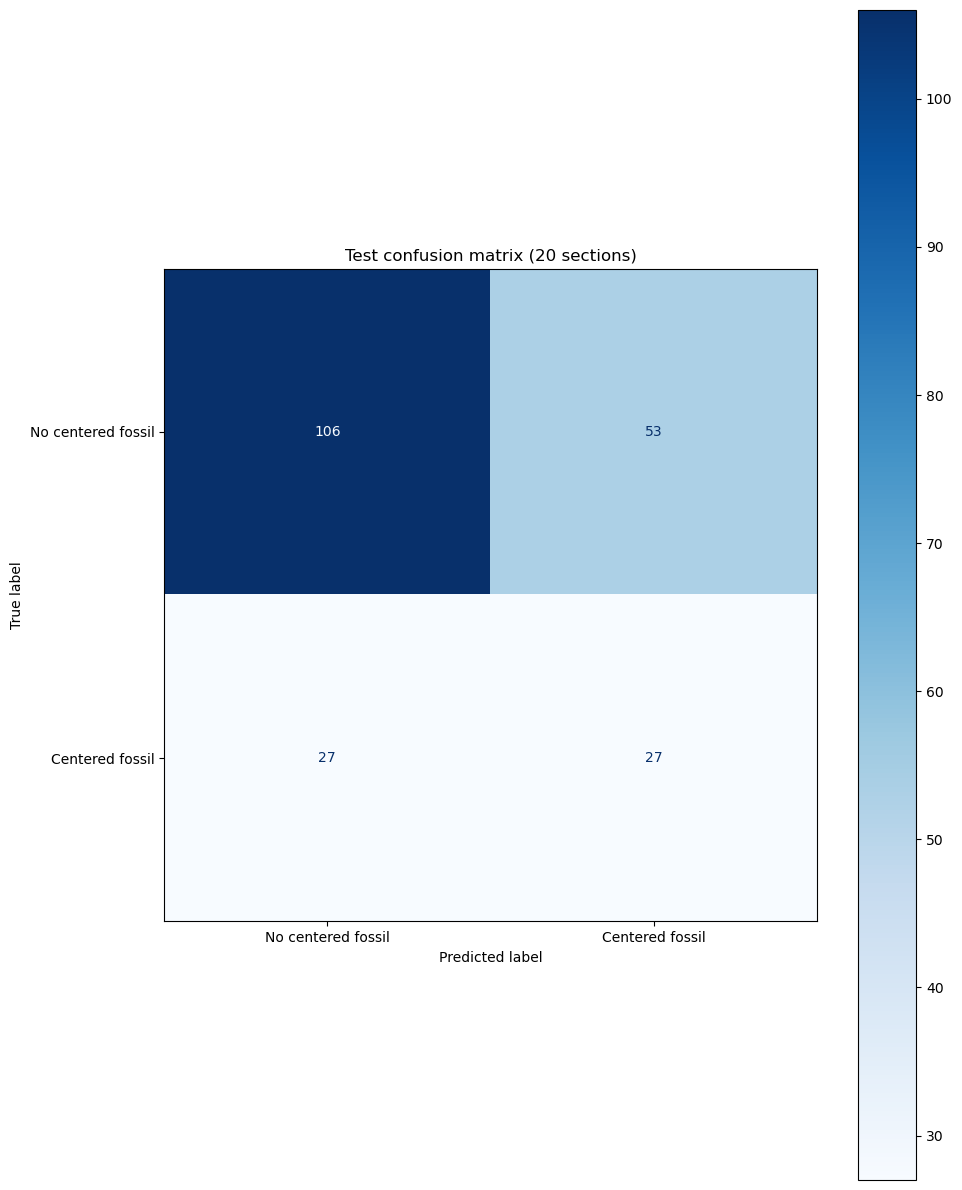

Centered fossils correctly found: 27 / 54
Off-center fossils wrongly called centered: 47 / 126
No-fossil patches wrongly called centered: 6 / 33
Sections Isolated for Testing:
['ope_2.0', 'opc_18.0', 'ope_30.0', 'opf_2.5', 'opb_34.1', 'ope_50.0', 'ope_58.0', 'opf_41.0', 'opf_81.0', 'opd_89.0', 'opd_44.0', 'ope_34.0', 'ope_26.0', 'opf_73.0', 'ope_101.0', 'ope_78.0', 'opf_26.0', 'opd_76.0', 'opc_7.4', 'opf_33.0', 'opf_53.0', 'opf_14.0', 'ope_86.0', 'opd_94.0', 'ope_39.6', 'ope_62.0', 'opf_9.0', 'opd_12.0', 'opd_80.0', 'opf_81.0', 'opb_48.4', 'opf_85.0', 'opd_84.0', 'opd_59.0', 'ope_94.0', 'ope_18.0', 'opf_61.0', 'opf_22.0', 'opc_39.6', 'opf_29.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opb_48.4_patch4.png'
 '../../Data/Center_Fossil/resized_opc_18.0b_patch2.png'
 '../../Data/Center_Fossil/resized_opc_18.0d_patch3.png'
 '../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_opc_7.4_patch2.png'
 '../../Data/Cente

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ cropping2d        │ (None, 3, 3,    │         0 │ xception[0][0] │   -   │
│ (Cropping2D)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ cropping2d[0]… │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_averag… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 1)       │     4,097 │ dropout[0][0]  │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 20,865,577 (79.60 MB)

 Trainable params: 4,097 (16.00 KB)

...

 Trainable params: 20,811,049 (79.39 MB)

 Non-trainable params: 54,528 (213.00 KB)

 Optimizer params: 8,196 (32.02 KB)

Fitting end-to-end model
Epoch 1/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 135s 7s/step - auc_1: 0.4988 - binary_accuracy: 0.7507 - loss: 1.5279 - precision_1: 0.6000 - recall_1: 0.0323 - specificity_at_sensitivity_1: 0.1413 - val_auc_1: 0.6131 - val_binary_accuracy: 0.6702 - val_loss: 0.6701 - val_precision_1: 0.3600 - val_recall_1: 0.3750 - val_specificity_at_sensitivity_1: 0.2286
Epoch 2/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - auc_1: 0.6794 - binary_accuracy: 0.7480 - loss: 1.0697 - precision_1: 0.5000 - recall_1: 0.0645 - specificity_at_sensitivity_1: 0.3768 - val_auc_1: 0.6057 - val_binary_accuracy: 0.6489 - val_loss: 0.6927 - val_precision_1: 0.3333 - val_recall_1: 0.3750 - val_specificity_at_sensitivity_1: 0.2571
Epoch 3/5
 2/12 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - auc_1: 0.6459 - binary_accuracy: 0.7266 - loss: 1.2657 - precision_1: 1.0000 - recall_1: 0.0778 - specificity_at_sensitivity_1: 0.2717

KeyboardInterrupt: 

In [30]:
num_sections = [5, 20, 40, 60, 70]
center_folder = "../../Data/Center_Fossil"
fossil_nocenter_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"
our_layer_histories = []
whole_model_histories = []
test_evals = []
for num_test_sections in num_sections:
    ours, whole_model, eval = model_fit_numbersections(num_test_sections)
    our_layer_histories.append(ours)
    whole_model_histories.append(whole_model)
    test_evals.append(eval)

### Testing Number Sections on Good Data

In [51]:
# This file path will need to change
image_samples = pd.read_csv("../../Data/ACRGoodSamples.csv")
center_folder = "../../Data/ACRPatchesCenterSorting/centerFossil"
fossil_nocenter_folder = "../../Data/ACRPatchesCenterSorting/noCenterFossil"
no_fossil_folder = "../../Data/ACRPatchesCenterSorting/edge"

# Takes in a list of samples (csv) returns a random sample as a string
def GetRandomThinSections(samplelist, num_sections):
    if samplelist.empty:
        print("No rows found in sample list")
        return []

    n = min(num_sections, len(samplelist))

    return (
        samplelist.iloc[:, 0]   # first (only) column, no header name needed
        .astype(str)
        .str.strip()
        .sample(n=n)
        .tolist()
    )

def TrainTestValSplit(image_folder, sections):
    test_data_names = []
    remaining_data_names = []

    # List the folder ONCE; each file is checked against ALL sections
    for filename in os.listdir(image_folder):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            filepath = os.path.join(image_folder, filename)
            if any(section in filename for section in sections):
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)

    print(f"Test Data Names from {image_folder}: {np.sort(test_data_names)}")

    # Split remaining data into training and validation sets at random
    random.shuffle(remaining_data_names)
    split = int(len(remaining_data_names) * 0.8)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]
    print(f"Training Data: {np.sort(training_data_names)}")
    print(f"Validation Data: {np.sort(validation_data_names)}")

    # Read in images
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    # Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data

augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    #layers.RandomRotation(0.25)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x

#TO DO: Edit so we also get labels, wrap model in a function, write k fold CV for params
# 
#  For each opx (x = b thru f) we will hold back one total thin section and all of its related patches for testing data

# This function takes in a folder of patches and pre-determined sections to remove and splits into train, test, val data

augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    #layers.RandomRotation(0.25)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x


def model_fit_numbersections(num_test_sections):
    center_folder = "../../Data/ACRPatchesCenterSorting/centerFossil"
    fossil_nocenter_folder = "../../Data/ACRPatchesCenterSorting/noCenterFossil"
    no_fossil_folder = "../../Data/ACRPatchesCenterSorting/edge"

    #This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
    sections = GetRandomThinSections(image_samples, num_test_sections)
    print(f"Sections Isolated for Testing:")
    print(sections)

    train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
    train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(fossil_nocenter_folder, sections)
    train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

    # Now, get label data setting fossils to 1 and no fossil to 0

    Y_train = np.concatenate([np.ones(train_center.shape[0]), np.zeros(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
    Y_val = np.concatenate([np.ones(val_center.shape[0]), np.zeros(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
    Y_test = np.concatenate([np.ones(test_center.shape[0]), np.zeros(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
    training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
    validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
    testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

    # Transform numpy arrays to tf datasets

    training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
    validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
    testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))

    # Shuffle data
    training_data = training_data.shuffle(len(Y_train))
    #validation_data = validation_data.shuffle(len(Y_val))
    #testing_data = testing_data.shuffle(len(Y_test))
    
    # Augment Data
    training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
    )

    nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
    fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

    augfossil = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil2 = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil3 = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))

    training_data = training_data.concatenate(augfossil)
    training_data = training_data.concatenate(augfossil2)
    training_data = training_data.concatenate(augfossil3)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos

    training_data = training_data.shuffle(4*n_pos + n_neg)

    n_train = sum(1 for _ in training_data)
    training_data = training_data.apply(tf.data.experimental.assert_cardinality(n_train))
    
    # Batch and prefetch data 

    batch_size = 32 # this could change

    training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos
    class_weight = {0: len(Y_train) / (2 * n_neg), 1: len(Y_train) / (2 * n_pos)}
    print(f"train: {len(Y_train)} samples ({n_pos} pos, {n_neg} neg), class_weight={class_weight}")

    THRESH = 0.5   # change this to whatever cutoff you want
    # Create the base model with the pre-trained imagenet weights
    base_model = keras.applications.Xception(
        weights = 'imagenet',
        input_shape = (300, 300, 3),
        include_top = False) # Why do we not include imagenet at the top? 

    # Freeze the base model weights (they will not be trained)
    base_model.trainable = False

    # Create a new model that goes on top of the base imagenet model
    inputs = keras.Input(shape = (300, 300, 3))
    # We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    #x = layers.RandomRotation(1.0, fill_mode="constant")(x)   # full rotation, black corners
    #x = layers.RandomContrast(0.2)(x)
    #x = layers.RandomBrightness(0.2, value_range=(0, 255))(x)

    x = layers.Rescaling(scale=1/127.5, offset=-1)(x)
    x = base_model(x, training=False)                         # (batch, 7, 7, 2048)

    # Central-region pooling + global context
    #center = layers.Cropping2D(cropping=((3, 3), (3, 3)))(x)  # central 3x3 of the 7x7 map
    #center = layers.GlobalAveragePooling2D()(center)
    #context = layers.GlobalAveragePooling2D()(x)
    #x = layers.Concatenate()([center, context])
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)

    model.summary(show_trainable = True)

    # Train the new top layer of the model
    model.compile(
        optimizer = keras.optimizers.Adam(), # play with this also
        loss = keras.losses.BinaryCrossentropy(), #check this also
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)]
    )

    epochs = 8 # also play with this
    print(f"Fitting top layer of model")
    
    history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data)

    # Fine tune entire model
    # Fine tune (gently)
    base_model.trainable = True

    # Keep everything frozen except the last 30 layers
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    # Keep batch norm layers frozen so the pretrained statistics aren't disturbed
    for layer in base_model.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    model.summary(show_trainable=True)   # now shows the real trainable state

    model.compile(
        optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
        loss = keras.losses.BinaryCrossentropy(),
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(name="auc"), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)] #check this -- we have a binary model so it should be ok
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor = "val_auc", mode = "max", patience = 2, restore_best_weights = True)

    epochs = 5 #??
    print(f"Fitting end-to-end model")
    history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data, callbacks = [early_stop])
        # Validate model on test data
    print(f"Test dataset evaluation:")
    test_eval = model.evaluate(testing_data)
        # ---- Confusion matrix on the test set ----
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    # Test data is not shuffled, so predictions line up with Y_test
    y_prob = model.predict(testing_data).ravel()
    y_pred = (y_prob >= THRESH).astype(int)
    y_true = Y_test.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion matrix ({num_test_sections} test sections):")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

    fig, ax = plt.subplots(figsize=(10, 12))
    ConfusionMatrixDisplay(cm, display_labels=["No centered fossil", "Centered fossil"]).plot(
        ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Test confusion matrix ({num_test_sections} sections)")
    plt.tight_layout()
    plt.show()

    # Where do the false positives come from? Test order is: center, nocenter, nofossil
    n_c, n_n = test_center.shape[0], test_nocenter.shape[0]
    pred_nocenter = y_pred[n_c:n_c + n_n]
    pred_nofossil = y_pred[n_c + n_n:]
    print(f"Centered fossils correctly found: {y_pred[:n_c].sum()} / {n_c}")
    print(f"Off-center fossils wrongly called centered: {pred_nocenter.sum()} / {n_n}")
    print(f"No-fossil patches wrongly called centered: {pred_nofossil.sum()} / {len(pred_nofossil)}")

    
    del model, base_model, training_data, validation_data, testing_data
    keras.backend.clear_session()
    gc.collect()
    return history_our_layers, history_whole_model, test_eval

In [52]:
num_sections = [1, 2, 3, 4, 5]
center_folder = "../../Data/ACRPatchesCenterSorting/centerFossil"
fossil_nocenter_folder = "../../Data/ACRPatchesCenterSorting/noCenterFossil"
no_fossil_folder = "../../Data/ACRPatchesCenterSorting/edge"
our_layer_histories = []
whole_model_histories = []
test_evals = []
for num_test_sections in num_sections:
    ours, whole_model, eval = model_fit_numbersections(num_test_sections)
    our_layer_histories.append(ours)
    whole_model_histories.append(whole_model)
    test_evals.append(eval)

Sections Isolated for Testing:
['OPF_97.0']
Test Data Names from ../../Data/ACRPatchesCenterSorting/centerFossil: ['../../Data/ACRPatchesCenterSorting/centerFossil/OPF_97.0_patch47.png']
Training Data: ['../../Data/ACRPatchesCenterSorting/centerFossil/OPB_15.4_patch101.png'
 '../../Data/ACRPatchesCenterSorting/centerFossil/OPB_15.4_patch105.png'
 '../../Data/ACRPatchesCenterSorting/centerFossil/OPB_15.4_patch107.png'
 '../../Data/ACRPatchesCenterSorting/centerFossil/OPB_15.4_patch108.png'
 '../../Data/ACRPatchesCenterSorting/centerFossil/OPB_15.4_patch18.png'
 '../../Data/ACRPatchesCenterSorting/centerFossil/OPB_15.4_patch21.png'
 '../../Data/ACRPatchesCenterSorting/centerFossil/OPB_15.4_patch26.png'
 '../../Data/ACRPatchesCenterSorting/centerFossil/OPB_15.4_patch28.png'
 '../../Data/ACRPatchesCenterSorting/centerFossil/OPB_15.4_patch30.png'
 '../../Data/ACRPatchesCenterSorting/centerFossil/OPB_15.4_patch31.png'
 '../../Data/ACRPatchesCenterSorting/centerFossil/OPB_15.4_patch32.png'
 '

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_5 (InputLayer)  │ (None, 300, 300, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip_6 (RandomFlip)  │ (None, 300, 300, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_2 (Rescaling)     │ (None, 300, 300, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 10, 10, 2048)  │ 20,861,480 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_3  │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

...

 Trainable params: 8,923,857 (34.04 MB)

 Non-trainable params: 11,939,672 (45.55 MB)

 Optimizer params: 4,100 (16.02 KB)

Fitting end-to-end model
Epoch 1/5
 7/41 ━━━━━━━━━━━━━━━━━━━━ 1:45 3s/step - auc: 0.7551 - binary_accuracy: 0.7093 - loss: 0.5735 - precision_3: 0.6967 - recall_3: 0.9770 - specificity_at_sensitivity_2: 0.3943

KeyboardInterrupt: 

### Testing on Whole Patch (GOOD ACR Patches)

In [58]:
# This file path will need to change
image_samples = pd.read_csv("../../Data/ACRGoodSamples.csv")
center_folder = "../../Data/ACRPatchesWholePatchSorting/fossil"
no_fossil_folder = "../../Data/ACRPatchesWholePatchSorting/no_fossil"

# Takes in a list of samples (csv) returns a random sample as a string
def GetRandomThinSections(samplelist, num_sections):
    if samplelist.empty:
        print("No rows found in sample list")
        return []

    n = min(num_sections, len(samplelist))

    return (
        samplelist.iloc[:, 0]   # first (only) column, no header name needed
        .astype(str)
        .str.strip()
        .sample(n=n)
        .tolist()
    )

def TrainTestValSplit(image_folder, sections):
    test_data_names = []
    remaining_data_names = []

    # List the folder ONCE; each file is checked against ALL sections
    for filename in os.listdir(image_folder):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            filepath = os.path.join(image_folder, filename)
            if any(section in filename for section in sections):
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)

    print(f"Test Data Names from {image_folder}: {np.sort(test_data_names)}")

    # Split remaining data into training and validation sets at random
    random.shuffle(remaining_data_names)
    split = int(len(remaining_data_names) * 0.8)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]
    print(f"Training Data: {np.sort(training_data_names)}")
    print(f"Validation Data: {np.sort(validation_data_names)}")

    # Read in images
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    # Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data

augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x

def model_fit_numbersections_wholepatch(num_test_sections):
    center_folder = "../../Data/ACRPatchesWholePatchSorting/fossil"
    no_fossil_folder = "../../Data/ACRPatchesWholePatchSorting/no_fossil"

    #This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
    sections = GetRandomThinSections(image_samples, num_test_sections)
    print(f"Sections Isolated for Testing:")
    print(sections)

    train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
    train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

    # Now, get label data setting fossils to 1 and no fossil to 0

    Y_train = np.concatenate([np.ones(train_center.shape[0]), np.zeros(train_nofossil.shape[0])])
    Y_val = np.concatenate([np.ones(val_center.shape[0]), np.zeros(val_nofossil.shape[0])])
    Y_test = np.concatenate([np.ones(test_center.shape[0]), np.zeros(test_nofossil.shape[0])])
    training_data = np.concatenate([train_center, train_nofossil])
    validation_data = np.concatenate([val_center, val_nofossil])
    testing_data = np.concatenate([test_center, test_nofossil])

    # Transform numpy arrays to tf datasets

    training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
    validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
    testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))

    # Shuffle data
    training_data = training_data.shuffle(len(Y_train))
    #validation_data = validation_data.shuffle(len(Y_val))
    #testing_data = testing_data.shuffle(len(Y_test))
    
    # Augment Data
    training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
    )

    nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
    fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

    augfossil = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil2 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))

    training_data = training_data.concatenate(augfossil)
    training_data = training_data.concatenate(augfossil2)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos

    training_data = training_data.shuffle(n_pos + 3*n_neg)
    
    n_train = sum(1 for _ in training_data)
    training_data = training_data.apply(tf.data.experimental.assert_cardinality(n_train))
    
    # Batch and prefetch data 

    batch_size = 32 # this could change

    training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos
    class_weight = {0: len(Y_train) / (2 * n_neg), 1: len(Y_train) / (2 * n_pos)}
    print(f"train: {len(Y_train)} samples ({n_pos} pos, {n_neg} neg), class_weight={class_weight}")

    THRESH = 0.5   # change this to whatever cutoff you want
    # Create the base model with the pre-trained imagenet weights
    base_model = keras.applications.Xception(
        weights = 'imagenet',
        input_shape = (300, 300, 3),
        include_top = False) # Why do we not include imagenet at the top? 

    # Freeze the base model weights (they will not be trained)
    base_model.trainable = False

    # Create a new model that goes on top of the base imagenet model
    inputs = keras.Input(shape = (300, 300, 3))
    # We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    #x = layers.RandomRotation(1.0, fill_mode="constant")(x)   # full rotation, black corners
    x = layers.RandomContrast(0.2)(x)
    #x = layers.RandomBrightness(0.2, value_range=(0, 255))(x)

    x = layers.Rescaling(scale=1/127.5, offset=-1)(x)
    x = base_model(x, training=False)                         # (batch, 7, 7, 2048)

    # Central-region pooling + global context
    #center = layers.Cropping2D(cropping=((3, 3), (3, 3)))(x)  # central 3x3 of the 7x7 map
    #center = layers.GlobalAveragePooling2D()(center)
    #context = layers.GlobalAveragePooling2D()(x)
    #x = layers.Concatenate()([center, context])
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)

    model.summary(show_trainable = True)

    # Train the new top layer of the model
    model.compile(
        optimizer = keras.optimizers.Adam(), # play with this also
        loss = keras.losses.BinaryCrossentropy(), #check this also
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)]
    )

    epochs = 10 # also play with this
    print(f"Fitting top layer of model")
    
    history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data, class_weight = class_weight)

    # Fine tune entire model
    # Fine tune (gently)
    base_model.trainable = True

    # Keep everything frozen except the last 30 layers

    # Keep batch norm layers frozen so the pretrained statistics aren't disturbed
    for layer in base_model.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    model.summary(show_trainable=True)   # now shows the real trainable state

    model.compile(
        optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
        loss = keras.losses.BinaryCrossentropy(),
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(name="auc"), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)] #check this -- we have a binary model so it should be ok
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor = "val_auc", mode = "max", patience = 2, restore_best_weights = True)

    epochs = 3 #??
    print(f"Fitting end-to-end model")
    history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data, callbacks = [early_stop], class_weight = class_weight)
        # Validate model on test data
    print(f"Test dataset evaluation:")
    test_eval = model.evaluate(testing_data)
        # ---- Confusion matrix on the test set ----
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    # Test data is not shuffled, so predictions line up with Y_test
    y_prob = model.predict(testing_data).ravel()
    y_pred = (y_prob >= THRESH).astype(int)
    y_true = Y_test.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion matrix ({num_test_sections} test sections):")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

    fig, ax = plt.subplots(figsize=(10, 12))
    ConfusionMatrixDisplay(cm, display_labels=["No fossil", "Fossil"]).plot(
        ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Test confusion matrix ({num_test_sections} sections)")
    plt.tight_layout()
    plt.show()
    
    del model, base_model, training_data, validation_data, testing_data
    keras.backend.clear_session()
    gc.collect()
    return history_our_layers, history_whole_model, test_eval

Sections Isolated for Testing:
['OPC_7.4', 'OPF_11.2']
Test Data Names from ../../Data/ACRPatchesWholePatchSorting/fossil: ['../../Data/ACRPatchesWholePatchSorting/fossil/OPC_7.4_patch10.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPC_7.4_patch100.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPC_7.4_patch101.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPC_7.4_patch102.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPC_7.4_patch103.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPC_7.4_patch104.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPC_7.4_patch105.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPC_7.4_patch106.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPC_7.4_patch107.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPC_7.4_patch108.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPC_7.4_patch109.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPC_7.4_patch11.png'
 '../../Data/ACRPatchesWholePatchSortin

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_5 (InputLayer)  │ (None, 300, 300, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip_4 (RandomFlip)  │ (None, 300, 300, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_contrast_2           │ (None, 300, 300, 3)   │          0 │   -   │
│ (RandomContrast)            │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_2 (Rescaling)     │ (None, 300, 300, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 10, 10, 2048)  │ 20,861,480 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_2  │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

...

 Total params: 20,867,629 (79.60 MB)

 Trainable params: 20,754,473 (79.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 4,100 (16.02 KB)

Fitting end-to-end model
Epoch 1/3
23/23 ━━━━━━━━━━━━━━━━━━━━ 146s 4s/step - auc: 0.9858 - binary_accuracy: 0.9136 - loss: 0.2111 - precision_3: 0.9729 - recall_3: 0.8837 - specificity_at_sensitivity_3: 0.9574 - val_auc: 0.9749 - val_binary_accuracy: 0.9044 - val_loss: 0.2130 - val_precision_3: 0.9714 - val_recall_3: 0.9107 - val_specificity_at_sensitivity_3: 0.8750
Epoch 2/3
23/23 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - auc: 0.9937 - binary_accuracy: 0.9451 - loss: 0.1297 - precision_3: 0.9834 - recall_3: 0.9262 - specificity_at_sensitivity_3: 0.9929 - val_auc: 0.9847 - val_binary_accuracy: 0.9412 - val_loss: 0.1323 - val_precision_3: 0.9727 - val_recall_3: 0.9554 - val_specificity_at_sensitivity_3: 0.9167
Epoch 3/3
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - auc: 0.9972 - binary_accuracy: 0.9671 - loss: 0.0895 - precision_3: 0.9885 - recall_3: 0.9575 - specificity_at_sensitivity_3: 0.9965 - val_auc: 0.9879 - val_binary_accuracy: 0.9559 - val_loss: 0.1188 - val_precision_3: 0.9732 - val_recal

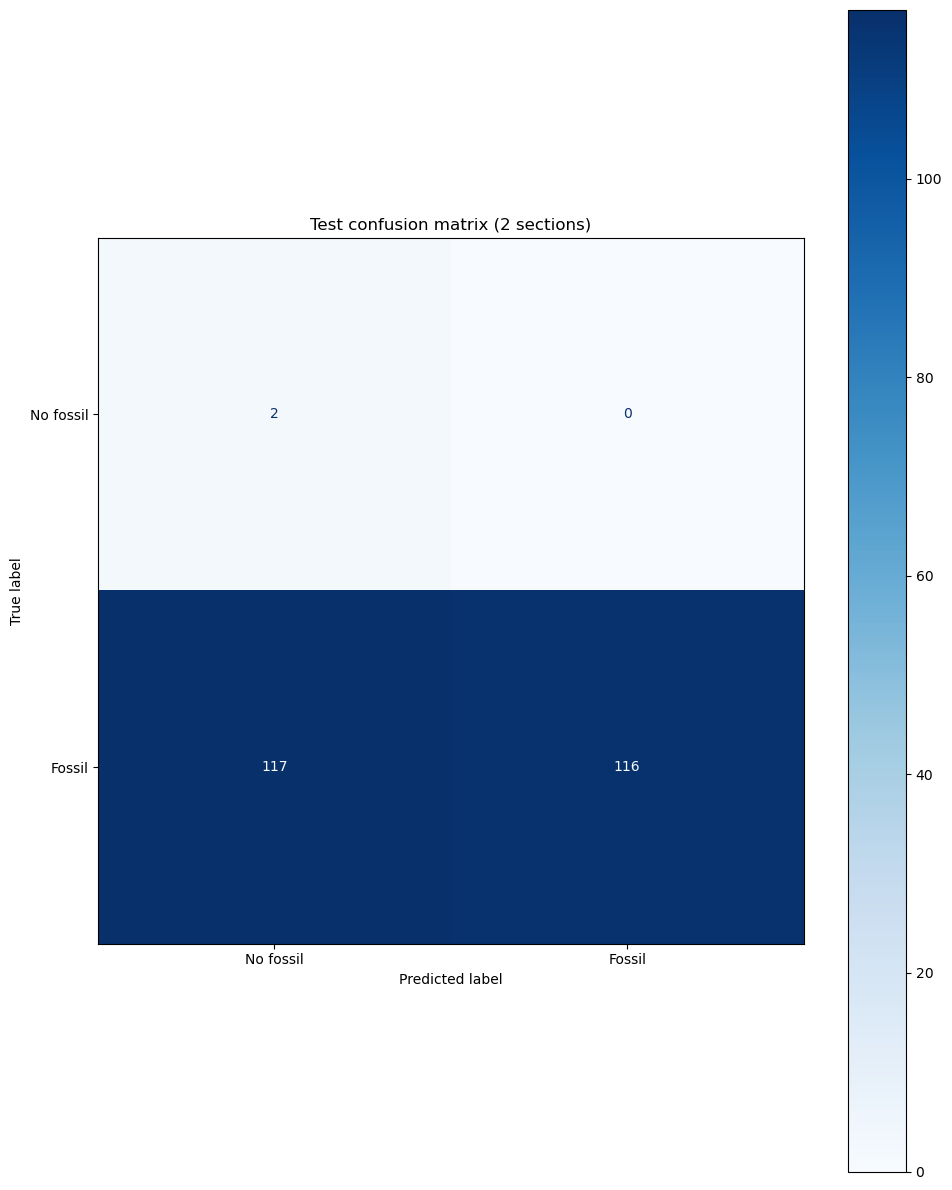

Sections Isolated for Testing:
['OPF_97.0', 'OPB_15.4', 'OPD_89.0']
Test Data Names from ../../Data/ACRPatchesWholePatchSorting/fossil: ['../../Data/ACRPatchesWholePatchSorting/fossil/OPB_15.4_patch10.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPB_15.4_patch100.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPB_15.4_patch101.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPB_15.4_patch102.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPB_15.4_patch103.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPB_15.4_patch104.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPB_15.4_patch105.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPB_15.4_patch106.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPB_15.4_patch107.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPB_15.4_patch108.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPB_15.4_patch109.png'
 '../../Data/ACRPatchesWholePatchSorting/fossil/OPB_15.4_patch11.png'
 '../../Data/A

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 300, 300, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip (RandomFlip)    │ (None, 300, 300, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_contrast             │ (None, 300, 300, 3)   │          0 │   -   │
│ (RandomContrast)            │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 300, 300, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 10, 10, 2048)  │ 20,861,480 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

...

 Total params: 20,867,629 (79.60 MB)

 Trainable params: 20,754,473 (79.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 4,100 (16.02 KB)

Fitting end-to-end model
Epoch 1/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 131s 5s/step - auc: 0.9351 - binary_accuracy: 0.6092 - loss: 0.5653 - precision_1: 1.0000 - recall_1: 0.5723 - specificity_at_sensitivity_1: 0.7778 - val_auc: 0.6302 - val_binary_accuracy: 0.6452 - val_loss: 0.5550 - val_precision_1: 0.9750 - val_recall_1: 0.6500 - val_specificity_at_sensitivity_1: 0.0000e+00
Epoch 2/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - auc: 0.9728 - binary_accuracy: 0.8046 - loss: 0.3662 - precision_1: 0.9973 - recall_1: 0.7883 - specificity_at_sensitivity_1: 0.9333 - val_auc: 0.6271 - val_binary_accuracy: 0.7016 - val_loss: 0.4868 - val_precision_1: 0.9770 - val_recall_1: 0.7083 - val_specificity_at_sensitivity_1: 0.2500
Epoch 3/3
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - auc: 0.9933 - binary_accuracy: 0.9195 - loss: 0.2218 - precision_1: 0.9977 - recall_1: 0.9140 - specificity_at_sensitivity_1: 0.9778 - val_auc: 0.6469 - val_binary_accuracy: 0.8145 - val_loss: 0.3990 - val_precision_1: 0.9709 - val_r

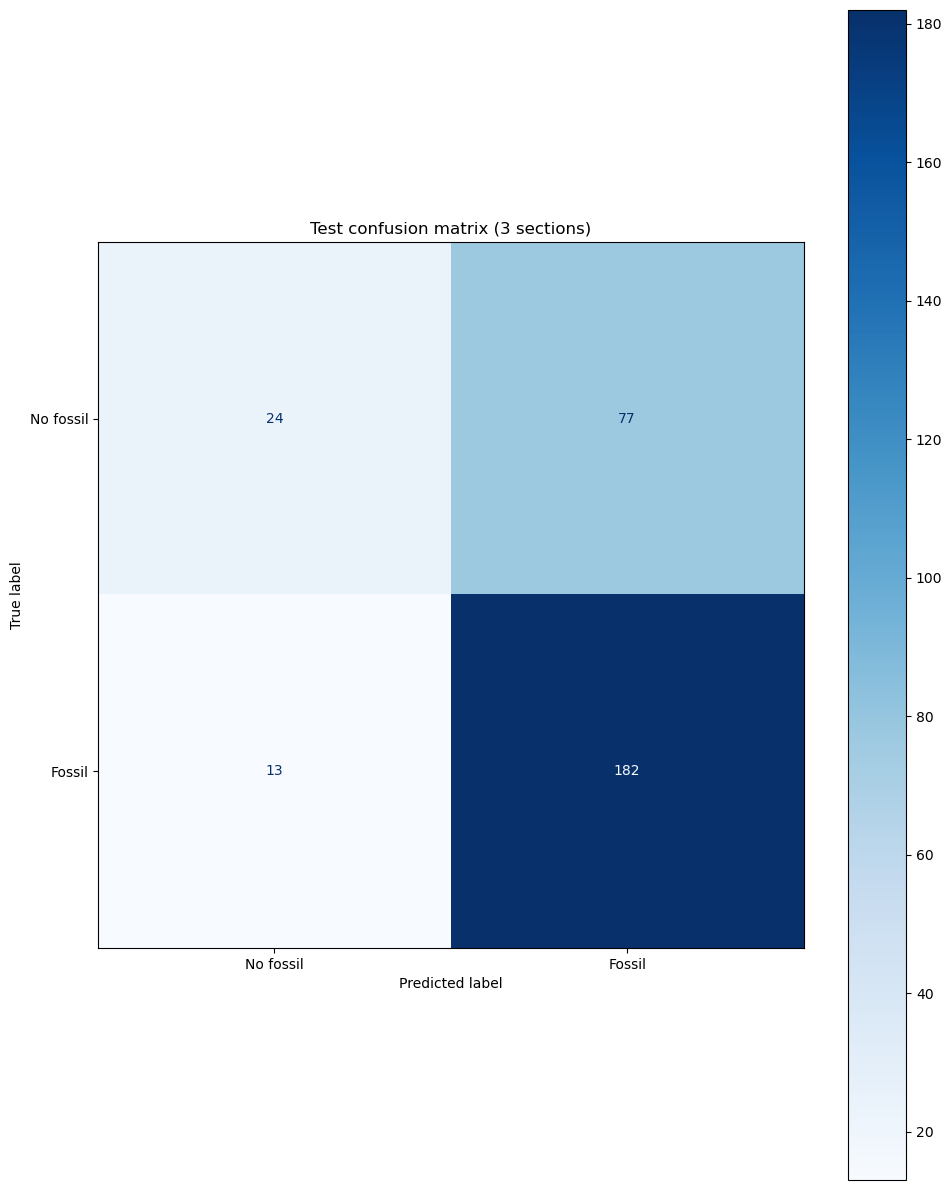

In [60]:
num_sections = [2, 3]
image_samples = pd.read_csv("../../Data/ACRGoodSamples.csv")
center_folder = "../../Data/ACRPatchesWholePatchSorting/fossil"
no_fossil_folder = "../../Data/ACRPatchesWholePatchSorting/no_fossil"
our_layer_histories = []
whole_model_histories = []
test_evals = []
for num_test_sections in num_sections:
    ours, whole_model, eval = model_fit_numbersections_wholepatch(num_test_sections)
    our_layer_histories.append(ours)
    whole_model_histories.append(whole_model)
    test_evals.append(eval)

### Correct Whole Patch with Old Data

In [2]:

# This file path will need to change
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
center_folder = "../../Data/Center_Fossil"
no_center_fossil_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"

# Takes in a list of samples (csv) returns a random sample as a string
def GetRandomThinSections(samplelist, num_sections,seed=1):
    if samplelist.empty:
        print("No rows found in sample list")
        return []

    n = min(num_sections, len(samplelist))

    return (
        samplelist.iloc[:, 0]   # first (only) column, no header name needed
        .astype(str)
        .str.strip()
        .sample(n=n,random_state=seed)
        .tolist()
    )

def TrainTestValSplit(image_folder, sections):
    test_data_names = []
    remaining_data_names = []

    # List the folder ONCE; each file is checked against ALL sections
    for filename in os.listdir(image_folder):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            filepath = os.path.join(image_folder, filename)
            if any(section in filename for section in sections):
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)

    print(f"Test Data Names from {image_folder}: {np.sort(test_data_names)}")

    # Split remaining data into training and validation sets at random
    random.shuffle(remaining_data_names)
    split = int(len(remaining_data_names) * 0.8)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]
    print(f"Training Data: {np.sort(training_data_names)}")
    print(f"Validation Data: {np.sort(validation_data_names)}")

    # Read in images
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    # Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data

augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x
def model_fit_numbersections_wholepatch_old(num_test_sections):
    center_folder = "../../Data/Center_Fossil"
    no_center_fossil_folder = "../../Data/No_Center_Fossil"
    no_fossil_folder = "../../Data/No_Fossil"

    #This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
    sections = GetRandomThinSections(image_samples, num_test_sections)
    print(f"Sections Isolated for Testing:")
    print(sections)

    train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
    train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(no_center_fossil_folder, sections)
    train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

    # Now, get label data setting fossils to 1 and no fossil to 0

    Y_train = np.concatenate([np.ones(train_center.shape[0]), np.ones(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
    Y_val = np.concatenate([np.ones(val_center.shape[0]), np.ones(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
    Y_test = np.concatenate([np.ones(test_center.shape[0]), np.ones(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
    training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
    validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
    testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

    # Transform numpy arrays to tf datasets

    training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
    validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
    testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))

    # Shuffle data
    training_data = training_data.shuffle(len(Y_train))
    #validation_data = validation_data.shuffle(len(Y_val))
    #testing_data = testing_data.shuffle(len(Y_test))
    
    # Augment Data
    training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
    )

    nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
    fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

    augfossil = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil2 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))

    training_data = training_data.concatenate(augfossil)
    training_data = training_data.concatenate(augfossil2)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos

    training_data = training_data.shuffle(n_pos + 3*n_neg)
    
    n_train = sum(1 for _ in training_data)
    training_data = training_data.apply(tf.data.experimental.assert_cardinality(n_train))
    
    # Batch and prefetch data 

    batch_size = 32 # this could change

    training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos
    class_weight = {0: len(Y_train) / (2 * n_neg), 1: len(Y_train) / (2 * n_pos)}
    print(f"train: {len(Y_train)} samples ({n_pos} pos, {n_neg} neg), class_weight={class_weight}")

    THRESH = 0.5   # change this to whatever cutoff you want
    # Create the base model with the pre-trained imagenet weights
    base_model = keras.applications.Xception(
        weights = 'imagenet',
        input_shape = (200, 200, 3),
        include_top = False) # Why do we not include imagenet at the top? 

    # Freeze the base model weights (they will not be trained)
    base_model.trainable = False

    # Create a new model that goes on top of the base imagenet model
    inputs = keras.Input(shape = (200, 200, 3))
    # We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    #x = layers.RandomRotation(1.0, fill_mode="constant")(x)   # full rotation, black corners
    x = layers.RandomContrast(0.2)(x)
    #x = layers.RandomBrightness(0.2, value_range=(0, 255))(x)

    x = layers.Rescaling(scale=1/127.5, offset=-1)(x)
    x = base_model(x, training=False)                         # (batch, 7, 7, 2048)
    # Combine average pooling (overall context) with max pooling (strongest local response)
    avg_pool = layers.GlobalAveragePooling2D()(x)             # (batch, 2048)
    max_pool = layers.GlobalMaxPooling2D()(x)                 # (batch, 2048)
    x = layers.Concatenate()([avg_pool, max_pool])            # (batch, 4096)

    x = layers.Dropout(0.1)(x)
    x = layers.Dense(128, activation="relu")(x)               # hidden layer
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    # Central-region pooling + global context
    #center = layers.Cropping2D(cropping=((3, 3), (3, 3)))(x)  # central 3x3 of the 7x7 map
    #center = layers.GlobalAveragePooling2D()(center)
    #context = layers.GlobalAveragePooling2D()(x)
    #x = layers.Concatenate()([center, context])
    #x = layers.GlobalAveragePooling2D()(x)

   # x = layers.Dropout(0.1)(x)
    #outputs = layers.Dense(1, activation="sigmoid")(x)
    #model = keras.Model(inputs, outputs)

    model.summary(show_trainable = True)

    # Train the new top layer of the model
    model.compile(
        optimizer = keras.optimizers.Adam(), # play with this also
        loss = keras.losses.BinaryCrossentropy(), #check this also
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)]
    )

    epochs = 20 # also play with this
    print(f"Fitting top layer of model")
    early_stop = keras.callbacks.EarlyStopping(
            monitor = "val_auc", mode = "max", patience = 2, restore_best_weights = True)
    
    history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data, class_weight = class_weight, callbacks = [early_stop])

    # Fine tune entire model
    # Fine tune (gently)
    base_model.trainable = True

    # Keep everything frozen except the last 30 layers

    # Keep batch norm layers frozen so the pretrained statistics aren't disturbed
    for layer in base_model.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    model.summary(show_trainable=True)   # now shows the real trainable state

    model.compile(
        optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
        loss = keras.losses.BinaryCrossentropy(),
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(name="auc"), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)] #check this -- we have a binary model so it should be ok
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor = "val_auc", mode = "max", patience = 2, restore_best_weights = True)

    epochs = 3 #??
    print(f"Fitting end-to-end model")
    history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data, callbacks = [early_stop], class_weight = class_weight)
        # Validate model on test data
    print(f"Test dataset evaluation:")
    test_eval = model.evaluate(testing_data)
        # ---- Confusion matrix on the test set ----
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    # Test data is not shuffled, so predictions line up with Y_test
    y_prob = model.predict(testing_data).ravel()
    y_pred = (y_prob >= THRESH).astype(int)
    y_true = Y_test.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion matrix ({num_test_sections} test sections):")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

    fig, ax = plt.subplots(figsize=(10, 12))
    ConfusionMatrixDisplay(cm, display_labels=["No fossil", "Fossil"]).plot(
        ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Test confusion matrix ({num_test_sections} sections)")
    plt.tight_layout()
    plt.show()
    
    del model, base_model, training_data, validation_data, testing_data
    keras.backend.clear_session()
    gc.collect()
    return history_our_layers, history_whole_model, test_eval

2026-09-29 13:10:18.792465: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-09-29 13:10:18.792513: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-09-29 13:10:18.792523: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
I0000 00:00:1790712618.792547  597262 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1790712618.792609  597262 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch1.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch2.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch3.png'
 '../../Data/Center_Fossil/resized_ope_58.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0a_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch3.png'
 '../../Data/Center_Fossil/resized_ope_90.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opf_69.0_patch1.png'
 '../../Data/Center_Fossil/resized_opf_9.0a_patch5.png']
Training Data: ['../../Data/Center_Fossil/resized_opb_15.4c_patch2.png'
 '../../Data/Center_Fossil/resized_opb_19.2b_patch1.png'
 '../../Data/Center_Fossil/resized_opb_19.2b_patch5.png'
 '../../Data/Center_Fossil/resized_opb_19.2c_patch2

2026-09-29 13:10:21.312199: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-09-29 13:10:21.703635: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


train: 648 samples (545 pos, 103 neg), class_weight={0: 3.145631067961165, 1: 0.5944954128440367}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip_1     │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_contrast   │ (None, 200,     │         0 │ random_flip_1… │   -   │
│ (RandomContrast)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_contra… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 450ms/step - auc: 0.9188 - binary_accuracy: 0.8044 - loss: 0.5384 - precision_1: 0.9375 - recall_1: 0.7431 - specificity_at_sensitivity_1: 0.7314 - val_auc: 0.8888 - val_binary_accuracy: 0.7239 - val_loss: 0.7535 - val_precision_1: 0.9894 - val_recall_1: 0.6788 - val_specificity_at_sensitivity_1: 0.5000
Epoch 2/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 352ms/step - auc: 0.9188 - binary_accuracy: 0.8126 - loss: 0.5457 - precision_1: 0.9487 - recall_1: 0.7468 - specificity_at_sensitivity_1: 0.7540 - val_auc: 0.9037 - val_binary_accuracy: 0.6994 - val_loss: 0.8819 - val_precision_1: 0.9889 - val_recall_1: 0.6496 - val_specificity_at_sensitivity_1: 0.5769
Epoch 3/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 348ms/step - auc: 0.9346 - binary_accuracy: 0.8431 - loss: 0.4899 - precision_1: 0.9660 - recall_1: 0.7817 - specificity_at_sensitivity_1: 0.7443 - val_auc: 0.9002 - val_binary_accuracy: 0.7239 - val_loss: 0.7940 - val_precision_1: 0.9894 - v

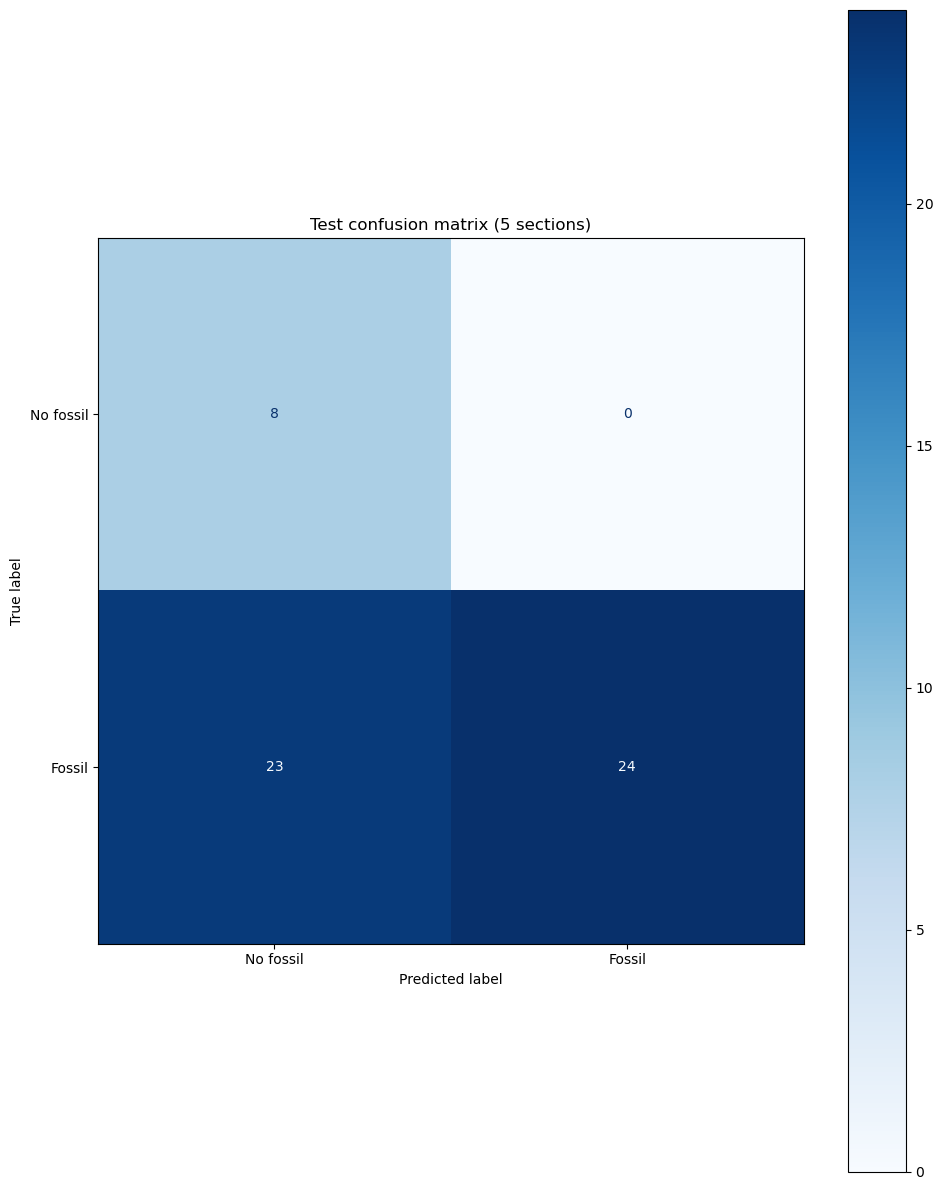

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch1.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch2.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch3.png'
 '../../Data/Center_Fossil/resized_ope_58.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch1.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0a_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch3.png'
 '../../Data/Center_Fossil/resized_ope_90.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opf_16.0b_patch2.png'
 '../../Data/Center_Fossil/resized_opf_16.0c_patch3.png'
 '../../Data/Center_Fossil/resized_opf_16.0d_patch5.png'
 '../

2026-09-29 13:11:58.189973: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


train: 602 samples (509 pos, 93 neg), class_weight={0: 3.236559139784946, 1: 0.5913555992141454}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_contrast   │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (RandomContrast)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_contra… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 501ms/step - auc: 0.9300 - binary_accuracy: 0.8439 - loss: 0.5058 - precision_1: 0.9595 - recall_1: 0.7917 - specificity_at_sensitivity_1: 0.7814 - val_auc: 0.9136 - val_binary_accuracy: 0.7320 - val_loss: 0.9291 - val_precision_1: 0.9889 - val_recall_1: 0.6899 - val_specificity_at_sensitivity_1: 0.6250
Epoch 2/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 361ms/step - auc: 0.9499 - binary_accuracy: 0.8655 - loss: 0.3501 - precision_1: 0.9764 - recall_1: 0.8114 - specificity_at_sensitivity_1: 0.8280 - val_auc: 0.9230 - val_binary_accuracy: 0.7974 - val_loss: 0.4621 - val_precision_1: 0.9623 - val_recall_1: 0.7907 - val_specificity_at_sensitivity_1: 0.7083
Epoch 3/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 356ms/step - auc: 0.9531 - binary_accuracy: 0.8566 - loss: 0.3746 - precision_1: 0.9605 - recall_1: 0.8114 - specificity_at_sensitivity_1: 0.8710 - val_auc: 0.9217 - val_binary_accuracy: 0.7974 - val_loss: 0.6122 - val_precision_1: 0.9623 - val

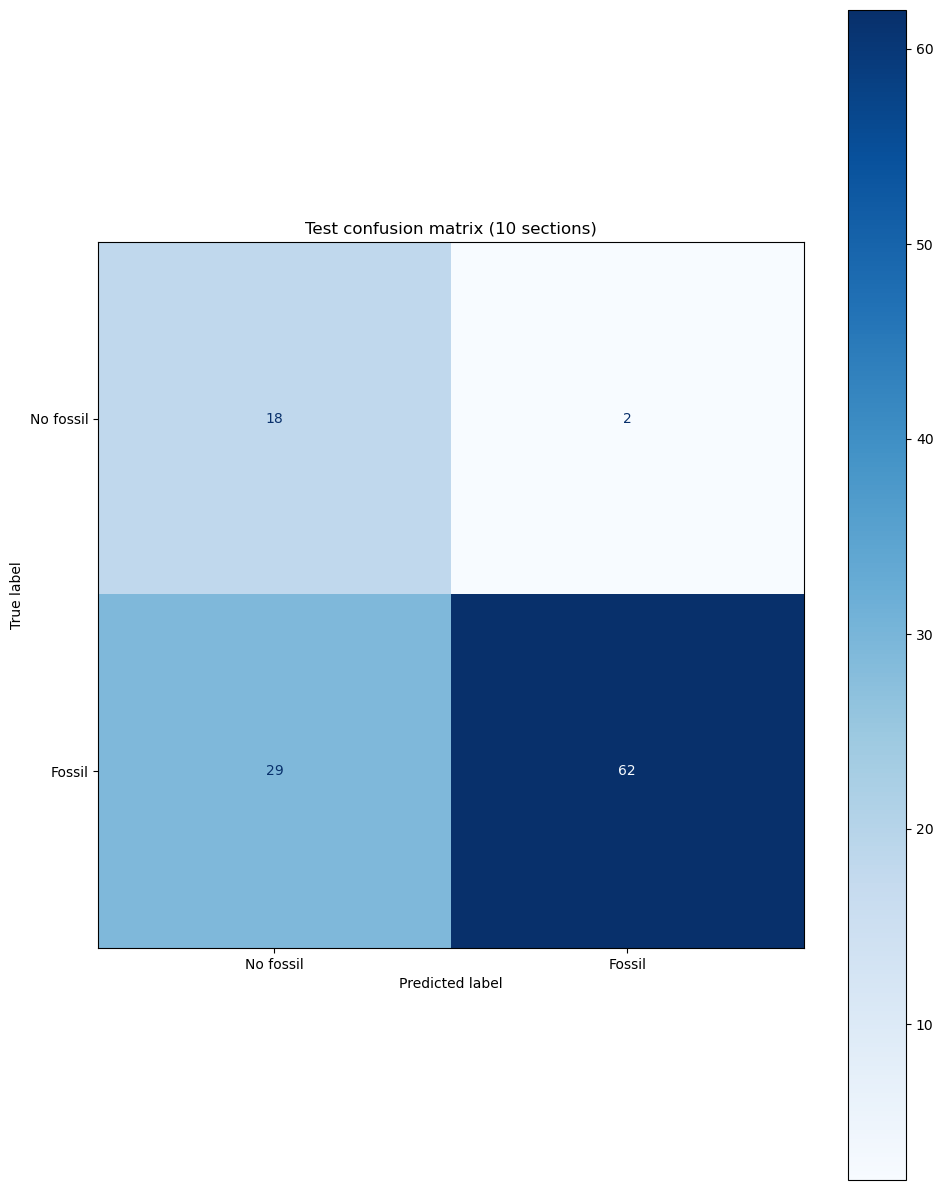

In [3]:
num_sections = [5, 10]
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
center_folder = "../../Data/Center_Fossil"
no_center_fossil_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"
our_layer_histories = []
whole_model_histories = []
test_evals = []
for num_test_sections in num_sections:
    ours, whole_model, eval = model_fit_numbersections_wholepatch_old(num_test_sections)
    our_layer_histories.append(ours)
    whole_model_histories.append(whole_model)
    test_evals.append(eval)

In [4]:
# This file path will need to change
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
center_folder = "../../Data/Center_Fossil"
no_center_fossil_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"

def TrainTestValSplit(image_folder, sections):
    test_data_names = []
    remaining_data_names = []

    # List the folder ONCE; each file is checked against ALL sections
    for filename in os.listdir(image_folder):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            filepath = os.path.join(image_folder, filename)
            if any(section in filename for section in sections):
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)

    print(f"Test Data Names from {image_folder}: {np.sort(test_data_names)}")

    # Split remaining data into training and validation sets at random
    random.shuffle(remaining_data_names)
    split = int(len(remaining_data_names) * 0.7)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]
    print(f"Training Data: {np.sort(training_data_names)}")
    print(f"Validation Data: {np.sort(validation_data_names)}")

    # Read in images
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    # Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data

augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x
def model_fit_numbersections_wholepatch_old(num_test_sections):
    center_folder = "../../Data/Center_Fossil"
    no_center_fossil_folder = "../../Data/No_Center_Fossil"
    no_fossil_folder = "../../Data/No_Fossil"

    #This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
    sections = GetRandomThinSections(image_samples, num_test_sections)
    print(f"Sections Isolated for Testing:")
    print(sections)

    train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
    train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(no_center_fossil_folder, sections)
    train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

    # Now, get label data setting fossils to 1 and no fossil to 0

    Y_train = np.concatenate([np.ones(train_center.shape[0]), np.ones(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
    Y_val = np.concatenate([np.ones(val_center.shape[0]), np.ones(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
    Y_test = np.concatenate([np.ones(test_center.shape[0]), np.ones(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
    training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
    validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
    testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

    # Transform numpy arrays to tf datasets

    training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
    validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
    testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))

    # Shuffle data
    training_data = training_data.shuffle(len(Y_train))
    #validation_data = validation_data.shuffle(len(Y_val))
    #testing_data = testing_data.shuffle(len(Y_test))
    
    # Augment Data
    training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
    )

    nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
    fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

    augfossil = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil2 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))

    training_data = training_data.concatenate(augfossil)
    training_data = training_data.concatenate(augfossil2)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos

    training_data = training_data.shuffle(n_pos + 3*n_neg)
    
    n_train = sum(1 for _ in training_data)
    training_data = training_data.apply(tf.data.experimental.assert_cardinality(n_train))
    
    # Batch and prefetch data 

    batch_size = 32 # this could change

    training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos
    class_weight = {0: len(Y_train) / (2 * n_neg), 1: len(Y_train) / (2 * n_pos)}
    print(f"train: {len(Y_train)} samples ({n_pos} pos, {n_neg} neg), class_weight={class_weight}")

    THRESH = 0.65   # change this to whatever cutoff you want
    # Create the base model with the pre-trained imagenet weights
    base_model = keras.applications.Xception(
        weights = 'imagenet',
        input_shape = (200, 200, 3),
        include_top = False) # Why do we not include imagenet at the top? 

    # Freeze the base model weights (they will not be trained)
    base_model.trainable = False

    # Create a new model that goes on top of the base imagenet model
    inputs = keras.Input(shape = (200, 200, 3))
    # We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(1.0, fill_mode="reflect")(x)   # full rotation, black corners
    #x = layers.RandomContrast(0.2)(x)
    #x = layers.RandomBrightness(0.2, value_range=(0, 255))(x)

    x = layers.Rescaling(scale=1/127.5, offset=-1)(x)
    #x = layers.AutoContrast(value_range = (0, 255))(x)
    x = base_model(x, training=False)                         # (batch, 7, 7, 2048)
    # Combine average pooling (overall context) with max pooling (strongest local response)
    avg_pool = layers.GlobalAveragePooling2D()(x)             # (batch, 2048)
    max_pool = layers.GlobalMaxPooling2D()(x)                 # (batch, 2048)
    x = layers.Concatenate()([avg_pool, max_pool])            # (batch, 4096)

    x = layers.Dropout(0.1)(x)
    x = layers.Dense(128, activation="relu")(x)               # hidden layer
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    # Central-region pooling + global context
    #center = layers.Cropping2D(cropping=((3, 3), (3, 3)))(x)  # central 3x3 of the 7x7 map
    #center = layers.GlobalAveragePooling2D()(center)
    #context = layers.GlobalAveragePooling2D()(x)
    #x = layers.Concatenate()([center, context])
    #x = layers.GlobalAveragePooling2D()(x)

   # x = layers.Dropout(0.1)(x)
    #outputs = layers.Dense(1, activation="sigmoid")(x)
    #model = keras.Model(inputs, outputs)

    model.summary(show_trainable = True)

    # Train the new top layer of the model
    model.compile(
        optimizer = keras.optimizers.Adam(), # play with this also
        loss = keras.losses.BinaryCrossentropy(), #check this also
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)]
    )

    epochs = 20 # also play with this
    print(f"Fitting top layer of model")
    early_stop = keras.callbacks.EarlyStopping(
            monitor = "val_auc", mode = "max", patience = 5, restore_best_weights = True)
    
    history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data, class_weight = class_weight, callbacks = [early_stop])

    # Fine tune entire model
    # Fine tune (gently)
    base_model.trainable = True

    # Keep everything frozen except the last 30 layers

    # Keep batch norm layers frozen so the pretrained statistics aren't disturbed
    for layer in base_model.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    model.summary(show_trainable=True)   # now shows the real trainable state

    model.compile(
        optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
        loss = keras.losses.BinaryCrossentropy(),
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(name="auc"), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)] #check this -- we have a binary model so it should be ok
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor = "val_auc", mode = "max", patience = 2, restore_best_weights = True)

    epochs = 5 #??
    print(f"Fitting end-to-end model")
    history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data, callbacks = [early_stop], class_weight = class_weight)
        # Validate model on test data
    print(f"Test dataset evaluation:")
    test_eval = model.evaluate(testing_data)
        # ---- Confusion matrix on the test set ----
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    # Test data is not shuffled, so predictions line up with Y_test
    y_prob = model.predict(testing_data).ravel()
    y_pred = (y_prob >= THRESH).astype(int)
    y_true = Y_test.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion matrix ({num_test_sections} test sections):")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

    fig, ax = plt.subplots(figsize=(10, 12))
    ConfusionMatrixDisplay(cm, display_labels=["No fossil", "Fossil"]).plot(
        ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Test confusion matrix ({num_test_sections} sections)")
    plt.tight_layout()
    plt.show()
    
    del model, base_model, training_data, validation_data, testing_data
    keras.backend.clear_session()
    gc.collect()
    return history_our_layers, history_whole_model, test_eval

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch1.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch2.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch3.png'
 '../../Data/Center_Fossil/resized_ope_58.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0a_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch3.png'
 '../../Data/Center_Fossil/resized_ope_90.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opf_69.0_patch1.png'
 '../../Data/Center_Fossil/resized_opf_9.0a_patch5.png']
Training Data: ['../../Data/Center_Fossil/resized_opb_19.2b_patch1.png'
 '../../Data/Center_Fossil/resized_opb_19.2b_patch3.png'
 '../../Data/Center_Fossil/resized_opb_19.2b_patch5.png'
 '../../Data/Center_Fossil/resized_opb_19.2c_patch2

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip_1     │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation_1 │ (None, 200,     │         0 │ random_flip_1… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 541ms/step - auc: 0.9031 - binary_accuracy: 0.7912 - loss: 0.5546 - precision_1: 0.9599 - recall_1: 0.7023 - specificity_at_sensitivity_1: 0.6037 - val_auc: 0.8959 - val_binary_accuracy: 0.7992 - val_loss: 0.5506 - val_precision_1: 0.9756 - val_recall_1: 0.7805 - val_specificity_at_sensitivity_1: 0.5897
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 396ms/step - auc: 0.8908 - binary_accuracy: 0.7858 - loss: 0.6934 - precision_1: 0.9465 - recall_1: 0.7044 - specificity_at_sensitivity_1: 0.6407 - val_auc: 0.8839 - val_binary_accuracy: 0.7623 - val_loss: 0.8250 - val_precision_1: 0.9742 - val_recall_1: 0.7366 - val_specificity_at_sensitivity_1: 0.5641
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 382ms/step - auc: 0.9006 - binary_accuracy: 0.7711 - loss: 0.5976 - precision_1: 0.9636 - recall_1: 0.6667 - specificity_at_sensitivity_1: 0.6111 - val_auc: 0.9054 - val_binary_accuracy: 0.8115 - val_loss: 0.3792 - val_precision_1: 0.9704 - v

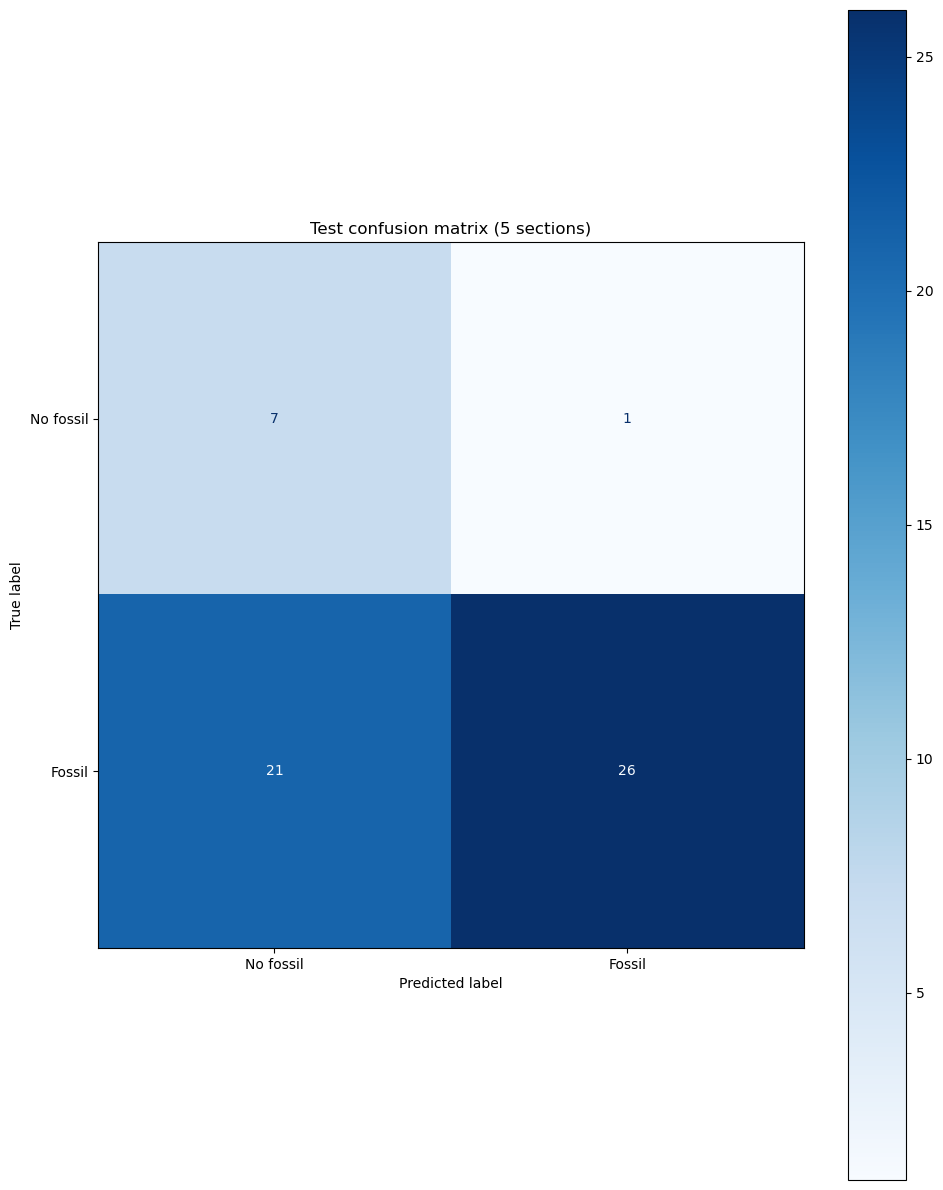

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch1.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch2.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch3.png'
 '../../Data/Center_Fossil/resized_ope_58.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch1.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0a_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch3.png'
 '../../Data/Center_Fossil/resized_ope_90.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opf_16.0b_patch2.png'
 '../../Data/Center_Fossil/resized_opf_16.0c_patch3.png'
 '../../Data/Center_Fossil/resized_opf_16.0d_patch5.png'
 '../

2026-09-29 13:16:39.108747: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


train: 527 samples (446 pos, 81 neg), class_weight={0: 3.253086419753086, 1: 0.5908071748878924}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 584ms/step - auc: 0.8796 - binary_accuracy: 0.7562 - loss: 0.6696 - precision_1: 0.9484 - recall_1: 0.6592 - specificity_at_sensitivity_1: 0.5597 - val_auc: 0.8654 - val_binary_accuracy: 0.7544 - val_loss: 0.6073 - val_precision_1: 0.9789 - val_recall_1: 0.7240 - val_specificity_at_sensitivity_1: 0.4722
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 394ms/step - auc: 0.8820 - binary_accuracy: 0.7591 - loss: 0.6901 - precision_1: 0.9375 - recall_1: 0.6726 - specificity_at_sensitivity_1: 0.6008 - val_auc: 0.8731 - val_binary_accuracy: 0.7544 - val_loss: 0.6723 - val_precision_1: 0.9722 - val_recall_1: 0.7292 - val_specificity_at_sensitivity_1: 0.6111
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 376ms/step - auc: 0.8982 - binary_accuracy: 0.7925 - loss: 0.6402 - precision_1: 0.9605 - recall_1: 0.7085 - specificity_at_sensitivity_1: 0.6420 - val_auc: 0.8827 - val_binary_accuracy: 0.7500 - val_loss: 0.7598 - val_precision_1: 0.9787 - val

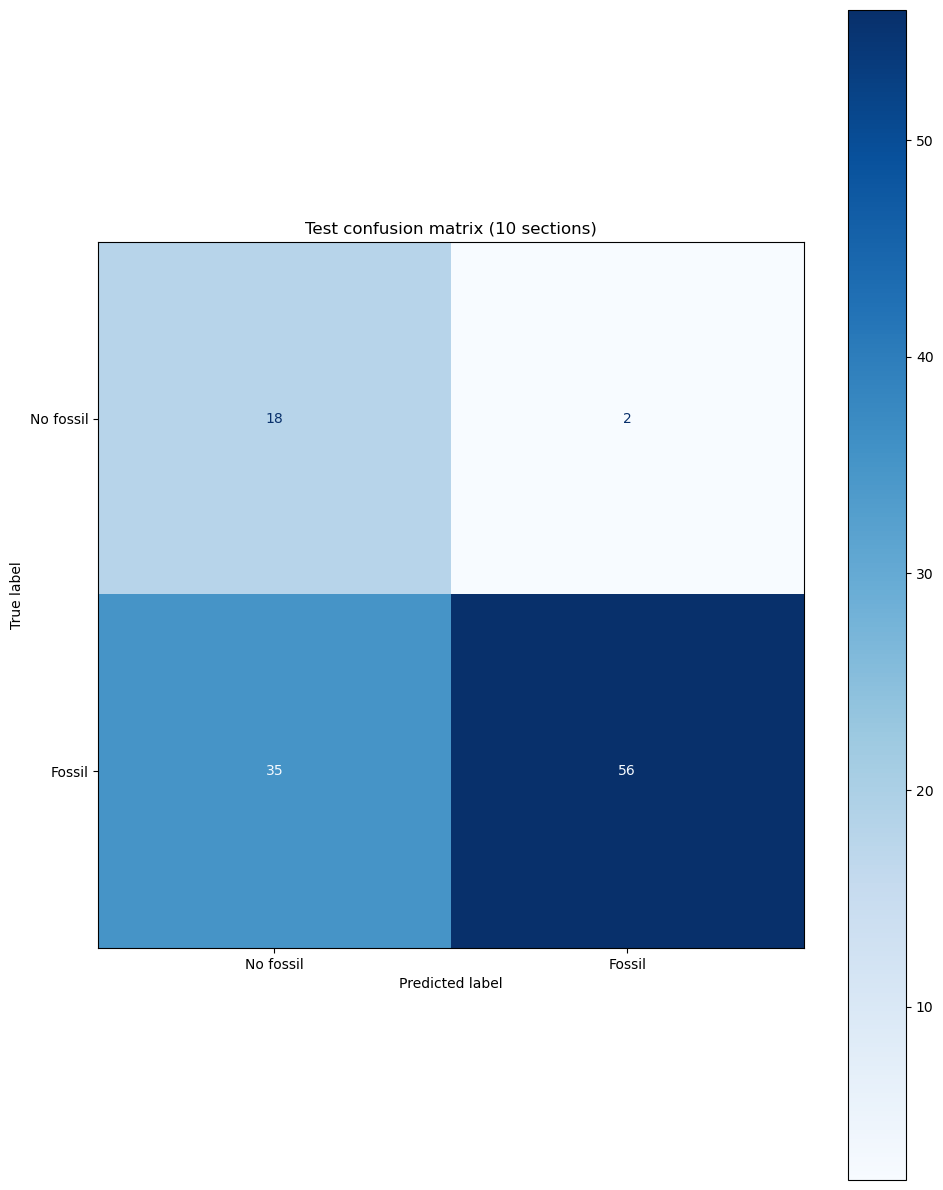

In [5]:
num_sections = [5, 10]
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
center_folder = "../../Data/Center_Fossil"
no_center_fossil_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"
our_layer_histories = []
whole_model_histories = []
test_evals = []
for num_test_sections in num_sections:
    ours, whole_model, eval = model_fit_numbersections_wholepatch_old(num_test_sections)
    our_layer_histories.append(ours)
    whole_model_histories.append(whole_model)
    test_evals.append(eval)

Adding a little more validation data helped. Now, I want to augment a little more no fossil data and see what happens. 

In [6]:
# This file path will need to change
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
center_folder = "../../Data/Center_Fossil"
no_center_fossil_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"

# Takes in a list of samples (csv) returns a random sample as a string

def TrainTestValSplit(image_folder, sections):
    test_data_names = []
    remaining_data_names = []

    # List the folder ONCE; each file is checked against ALL sections
    for filename in os.listdir(image_folder):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            filepath = os.path.join(image_folder, filename)
            if any(section in filename for section in sections):
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)

    print(f"Test Data Names from {image_folder}: {np.sort(test_data_names)}")

    # Split remaining data into training and validation sets at random
    random.shuffle(remaining_data_names)
    split = int(len(remaining_data_names) * 0.7)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]
    print(f"Training Data: {np.sort(training_data_names)}")
    print(f"Validation Data: {np.sort(validation_data_names)}")

    # Read in images
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    # Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data

augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x
def model_fit_numbersections_wholepatch_old(num_test_sections):
    center_folder = "../../Data/Center_Fossil"
    no_center_fossil_folder = "../../Data/No_Center_Fossil"
    no_fossil_folder = "../../Data/No_Fossil"

    #This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
    sections = GetRandomThinSections(image_samples, num_test_sections)
    print(f"Sections Isolated for Testing:")
    print(sections)

    train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
    train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(no_center_fossil_folder, sections)
    train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

    # Now, get label data setting fossils to 1 and no fossil to 0

    Y_train = np.concatenate([np.ones(train_center.shape[0]), np.ones(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
    Y_val = np.concatenate([np.ones(val_center.shape[0]), np.ones(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
    Y_test = np.concatenate([np.ones(test_center.shape[0]), np.ones(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
    training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
    validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
    testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

    # Transform numpy arrays to tf datasets

    training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
    validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
    testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))

    # Shuffle data
    training_data = training_data.shuffle(len(Y_train))
    #validation_data = validation_data.shuffle(len(Y_val))
    #testing_data = testing_data.shuffle(len(Y_test))
    
    # Augment Data
    training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
    )

    nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
    fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

    augfossil = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil2 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil3 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))


    training_data = training_data.concatenate(augfossil)
    training_data = training_data.concatenate(augfossil2)
    training_data = training_data.concatenate(augfossil3)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos

    training_data = training_data.shuffle(n_pos + 3*n_neg)
    
    n_train = sum(1 for _ in training_data)
    training_data = training_data.apply(tf.data.experimental.assert_cardinality(n_train))
    
    # Batch and prefetch data 

    batch_size = 32 # this could change

    training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos
    class_weight = {0: len(Y_train) / (2 * n_neg), 1: len(Y_train) / (2 * n_pos)}
    print(f"train: {len(Y_train)} samples ({n_pos} pos, {n_neg} neg), class_weight={class_weight}")

    THRESH = 0.65   # change this to whatever cutoff you want
    # Create the base model with the pre-trained imagenet weights
    base_model = keras.applications.Xception(
        weights = 'imagenet',
        input_shape = (200, 200, 3),
        include_top = False) # Why do we not include imagenet at the top? 

    # Freeze the base model weights (they will not be trained)
    base_model.trainable = False

    # Create a new model that goes on top of the base imagenet model
    inputs = keras.Input(shape = (200, 200, 3))
    # We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(1.0, fill_mode="reflect")(x)   # full rotation, black corners
    #x = layers.RandomContrast(0.2)(x)
    #x = layers.RandomBrightness(0.2, value_range=(0, 255))(x)

    x = layers.Rescaling(scale=1/127.5, offset=-1)(x)
    #x = layers.AutoContrast(value_range = (0, 255))(x)
    x = base_model(x, training=False)                         # (batch, 7, 7, 2048)
    # Combine average pooling (overall context) with max pooling (strongest local response)
    avg_pool = layers.GlobalAveragePooling2D()(x)             # (batch, 2048)
    max_pool = layers.GlobalMaxPooling2D()(x)                 # (batch, 2048)
    x = layers.Concatenate()([avg_pool, max_pool])            # (batch, 4096)

    x = layers.Dropout(0.1)(x)
    x = layers.Dense(128, activation="relu")(x)               # hidden layer
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    # Central-region pooling + global context
    #center = layers.Cropping2D(cropping=((3, 3), (3, 3)))(x)  # central 3x3 of the 7x7 map
    #center = layers.GlobalAveragePooling2D()(center)
    #context = layers.GlobalAveragePooling2D()(x)
    #x = layers.Concatenate()([center, context])
    #x = layers.GlobalAveragePooling2D()(x)

   # x = layers.Dropout(0.1)(x)
    #outputs = layers.Dense(1, activation="sigmoid")(x)
    #model = keras.Model(inputs, outputs)

    model.summary(show_trainable = True)

    # Train the new top layer of the model
    model.compile(
        optimizer = keras.optimizers.Adam(), # play with this also
        loss = keras.losses.BinaryCrossentropy(), #check this also
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)]
    )

    epochs = 20 # also play with this
    print(f"Fitting top layer of model")
    early_stop = keras.callbacks.EarlyStopping(
            monitor = "val_auc", mode = "max", patience = 5, restore_best_weights = True)
    
    history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data, class_weight = class_weight, callbacks = [early_stop])

    # Fine tune entire model
    # Fine tune (gently)
    base_model.trainable = True

    # Keep everything frozen except the last 30 layers

    # Keep batch norm layers frozen so the pretrained statistics aren't disturbed
    for layer in base_model.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    model.summary(show_trainable=True)   # now shows the real trainable state

    model.compile(
        optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
        loss = keras.losses.BinaryCrossentropy(),
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(name="auc"), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)] #check this -- we have a binary model so it should be ok
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor = "val_auc", mode = "max", patience = 2, restore_best_weights = True)

    epochs = 5 #??
    print(f"Fitting end-to-end model")
    history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data, callbacks = [early_stop], class_weight = class_weight)
        # Validate model on test data
    print(f"Test dataset evaluation:")
    test_eval = model.evaluate(testing_data)
        # ---- Confusion matrix on the test set ----
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    # Test data is not shuffled, so predictions line up with Y_test
    y_prob = model.predict(testing_data).ravel()
    y_pred = (y_prob >= THRESH).astype(int)
    y_true = Y_test.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion matrix ({num_test_sections} test sections):")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

    fig, ax = plt.subplots(figsize=(10, 12))
    ConfusionMatrixDisplay(cm, display_labels=["No fossil", "Fossil"]).plot(
        ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Test confusion matrix ({num_test_sections} sections)")
    plt.tight_layout()
    plt.show()
    
    del model, base_model, training_data, validation_data, testing_data
    keras.backend.clear_session()
    gc.collect()
    return history_our_layers, history_whole_model, test_eval

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch1.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch2.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch3.png'
 '../../Data/Center_Fossil/resized_ope_58.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0a_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch3.png'
 '../../Data/Center_Fossil/resized_ope_90.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opf_69.0_patch1.png'
 '../../Data/Center_Fossil/resized_opf_9.0a_patch5.png']
Training Data: ['../../Data/Center_Fossil/resized_opb_15.4c_patch2.png'
 '../../Data/Center_Fossil/resized_opb_19.2b_patch1.png'
 '../../Data/Center_Fossil/resized_opb_19.2b_patch3.png'
 '../../Data/Center_Fossil/resized_opb_19.2b_patch5

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip_1     │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation_1 │ (None, 200,     │         0 │ random_flip_1… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 560ms/step - auc: 0.8613 - binary_accuracy: 0.7419 - loss: 0.7402 - precision_1: 0.9365 - recall_1: 0.5870 - specificity_at_sensitivity_1: 0.5250 - val_auc: 0.8687 - val_binary_accuracy: 0.7172 - val_loss: 0.6982 - val_precision_1: 0.9722 - val_recall_1: 0.6829 - val_specificity_at_sensitivity_1: 0.5897
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 391ms/step - auc: 0.8439 - binary_accuracy: 0.7467 - loss: 0.9107 - precision_1: 0.9180 - recall_1: 0.6101 - specificity_at_sensitivity_1: 0.0000e+00 - val_auc: 0.8564 - val_binary_accuracy: 0.7582 - val_loss: 0.7096 - val_precision_1: 0.9451 - val_recall_1: 0.7561 - val_specificity_at_sensitivity_1: 0.5897
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 370ms/step - auc: 0.7619 - binary_accuracy: 0.7097 - loss: 4.2139 - precision_1: 0.7577 - recall_1: 0.7212 - specificity_at_sensitivity_1: 0.0000e+00 - val_auc: 0.7260 - val_binary_accuracy: 0.8402 - val_loss: 1.3422 - val_precision_1: 0.

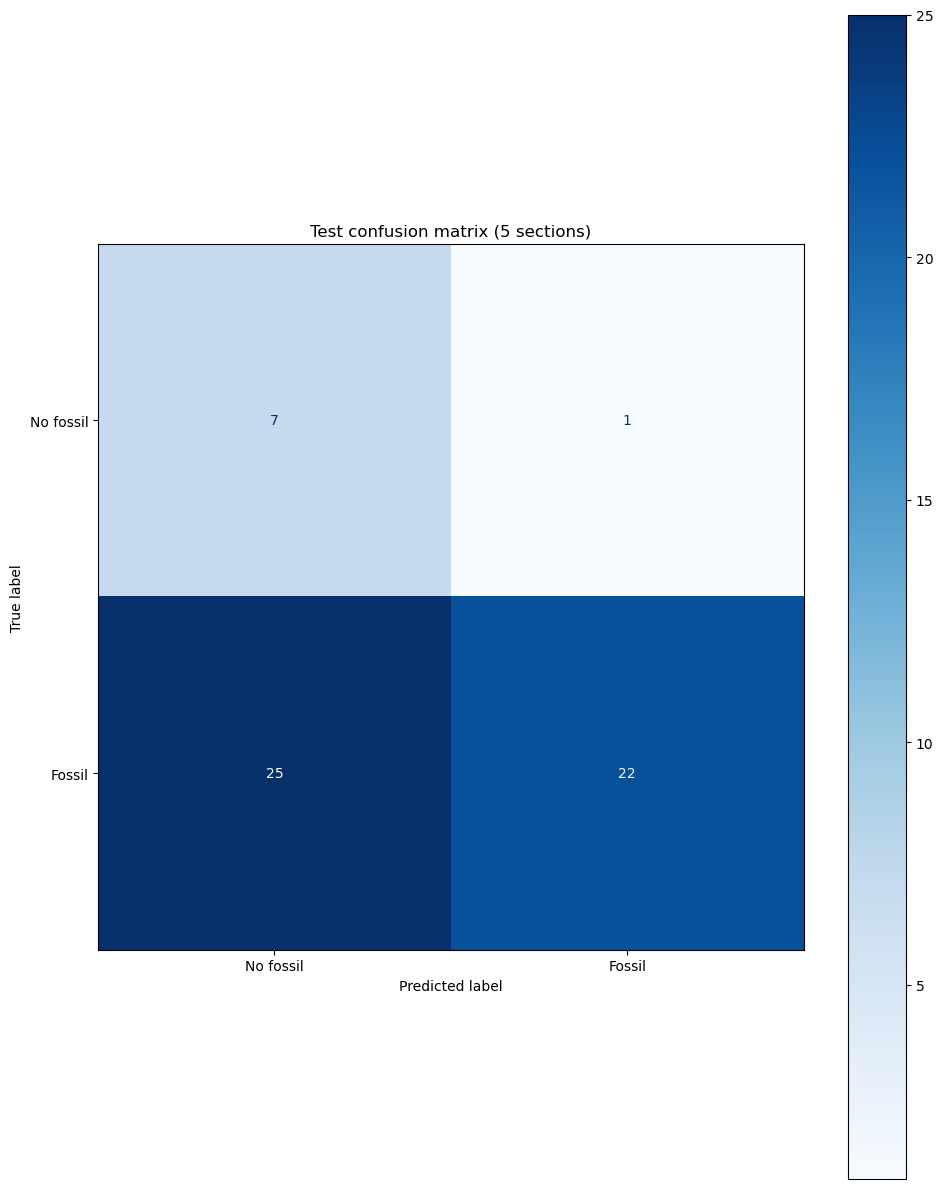

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch1.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch2.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch3.png'
 '../../Data/Center_Fossil/resized_ope_58.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch1.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0a_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch3.png'
 '../../Data/Center_Fossil/resized_ope_90.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opf_16.0b_patch2.png'
 '../../Data/Center_Fossil/resized_opf_16.0c_patch3.png'
 '../../Data/Center_Fossil/resized_opf_16.0d_patch5.png'
 '../

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 577ms/step - auc: 0.8636 - binary_accuracy: 0.7143 - loss: 0.7494 - precision_1: 0.9484 - recall_1: 0.5359 - specificity_at_sensitivity_1: 0.5000 - val_auc: 0.8852 - val_binary_accuracy: 0.7237 - val_loss: 0.5901 - val_precision_1: 0.9924 - val_recall_1: 0.6771 - val_specificity_at_sensitivity_1: 0.5833
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 389ms/step - auc: 0.8888 - binary_accuracy: 0.7844 - loss: 0.6683 - precision_1: 0.9348 - recall_1: 0.6749 - specificity_at_sensitivity_1: 0.6049 - val_auc: 0.8644 - val_binary_accuracy: 0.6886 - val_loss: 1.1404 - val_precision_1: 0.9764 - val_recall_1: 0.6458 - val_specificity_at_sensitivity_1: 0.5278
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 370ms/step - auc: 0.8526 - binary_accuracy: 0.7364 - loss: 0.8902 - precision_1: 0.9551 - recall_1: 0.5717 - specificity_at_sensitivity_1: 0.0000e+00 - val_auc: 0.8811 - val_binary_accuracy: 0.7368 - val_loss: 0.7622 - val_precision_1: 0.9714

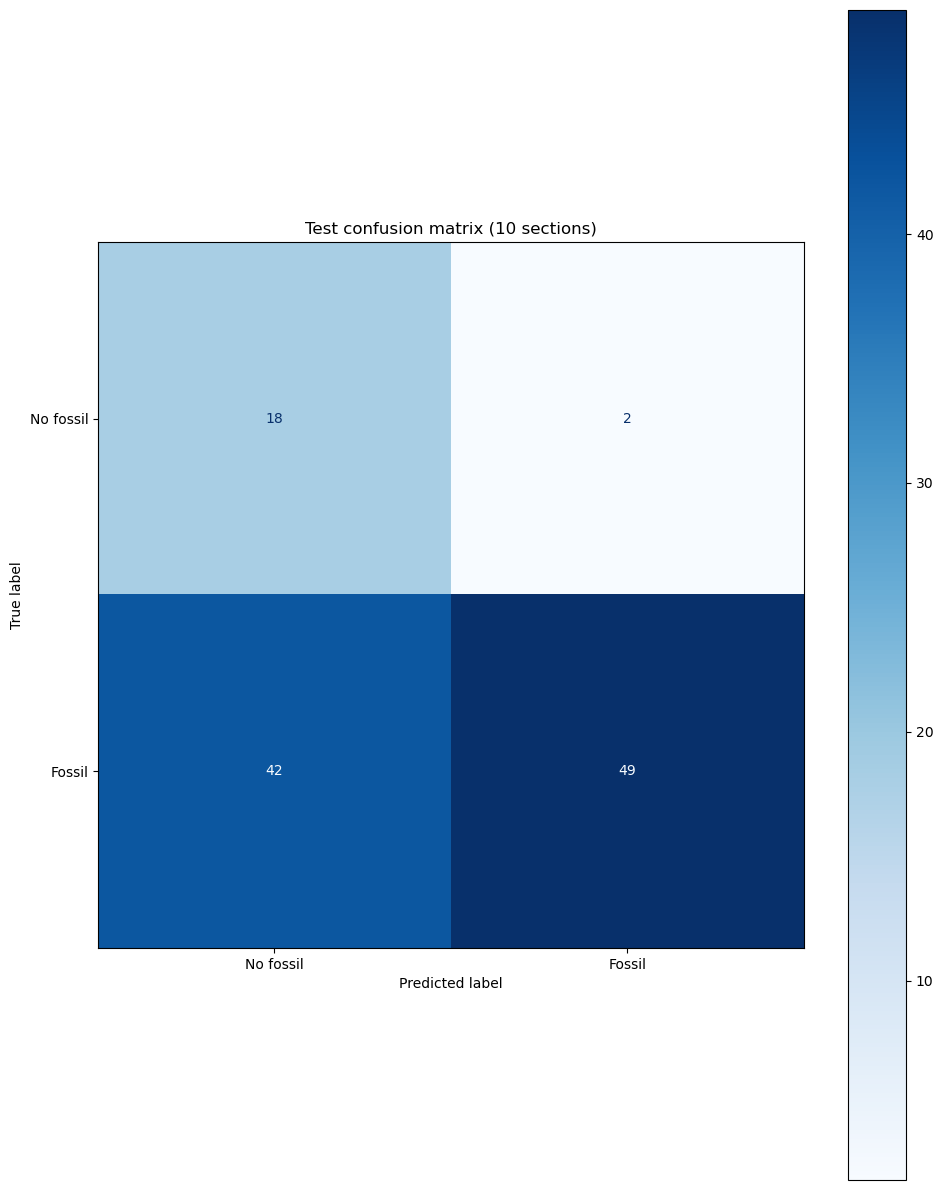

In [7]:
num_sections = [5, 10]
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
center_folder = "../../Data/Center_Fossil"
no_center_fossil_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"
our_layer_histories = []
whole_model_histories = []
test_evals = []
for num_test_sections in num_sections:
    ours, whole_model, eval = model_fit_numbersections_wholepatch_old(num_test_sections)
    our_layer_histories.append(ours)
    whole_model_histories.append(whole_model)
    test_evals.append(eval)

Now, I want to add random contrast to the augmented data and see if that helps. 

In [8]:
# This file path will need to change
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
center_folder = "../../Data/Center_Fossil"
no_center_fossil_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"


def TrainTestValSplit(image_folder, sections):
    test_data_names = []
    remaining_data_names = []

    # List the folder ONCE; each file is checked against ALL sections
    for filename in os.listdir(image_folder):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            filepath = os.path.join(image_folder, filename)
            if any(section in filename for section in sections):
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)

    print(f"Test Data Names from {image_folder}: {np.sort(test_data_names)}")

    # Split remaining data into training and validation sets at random
    random.shuffle(remaining_data_names)
    split = int(len(remaining_data_names) * 0.7)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]
    print(f"Training Data: {np.sort(training_data_names)}")
    print(f"Validation Data: {np.sort(validation_data_names)}")

    # Read in images
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    # Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data

augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25),
    layers.RandomContrast(0.2)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x
def model_fit_numbersections_wholepatch_old(num_test_sections):
    center_folder = "../../Data/Center_Fossil"
    no_center_fossil_folder = "../../Data/No_Center_Fossil"
    no_fossil_folder = "../../Data/No_Fossil"

    #This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
    sections = GetRandomThinSections(image_samples, num_test_sections)
    print(f"Sections Isolated for Testing:")
    print(sections)

    train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
    train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(no_center_fossil_folder, sections)
    train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

    # Now, get label data setting fossils to 1 and no fossil to 0

    Y_train = np.concatenate([np.ones(train_center.shape[0]), np.ones(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
    Y_val = np.concatenate([np.ones(val_center.shape[0]), np.ones(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
    Y_test = np.concatenate([np.ones(test_center.shape[0]), np.ones(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
    training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
    validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
    testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

    # Transform numpy arrays to tf datasets

    training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
    validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
    testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))

    # Shuffle data
    training_data = training_data.shuffle(len(Y_train))
    #validation_data = validation_data.shuffle(len(Y_val))
    #testing_data = testing_data.shuffle(len(Y_test))
    
    # Augment Data
    training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
    )

    nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
    fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

    augfossil = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil2 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil3 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))


    training_data = training_data.concatenate(augfossil)
    training_data = training_data.concatenate(augfossil2)
    training_data = training_data.concatenate(augfossil3)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos

    training_data = training_data.shuffle(n_pos + 3*n_neg)
    
    n_train = sum(1 for _ in training_data)
    training_data = training_data.apply(tf.data.experimental.assert_cardinality(n_train))
    
    # Batch and prefetch data 

    batch_size = 32 # this could change

    training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos
    class_weight = {0: len(Y_train) / (2 * n_neg), 1: len(Y_train) / (2 * n_pos)}
    print(f"train: {len(Y_train)} samples ({n_pos} pos, {n_neg} neg), class_weight={class_weight}")

    THRESH = 0.65   # change this to whatever cutoff you want
    # Create the base model with the pre-trained imagenet weights
    base_model = keras.applications.Xception(
        weights = 'imagenet',
        input_shape = (200, 200, 3),
        include_top = False) # Why do we not include imagenet at the top? 

    # Freeze the base model weights (they will not be trained)
    base_model.trainable = False

    # Create a new model that goes on top of the base imagenet model
    inputs = keras.Input(shape = (200, 200, 3))
    # We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(1.0, fill_mode="reflect")(x)   # full rotation, black corners
    #x = layers.RandomContrast(0.2)(x)
    #x = layers.RandomBrightness(0.2, value_range=(0, 255))(x)

    x = layers.Rescaling(scale=1/127.5, offset=-1)(x)
    #x = layers.AutoContrast(value_range = (0, 255))(x)
    x = base_model(x, training=False)                         # (batch, 7, 7, 2048)
    # Combine average pooling (overall context) with max pooling (strongest local response)
    avg_pool = layers.GlobalAveragePooling2D()(x)             # (batch, 2048)
    max_pool = layers.GlobalMaxPooling2D()(x)                 # (batch, 2048)
    x = layers.Concatenate()([avg_pool, max_pool])            # (batch, 4096)

    x = layers.Dropout(0.1)(x)
    x = layers.Dense(128, activation="relu")(x)               # hidden layer
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    # Central-region pooling + global context
    #center = layers.Cropping2D(cropping=((3, 3), (3, 3)))(x)  # central 3x3 of the 7x7 map
    #center = layers.GlobalAveragePooling2D()(center)
    #context = layers.GlobalAveragePooling2D()(x)
    #x = layers.Concatenate()([center, context])
    #x = layers.GlobalAveragePooling2D()(x)

   # x = layers.Dropout(0.1)(x)
    #outputs = layers.Dense(1, activation="sigmoid")(x)
    #model = keras.Model(inputs, outputs)

    model.summary(show_trainable = True)

    # Train the new top layer of the model
    model.compile(
        optimizer = keras.optimizers.Adam(), # play with this also
        loss = keras.losses.BinaryCrossentropy(), #check this also
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)]
    )

    epochs = 20 # also play with this
    print(f"Fitting top layer of model")
    early_stop = keras.callbacks.EarlyStopping(
            monitor = "val_auc", mode = "max", patience = 5, restore_best_weights = True)
    
    history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data, class_weight = class_weight, callbacks = [early_stop])

    # Fine tune entire model
    # Fine tune (gently)
    base_model.trainable = True

    # Keep everything frozen except the last 30 layers

    # Keep batch norm layers frozen so the pretrained statistics aren't disturbed
    for layer in base_model.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    model.summary(show_trainable=True)   # now shows the real trainable state

    model.compile(
        optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
        loss = keras.losses.BinaryCrossentropy(),
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(name="auc"), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)] #check this -- we have a binary model so it should be ok
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor = "val_auc", mode = "max", patience = 2, restore_best_weights = True)

    epochs = 5 #??
    print(f"Fitting end-to-end model")
    history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data, callbacks = [early_stop], class_weight = class_weight)
        # Validate model on test data
    print(f"Test dataset evaluation:")
    test_eval = model.evaluate(testing_data)
        # ---- Confusion matrix on the test set ----
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    # Test data is not shuffled, so predictions line up with Y_test
    y_prob = model.predict(testing_data).ravel()
    y_pred = (y_prob >= THRESH).astype(int)
    y_true = Y_test.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion matrix ({num_test_sections} test sections):")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

    fig, ax = plt.subplots(figsize=(10, 12))
    ConfusionMatrixDisplay(cm, display_labels=["No fossil", "Fossil"]).plot(
        ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Test confusion matrix ({num_test_sections} sections)")
    plt.tight_layout()
    plt.show()
    
    del model, base_model, training_data, validation_data, testing_data
    keras.backend.clear_session()
    gc.collect()
    return history_our_layers, history_whole_model, test_eval

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch1.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch2.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch3.png'
 '../../Data/Center_Fossil/resized_ope_58.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0a_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch3.png'
 '../../Data/Center_Fossil/resized_ope_90.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opf_69.0_patch1.png'
 '../../Data/Center_Fossil/resized_opf_9.0a_patch5.png']
Training Data: ['../../Data/Center_Fossil/resized_opb_15.4c_patch2.png'
 '../../Data/Center_Fossil/resized_opb_19.2b_patch1.png'
 '../../Data/Center_Fossil/resized_opb_19.2b_patch5.png'
 '../../Data/Center_Fossil/resized_opb_19.2e_patch3

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip_1     │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation_1 │ (None, 200,     │         0 │ random_flip_1… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 632ms/step - auc: 0.9054 - binary_accuracy: 0.7754 - loss: 0.5495 - precision_1: 0.9446 - recall_1: 0.6436 - specificity_at_sensitivity_1: 0.6306 - val_auc: 0.8561 - val_binary_accuracy: 0.6803 - val_loss: 0.8626 - val_precision_1: 0.9704 - val_recall_1: 0.6390 - val_specificity_at_sensitivity_1: 0.5641
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 407ms/step - auc: 0.9035 - binary_accuracy: 0.7933 - loss: 0.5366 - precision_1: 0.9606 - recall_1: 0.6646 - specificity_at_sensitivity_1: 0.7111 - val_auc: 0.8699 - val_binary_accuracy: 0.7090 - val_loss: 0.7892 - val_precision_1: 0.9589 - val_recall_1: 0.6829 - val_specificity_at_sensitivity_1: 0.5385
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 385ms/step - auc: 0.9199 - binary_accuracy: 0.8112 - loss: 0.5612 - precision_1: 0.9650 - recall_1: 0.6939 - specificity_at_sensitivity_1: 0.7278 - val_auc: 0.8701 - val_binary_accuracy: 0.6926 - val_loss: 1.0108 - val_precision_1: 0.9643 - v

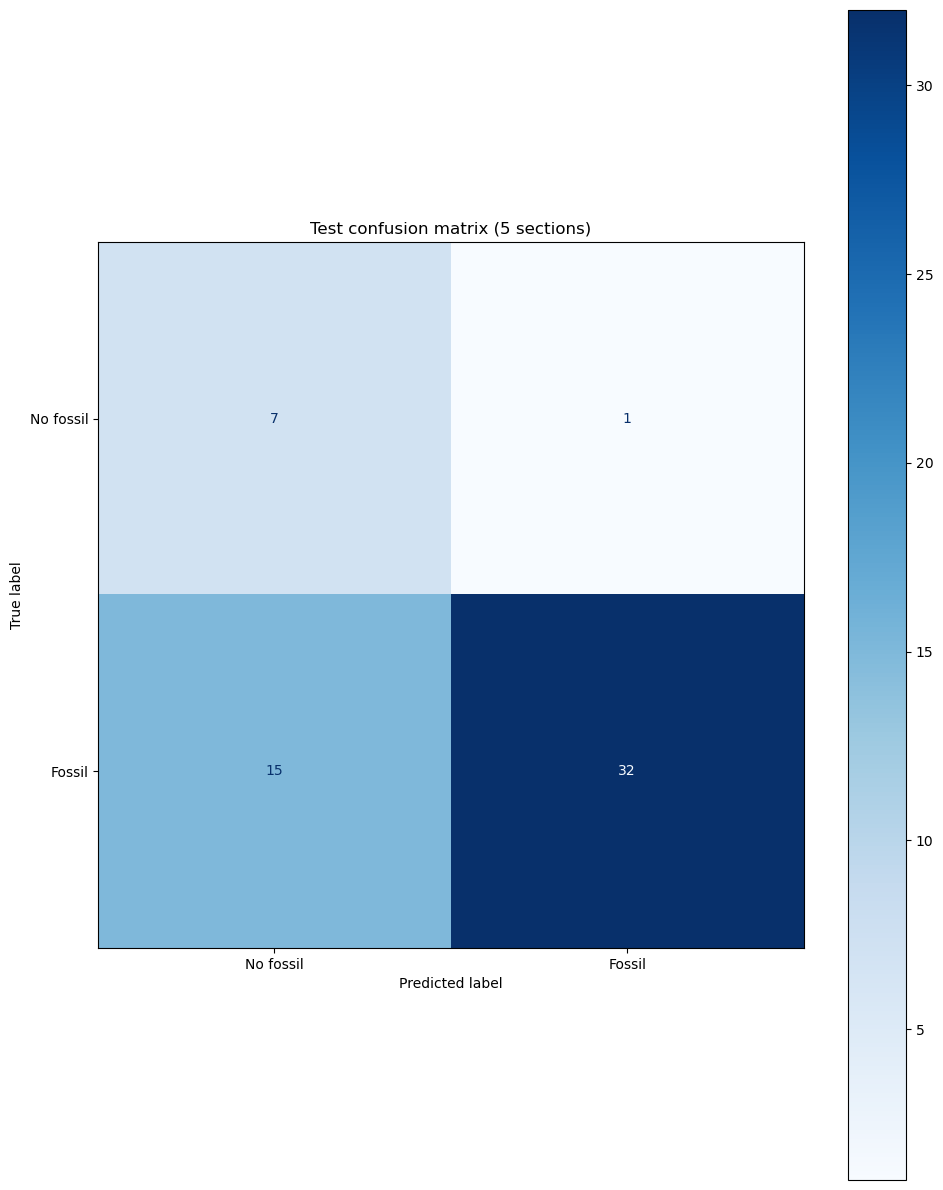

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch1.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch2.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch3.png'
 '../../Data/Center_Fossil/resized_ope_58.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch1.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0a_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch3.png'
 '../../Data/Center_Fossil/resized_ope_90.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opf_16.0b_patch2.png'
 '../../Data/Center_Fossil/resized_opf_16.0c_patch3.png'
 '../../Data/Center_Fossil/resized_opf_16.0d_patch5.png'
 '../

2026-09-29 13:26:10.321229: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


train: 527 samples (446 pos, 81 neg), class_weight={0: 3.253086419753086, 1: 0.5908071748878924}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 674ms/step - auc: 0.8695 - binary_accuracy: 0.7299 - loss: 0.6865 - precision_1: 0.9508 - recall_1: 0.5628 - specificity_at_sensitivity_1: 0.5216 - val_auc: 0.8827 - val_binary_accuracy: 0.7719 - val_loss: 0.6270 - val_precision_1: 0.9667 - val_recall_1: 0.7552 - val_specificity_at_sensitivity_1: 0.6667
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 410ms/step - auc: 0.8975 - binary_accuracy: 0.7961 - loss: 0.5866 - precision_1: 0.9530 - recall_1: 0.6816 - specificity_at_sensitivity_1: 0.6265 - val_auc: 0.8905 - val_binary_accuracy: 0.7368 - val_loss: 0.6567 - val_precision_1: 0.9583 - val_recall_1: 0.7188 - val_specificity_at_sensitivity_1: 0.6944
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 419ms/step - auc: 0.9148 - binary_accuracy: 0.7909 - loss: 0.5564 - precision_1: 0.9553 - recall_1: 0.6704 - specificity_at_sensitivity_1: 0.7222 - val_auc: 0.8956 - val_binary_accuracy: 0.7281 - val_loss: 0.7016 - val_precision_1: 0.9710 - v

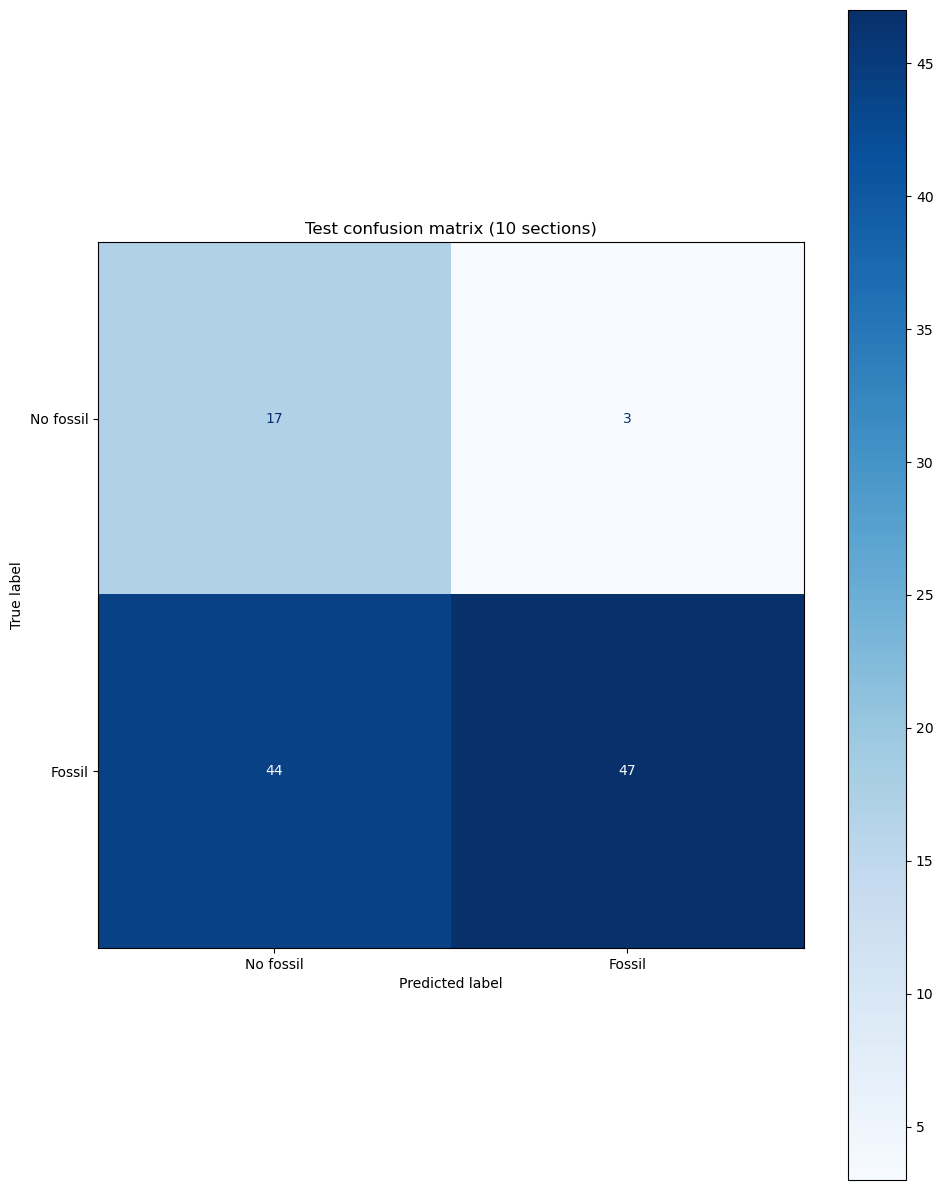

In [9]:
num_sections = [5, 10]
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
center_folder = "../../Data/Center_Fossil"
no_center_fossil_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"
our_layer_histories = []
whole_model_histories = []
test_evals = []
for num_test_sections in num_sections:
    ours, whole_model, eval = model_fit_numbersections_wholepatch_old(num_test_sections)
    our_layer_histories.append(ours)
    whole_model_histories.append(whole_model)
    test_evals.append(eval)

What happens on the best model if instead I choose to do early stopping with the binary accuracy? 

In [10]:
# This file path will need to change
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
center_folder = "../../Data/Center_Fossil"
no_center_fossil_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"


def TrainTestValSplit(image_folder, sections):
    test_data_names = []
    remaining_data_names = []

    # List the folder ONCE; each file is checked against ALL sections
    for filename in os.listdir(image_folder):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            filepath = os.path.join(image_folder, filename)
            if any(section in filename for section in sections):
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)

    print(f"Test Data Names from {image_folder}: {np.sort(test_data_names)}")

    # Split remaining data into training and validation sets at random
    random.shuffle(remaining_data_names)
    split = int(len(remaining_data_names) * 0.7)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]
    print(f"Training Data: {np.sort(training_data_names)}")
    print(f"Validation Data: {np.sort(validation_data_names)}")

    # Read in images
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    # Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data

augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25),
    layers.RandomContrast(0.2)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x
def model_fit_numbersections_wholepatch_old(num_test_sections):
    center_folder = "../../Data/Center_Fossil"
    no_center_fossil_folder = "../../Data/No_Center_Fossil"
    no_fossil_folder = "../../Data/No_Fossil"

    #This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
    sections = GetRandomThinSections(image_samples, num_test_sections)
    print(f"Sections Isolated for Testing:")
    print(sections)

    train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
    train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(no_center_fossil_folder, sections)
    train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

    # Now, get label data setting fossils to 1 and no fossil to 0

    Y_train = np.concatenate([np.ones(train_center.shape[0]), np.ones(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
    Y_val = np.concatenate([np.ones(val_center.shape[0]), np.ones(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
    Y_test = np.concatenate([np.ones(test_center.shape[0]), np.ones(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
    training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
    validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
    testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

    # Transform numpy arrays to tf datasets

    training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
    validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
    testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))

    # Shuffle data
    training_data = training_data.shuffle(len(Y_train))
    #validation_data = validation_data.shuffle(len(Y_val))
    #testing_data = testing_data.shuffle(len(Y_test))
    
    # Augment Data
    training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
    )

    nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
    fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

    augfossil = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil2 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil3 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))


    training_data = training_data.concatenate(augfossil)
    training_data = training_data.concatenate(augfossil2)
    training_data = training_data.concatenate(augfossil3)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos

    training_data = training_data.shuffle(n_pos + 3*n_neg)
    
    n_train = sum(1 for _ in training_data)
    training_data = training_data.apply(tf.data.experimental.assert_cardinality(n_train))
    
    # Batch and prefetch data 

    batch_size = 32 # this could change

    training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos
    class_weight = {0: len(Y_train) / (2 * n_neg), 1: len(Y_train) / (2 * n_pos)}
    print(f"train: {len(Y_train)} samples ({n_pos} pos, {n_neg} neg), class_weight={class_weight}")

    THRESH = 0.65   # change this to whatever cutoff you want
    # Create the base model with the pre-trained imagenet weights
    base_model = keras.applications.Xception(
        weights = 'imagenet',
        input_shape = (200, 200, 3),
        include_top = False) # Why do we not include imagenet at the top? 

    # Freeze the base model weights (they will not be trained)
    base_model.trainable = False

    # Create a new model that goes on top of the base imagenet model
    inputs = keras.Input(shape = (200, 200, 3))
    # We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(1.0, fill_mode="reflect")(x)   # full rotation, black corners
    #x = layers.RandomContrast(0.2)(x)
    #x = layers.RandomBrightness(0.2, value_range=(0, 255))(x)

    x = layers.Rescaling(scale=1/127.5, offset=-1)(x)
    #x = layers.AutoContrast(value_range = (0, 255))(x)
    x = base_model(x, training=False)                         # (batch, 7, 7, 2048)
    # Combine average pooling (overall context) with max pooling (strongest local response)
    avg_pool = layers.GlobalAveragePooling2D()(x)             # (batch, 2048)
    max_pool = layers.GlobalMaxPooling2D()(x)                 # (batch, 2048)
    x = layers.Concatenate()([avg_pool, max_pool])            # (batch, 4096)

    x = layers.Dropout(0.1)(x)
    x = layers.Dense(128, activation="relu")(x)               # hidden layer
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    # Central-region pooling + global context
    #center = layers.Cropping2D(cropping=((3, 3), (3, 3)))(x)  # central 3x3 of the 7x7 map
    #center = layers.GlobalAveragePooling2D()(center)
    #context = layers.GlobalAveragePooling2D()(x)
    #x = layers.Concatenate()([center, context])
    #x = layers.GlobalAveragePooling2D()(x)

   # x = layers.Dropout(0.1)(x)
    #outputs = layers.Dense(1, activation="sigmoid")(x)
    #model = keras.Model(inputs, outputs)

    model.summary(show_trainable = True)

    # Train the new top layer of the model
    model.compile(
        optimizer = keras.optimizers.Adam(), # play with this also
        loss = keras.losses.BinaryCrossentropy(), #check this also
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)]
    )

    epochs = 20 # also play with this
    print(f"Fitting top layer of model")
    early_stop = keras.callbacks.EarlyStopping(
            monitor = "val_binary_accuracy", mode = "max", patience = 5, restore_best_weights = True)
    
    history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data, class_weight = class_weight, callbacks = [early_stop])

    # Fine tune entire model
    # Fine tune (gently)
    base_model.trainable = True

    # Keep everything frozen except the last 30 layers

    # Keep batch norm layers frozen so the pretrained statistics aren't disturbed
    for layer in base_model.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    model.summary(show_trainable=True)   # now shows the real trainable state

    model.compile(
        optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
        loss = keras.losses.BinaryCrossentropy(),
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(name="auc"), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)] #check this -- we have a binary model so it should be ok
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor = "val_binary_accuracy", mode = "max", patience = 2, restore_best_weights = True)

    epochs = 5 #??
    print(f"Fitting end-to-end model")
    history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data, callbacks = [early_stop], class_weight = class_weight)
        # Validate model on test data
    print(f"Test dataset evaluation:")
    test_eval = model.evaluate(testing_data)
        # ---- Confusion matrix on the test set ----
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    # Test data is not shuffled, so predictions line up with Y_test
    y_prob = model.predict(testing_data).ravel()
    y_pred = (y_prob >= THRESH).astype(int)
    y_true = Y_test.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion matrix ({num_test_sections} test sections):")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

    fig, ax = plt.subplots(figsize=(10, 12))
    ConfusionMatrixDisplay(cm, display_labels=["No fossil", "Fossil"]).plot(
        ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Test confusion matrix ({num_test_sections} sections)")
    plt.tight_layout()
    plt.show()
    
    del model, base_model, training_data, validation_data, testing_data
    keras.backend.clear_session()
    gc.collect()
    return history_our_layers, history_whole_model, test_eval

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch1.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch2.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch3.png'
 '../../Data/Center_Fossil/resized_ope_58.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0a_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch3.png'
 '../../Data/Center_Fossil/resized_ope_90.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opf_69.0_patch1.png'
 '../../Data/Center_Fossil/resized_opf_9.0a_patch5.png']
Training Data: ['../../Data/Center_Fossil/resized_opb_15.4c_patch2.png'
 '../../Data/Center_Fossil/resized_opb_19.2b_patch1.png'
 '../../Data/Center_Fossil/resized_opb_19.2b_patch3.png'
 '../../Data/Center_Fossil/resized_opb_19.2c_patch2

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip_1     │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation_1 │ (None, 200,     │         0 │ random_flip_1… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 633ms/step - auc: 0.8045 - binary_accuracy: 0.6798 - loss: 0.9951 - precision_1: 0.9098 - recall_1: 0.4864 - specificity_at_sensitivity_1: 0.3833 - val_auc: 0.8672 - val_binary_accuracy: 0.5861 - val_loss: 1.1177 - val_precision_1: 1.0000 - val_recall_1: 0.5073 - val_specificity_at_sensitivity_1: 0.4615
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 417ms/step - auc: 0.8064 - binary_accuracy: 0.6607 - loss: 0.8481 - precision_1: 0.9289 - recall_1: 0.4382 - specificity_at_sensitivity_1: 0.0000e+00 - val_auc: 0.8775 - val_binary_accuracy: 0.6557 - val_loss: 0.8379 - val_precision_1: 1.0000 - val_recall_1: 0.5902 - val_specificity_at_sensitivity_1: 0.5385
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 385ms/step - auc: 0.8456 - binary_accuracy: 0.7109 - loss: 0.7472 - precision_1: 0.9181 - recall_1: 0.5409 - specificity_at_sensitivity_1: 0.4417 - val_auc: 0.8864 - val_binary_accuracy: 0.6557 - val_loss: 0.8541 - val_precision_1: 0.9919

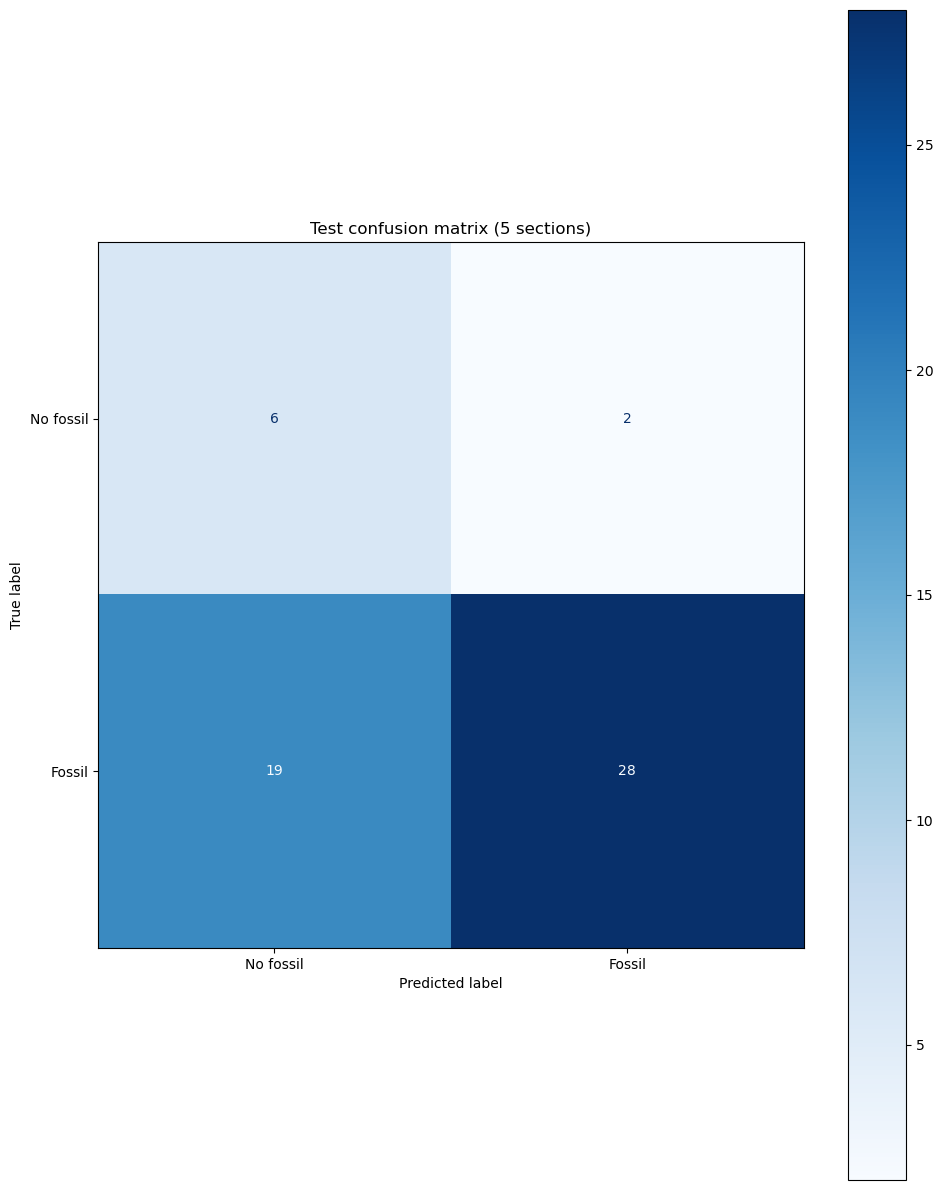

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch1.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch2.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch3.png'
 '../../Data/Center_Fossil/resized_ope_58.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch1.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0a_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch3.png'
 '../../Data/Center_Fossil/resized_ope_90.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opf_16.0b_patch2.png'
 '../../Data/Center_Fossil/resized_opf_16.0c_patch3.png'
 '../../Data/Center_Fossil/resized_opf_16.0d_patch5.png'
 '../

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 686ms/step - auc: 0.8852 - binary_accuracy: 0.7831 - loss: 0.6748 - precision_1: 0.9515 - recall_1: 0.6592 - specificity_at_sensitivity_1: 0.6019 - val_auc: 0.8822 - val_binary_accuracy: 0.7412 - val_loss: 0.6513 - val_precision_1: 0.9716 - val_recall_1: 0.7135 - val_specificity_at_sensitivity_1: 0.5833
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 428ms/step - auc: 0.9059 - binary_accuracy: 0.7649 - loss: 0.5934 - precision_1: 0.9492 - recall_1: 0.6278 - specificity_at_sensitivity_1: 0.7130 - val_auc: 0.8814 - val_binary_accuracy: 0.7588 - val_loss: 0.6903 - val_precision_1: 0.9660 - val_recall_1: 0.7396 - val_specificity_at_sensitivity_1: 0.5833
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 389ms/step - auc: 0.9052 - binary_accuracy: 0.7974 - loss: 0.6218 - precision_1: 0.9503 - recall_1: 0.6861 - specificity_at_sensitivity_1: 0.6975 - val_auc: 0.8635 - val_binary_accuracy: 0.6667 - val_loss: 1.1774 - val_precision_1: 0.9915 - v

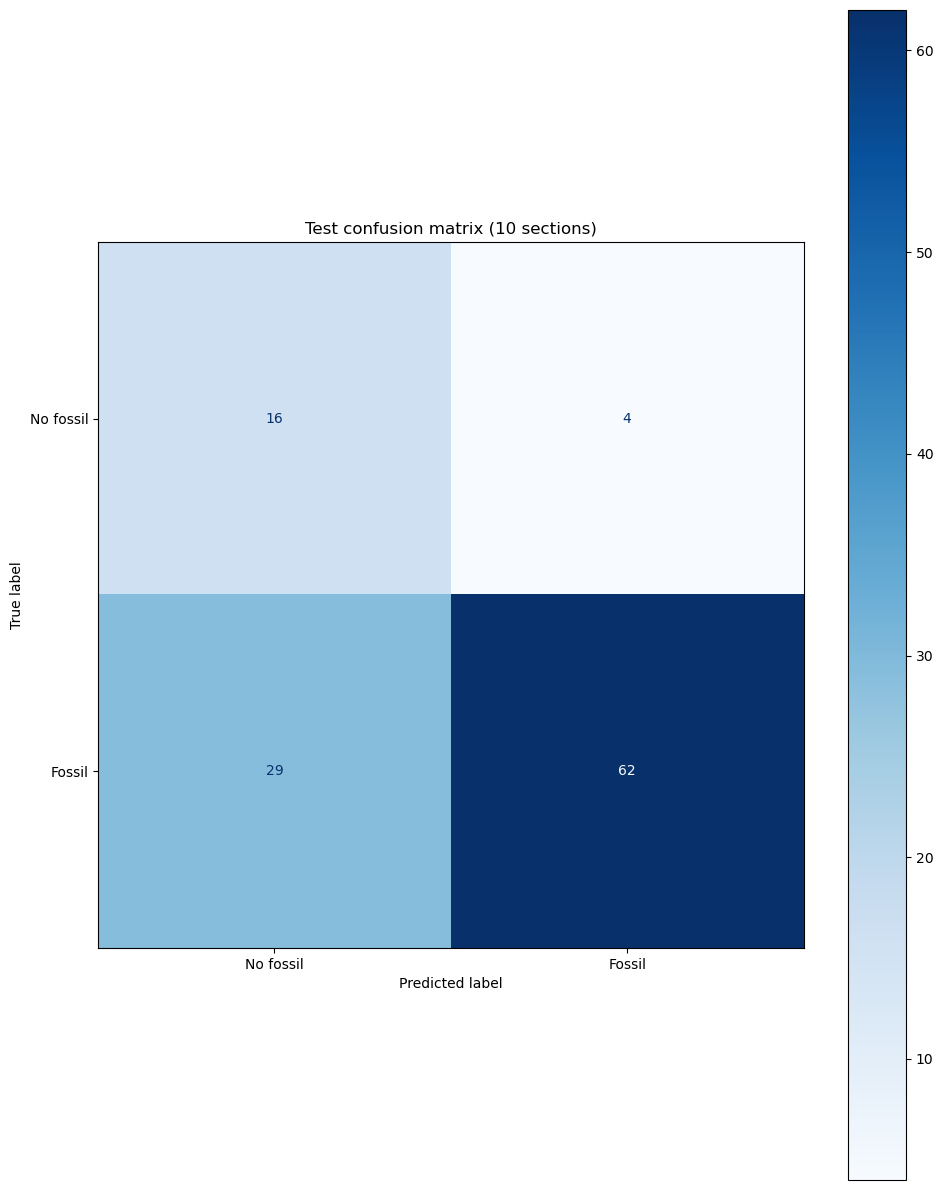

In [11]:
num_sections = [5, 10]
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
center_folder = "../../Data/Center_Fossil"
no_center_fossil_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"
our_layer_histories = []
whole_model_histories = []
test_evals = []
for num_test_sections in num_sections:
    ours, whole_model, eval = model_fit_numbersections_wholepatch_old(num_test_sections)
    our_layer_histories.append(ours)
    whole_model_histories.append(whole_model)
    test_evals.append(eval)

Lower threshold

In [16]:
# This file path will need to change
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
center_folder = "../../Data/Center_Fossil"
no_center_fossil_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"


def TrainTestValSplit(image_folder, sections):
    test_data_names = []
    remaining_data_names = []

    # List the folder ONCE; each file is checked against ALL sections
    for filename in os.listdir(image_folder):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            filepath = os.path.join(image_folder, filename)
            if any(section in filename for section in sections):
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)

    print(f"Test Data Names from {image_folder}: {np.sort(test_data_names)}")

    # Split remaining data into training and validation sets at random
    random.shuffle(remaining_data_names)
    split = int(len(remaining_data_names) * 0.7)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]
    print(f"Training Data: {np.sort(training_data_names)}")
    print(f"Validation Data: {np.sort(validation_data_names)}")

    # Read in images
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    # Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data

augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25),
    layers.RandomContrast(0.2)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x
def model_fit_numbersections_wholepatch_old(num_test_sections):
    center_folder = "../../Data/Center_Fossil"
    no_center_fossil_folder = "../../Data/No_Center_Fossil"
    no_fossil_folder = "../../Data/No_Fossil"

    #This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
    sections = GetRandomThinSections(image_samples, num_test_sections)
    print(f"Sections Isolated for Testing:")
    print(sections)

    train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
    train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(no_center_fossil_folder, sections)
    train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

    # Now, get label data setting fossils to 1 and no fossil to 0

    Y_train = np.concatenate([np.ones(train_center.shape[0]), np.ones(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
    Y_val = np.concatenate([np.ones(val_center.shape[0]), np.ones(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
    Y_test = np.concatenate([np.ones(test_center.shape[0]), np.ones(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
    training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
    validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
    testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

    # Transform numpy arrays to tf datasets

    training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
    validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
    testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))

    # Shuffle data
    training_data = training_data.shuffle(len(Y_train))
    #validation_data = validation_data.shuffle(len(Y_val))
    #testing_data = testing_data.shuffle(len(Y_test))
    
    # Augment Data
    training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
    )

    nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
    fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

    augfossil = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil2 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil3 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))


    training_data = training_data.concatenate(augfossil)
    training_data = training_data.concatenate(augfossil2)
    training_data = training_data.concatenate(augfossil3)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos

    training_data = training_data.shuffle(n_pos + 3*n_neg)
    
    n_train = sum(1 for _ in training_data)
    training_data = training_data.apply(tf.data.experimental.assert_cardinality(n_train))
    
    # Batch and prefetch data 

    batch_size = 32 # this could change

    training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos
    class_weight = {0: len(Y_train) / (2 * n_neg), 1: len(Y_train) / (2 * n_pos)}
    print(f"train: {len(Y_train)} samples ({n_pos} pos, {n_neg} neg), class_weight={class_weight}")

    THRESH = 0.55   # change this to whatever cutoff you want
    # Create the base model with the pre-trained imagenet weights
    base_model = keras.applications.Xception(
        weights = 'imagenet',
        input_shape = (200, 200, 3),
        include_top = False) # Why do we not include imagenet at the top? 

    # Freeze the base model weights (they will not be trained)
    base_model.trainable = False

    # Create a new model that goes on top of the base imagenet model
    inputs = keras.Input(shape = (200, 200, 3))
    # We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(1.0, fill_mode="reflect")(x)   # full rotation, black corners
    #x = layers.RandomContrast(0.2)(x)
    #x = layers.RandomBrightness(0.2, value_range=(0, 255))(x)

    x = layers.Rescaling(scale=1/127.5, offset=-1)(x)
    #x = layers.AutoContrast(value_range = (0, 255))(x)
    x = base_model(x, training=False)                         # (batch, 7, 7, 2048)
    # Combine average pooling (overall context) with max pooling (strongest local response)
    avg_pool = layers.GlobalAveragePooling2D()(x)             # (batch, 2048)
    max_pool = layers.GlobalMaxPooling2D()(x)                 # (batch, 2048)
    x = layers.Concatenate()([avg_pool, max_pool])            # (batch, 4096)

    x = layers.Dropout(0.1)(x)
    x = layers.Dense(128, activation="relu")(x)               # hidden layer
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    # Central-region pooling + global context
    #center = layers.Cropping2D(cropping=((3, 3), (3, 3)))(x)  # central 3x3 of the 7x7 map
    #center = layers.GlobalAveragePooling2D()(center)
    #context = layers.GlobalAveragePooling2D()(x)
    #x = layers.Concatenate()([center, context])
    #x = layers.GlobalAveragePooling2D()(x)

   # x = layers.Dropout(0.1)(x)
    #outputs = layers.Dense(1, activation="sigmoid")(x)
    #model = keras.Model(inputs, outputs)

    model.summary(show_trainable = True)

    # Train the new top layer of the model
    model.compile(
        optimizer = keras.optimizers.Adam(), # play with this also
        loss = keras.losses.BinaryCrossentropy(), #check this also
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)]
    )

    epochs = 20 # also play with this
    print(f"Fitting top layer of model")
    early_stop = keras.callbacks.EarlyStopping(
            monitor = "val_auc", mode = "max", patience = 10, restore_best_weights = True)
    
    history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data, class_weight = class_weight, callbacks = [early_stop])

    # Fine tune entire model
    # Fine tune (gently)
    base_model.trainable = True

    # Keep everything frozen except the last 30 layers

    # Keep batch norm layers frozen so the pretrained statistics aren't disturbed
    for layer in base_model.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    model.summary(show_trainable=True)   # now shows the real trainable state

    model.compile(
        optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
        loss = keras.losses.BinaryCrossentropy(),
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(name="auc"), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)] #check this -- we have a binary model so it should be ok
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor = "val_auc", mode = "max", patience = 5, restore_best_weights = True)

    epochs = 8 #??
    print(f"Fitting end-to-end model")
    history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data, callbacks = [early_stop], class_weight = class_weight)
        # Validate model on test data
    print(f"Test dataset evaluation:")
    test_eval = model.evaluate(testing_data)
        # ---- Confusion matrix on the test set ----
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    # Test data is not shuffled, so predictions line up with Y_test
    y_prob = model.predict(testing_data).ravel()
    y_pred = (y_prob >= THRESH).astype(int)
    y_true = Y_test.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion matrix ({num_test_sections} test sections):")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

    fig, ax = plt.subplots(figsize=(10, 12))
    ConfusionMatrixDisplay(cm, display_labels=["No fossil", "Fossil"]).plot(
        ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Test confusion matrix ({num_test_sections} sections)")
    plt.tight_layout()
    plt.show()
    
    del model, base_model, training_data, validation_data, testing_data
    keras.backend.clear_session()
    gc.collect()
    return history_our_layers, history_whole_model, test_eval

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch1.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch2.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch3.png'
 '../../Data/Center_Fossil/resized_ope_58.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch1.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0a_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch3.png'
 '../../Data/Center_Fossil/resized_ope_90.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opf_16.0b_patch2.png'
 '../../Data/Center_Fossil/resized_opf_16.0c_patch3.png'
 '../../Data/Center_Fossil/resized_opf_16.0d_patch5.png'
 '../

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip_1     │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation_1 │ (None, 200,     │         0 │ random_flip_1… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - auc: 0.9114 - binary_accuracy: 0.8000 - loss: 0.5701 - precision_1: 0.9563 - recall_1: 0.6861 - specificity_at_sensitivity_1: 0.7222 - val_auc: 0.8792 - val_binary_accuracy: 0.8026 - val_loss: 0.6170 - val_precision_1: 0.9623 - val_recall_1: 0.7969 - val_specificity_at_sensitivity_1: 0.6944
Epoch 2/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 525ms/step - auc: 0.9331 - binary_accuracy: 0.8403 - loss: 0.4513 - precision_1: 0.9628 - recall_1: 0.7534 - specificity_at_sensitivity_1: 0.7870 - val_auc: 0.8903 - val_binary_accuracy: 0.8816 - val_loss: 0.4324 - val_precision_1: 0.9661 - val_recall_1: 0.8906 - val_specificity_at_sensitivity_1: 0.8333
Epoch 3/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 469ms/step - auc: 0.9354 - binary_accuracy: 0.8506 - loss: 0.4322 - precision_1: 0.9688 - recall_1: 0.7668 - specificity_at_sensitivity_1: 0.8210 - val_auc: 0.8978 - val_binary_accuracy: 0.8246 - val_loss: 0.5257 - val_precision_1: 0.9634 - val_

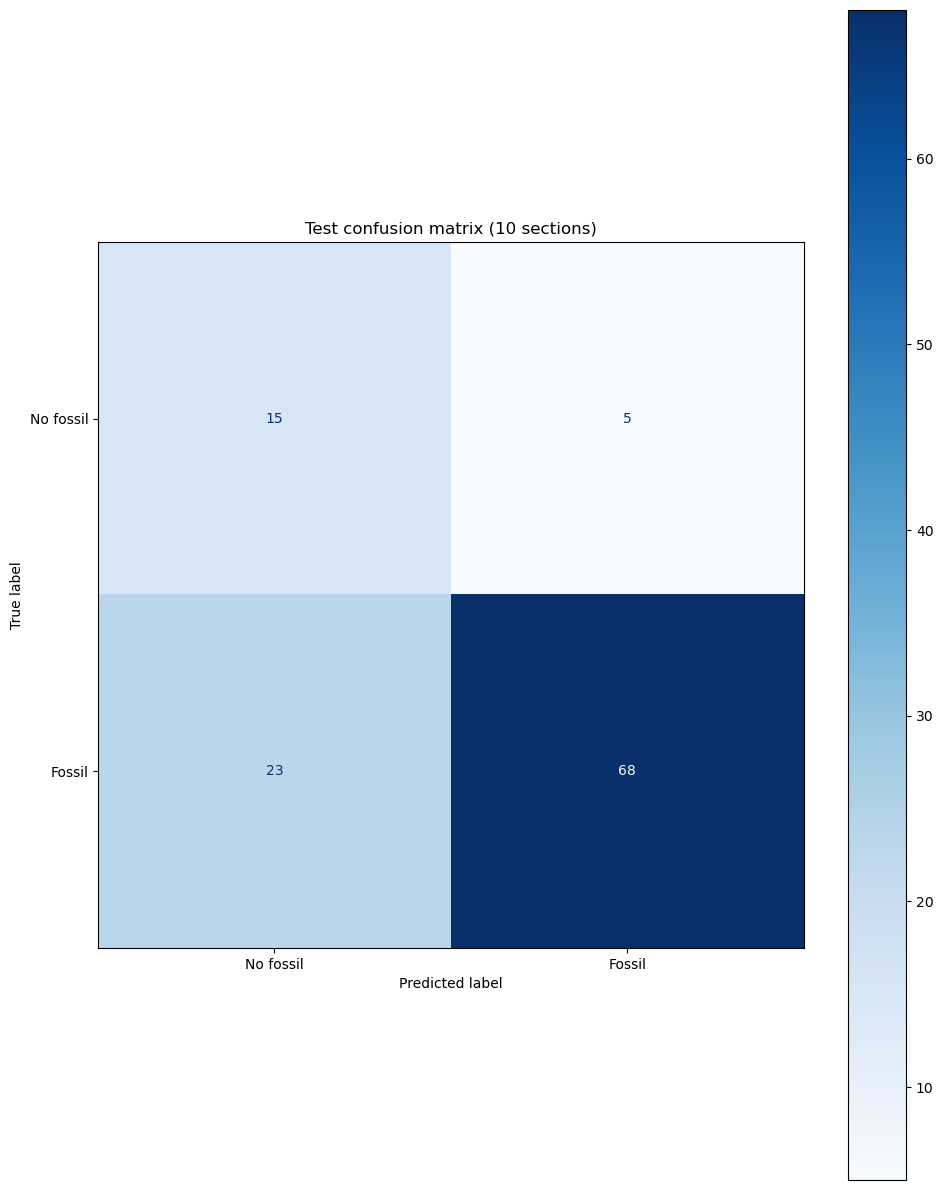

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0', 'opf_81.0', 'opf_41.0', 'opf_11.2', 'ope_39.6', 'opf_81.0', 'opd_89.0', 'ope_37.5', 'ope_18.0', 'ope_101.1', 'ope_54.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_opd_89.0b_patch2.png'
 '../../Data/Center_Fossil/resized_opd_89.0b_patch4.png'
 '../../Data/Center_Fossil/resized_ope_101.1_patch3.png'
 '../../Data/Center_Fossil/resized_ope_101.1_patch5.png'
 '../../Data/Center_Fossil/resized_ope_54.0_patch4.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch1.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch2.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch3.png'
 '../../Data/Center_Fossil/resized_ope_58.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch1.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch5.png'

2026-09-29 13:54:48.973420: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


train: 469 samples (395 pos, 74 neg), class_weight={0: 3.168918918918919, 1: 0.5936708860759494}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - auc: 0.9049 - binary_accuracy: 0.7902 - loss: 0.5643 - precision_1: 0.9529 - recall_1: 0.6658 - specificity_at_sensitivity_1: 0.6622 - val_auc: 0.8532 - val_binary_accuracy: 0.7192 - val_loss: 1.0288 - val_precision_1: 0.9672 - val_recall_1: 0.6901 - val_specificity_at_sensitivity_1: 0.4688
Epoch 2/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 647ms/step - auc: 0.8950 - binary_accuracy: 0.8061 - loss: 0.7049 - precision_1: 0.9279 - recall_1: 0.7165 - specificity_at_sensitivity_1: 0.6318 - val_auc: 0.8480 - val_binary_accuracy: 0.7044 - val_loss: 1.3185 - val_precision_1: 0.9744 - val_recall_1: 0.6667 - val_specificity_at_sensitivity_1: 0.0000e+00
Epoch 3/8
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 483ms/step - auc: 0.8566 - binary_accuracy: 0.7713 - loss: 1.0186 - precision_1: 0.9247 - recall_1: 0.6532 - specificity_at_sensitivity_1: 0.0000e+00 - val_auc: 0.8746 - val_binary_accuracy: 0.7537 - val_loss: 1.0687 - val_precision_1: 0.976

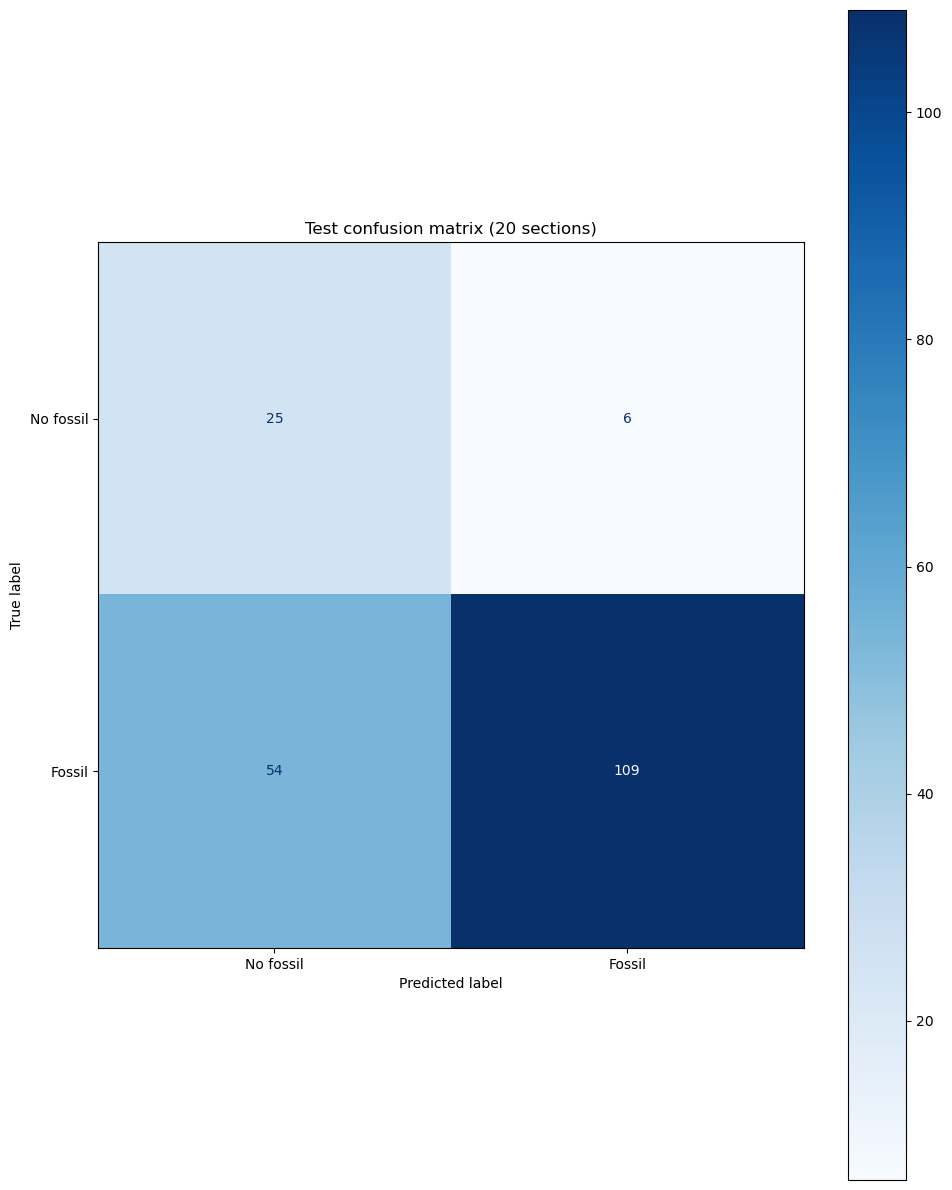

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0', 'opf_81.0', 'opf_41.0', 'opf_11.2', 'ope_39.6', 'opf_81.0', 'opd_89.0', 'ope_37.5', 'ope_18.0', 'ope_101.1', 'ope_54.0', 'opb_34.1', 'ope_30.0', 'ope_34.0', 'ope_86.0', 'opd_12.0', 'opf_44.9', 'ope_101.0', 'opd_49.0', 'ope_70.0', 'opf_81.2']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_opd_89.0b_patch2.png'
 '../../Data/Center_Fossil/resized_opd_89.0b_patch4.png'
 '../../Data/Center_Fossil/resized_ope_101.0(1)_patch1.png'
 '../../Data/Center_Fossil/resized_ope_101.0(1)_patch2.png'
 '../../Data/Center_Fossil/resized_ope_101.0_patch4.png'
 '../../Data/Center_Fossil/resized_ope_101.1_patch3.png'
 '../../Data/Center_Fossil/resized_ope_101.1_patch5.png'
 '../../Data/Center_Fossil/resized_ope_30.0a_patch5.png'
 '../../Data/Center_Fossil/resized_ope_54.

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - auc: 0.9137 - binary_accuracy: 0.7948 - loss: 0.6007 - precision_1: 0.9609 - recall_1: 0.6777 - specificity_at_sensitivity_1: 0.7578 - val_auc: 0.8727 - val_binary_accuracy: 0.7989 - val_loss: 0.6775 - val_precision_1: 0.9685 - val_recall_1: 0.7885 - val_specificity_at_sensitivity_1: 0.5000
Epoch 2/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 674ms/step - auc: 0.9245 - binary_accuracy: 0.8320 - loss: 0.5151 - precision_1: 0.9512 - recall_1: 0.7521 - specificity_at_sensitivity_1: 0.7070 - val_auc: 0.8678 - val_binary_accuracy: 0.8152 - val_loss: 0.6388 - val_precision_1: 0.9552 - val_recall_1: 0.8205 - val_specificity_at_sensitivity_1: 0.4643
Epoch 3/8
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 486ms/step - auc: 0.9304 - binary_accuracy: 0.8110 - loss: 0.5164 - precision_1: 0.9731 - recall_1: 0.6970 - specificity_at_sensitivity_1: 0.7891 - val_auc: 0.8765 - val_binary_accuracy: 0.8533 - val_loss: 0.5031 - val_precision_1: 0.9216 - val_

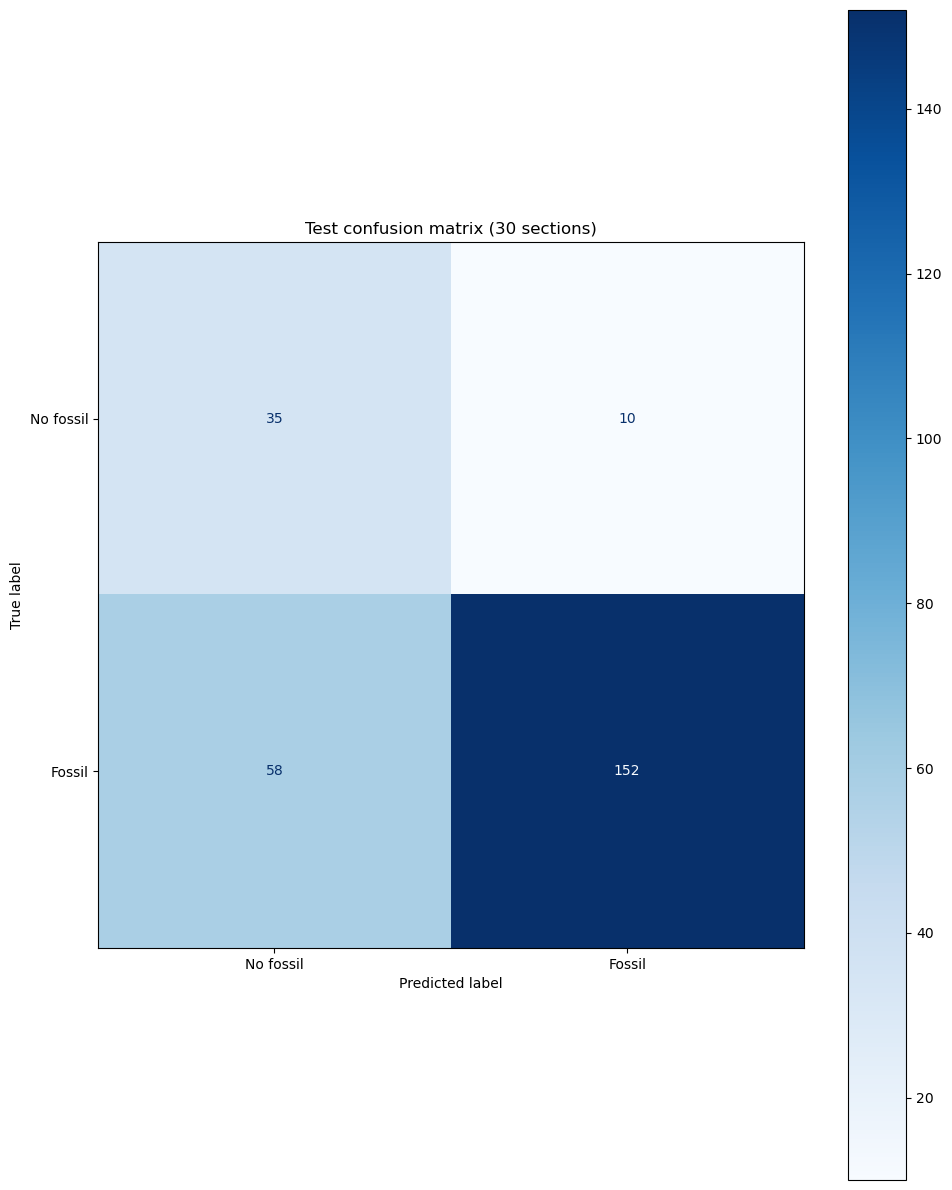

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0', 'opf_81.0', 'opf_41.0', 'opf_11.2', 'ope_39.6', 'opf_81.0', 'opd_89.0', 'ope_37.5', 'ope_18.0', 'ope_101.1', 'ope_54.0', 'opb_34.1', 'ope_30.0', 'ope_34.0', 'ope_86.0', 'opd_12.0', 'opf_44.9', 'ope_101.0', 'opd_49.0', 'ope_70.0', 'opf_81.2', 'opf_51.0', 'opd_84.0', 'opf_93.0', 'ope_74.0', 'opf_22.0', 'ope_50.0', 'opd_59.0', 'opf_85.0', 'opb_41.6', 'opf_26.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opb_41.6_patch3.png'
 '../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_opd_59.0a_patch1.png'
 '../../Data/Center_Fossil/resized_opd_59.0a_patch2.png'
 '../../Data/Center_Fossil/resized_opd_59.0a_patch5.png'
 '../../Data/Center_Fossil/resized_opd_59.0b_patch1.png'
 '../../Data/Center_Fossil/resized_opd_59.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opd_59.0

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - auc: 0.8943 - binary_accuracy: 0.7932 - loss: 0.6605 - precision_1: 0.9484 - recall_1: 0.6871 - specificity_at_sensitivity_1: 0.6471 - val_auc: 0.9110 - val_binary_accuracy: 0.7200 - val_loss: 0.9973 - val_precision_1: 1.0000 - val_recall_1: 0.6693 - val_specificity_at_sensitivity_1: 0.6087
Epoch 2/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - auc: 0.9248 - binary_accuracy: 0.8092 - loss: 0.4944 - precision_1: 0.9807 - recall_1: 0.6905 - specificity_at_sensitivity_1: 0.7304 - val_auc: 0.9238 - val_binary_accuracy: 0.8600 - val_loss: 0.4307 - val_precision_1: 0.9818 - val_recall_1: 0.8504 - val_specificity_at_sensitivity_1: 0.6957
Epoch 3/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 596ms/step - auc: 0.9336 - binary_accuracy: 0.8514 - loss: 0.4693 - precision_1: 0.9583 - recall_1: 0.7823 - specificity_at_sensitivity_1: 0.7843 - val_auc: 0.9298 - val_binary_accuracy: 0.7667 - val_loss: 0.7202 - val_precision_1: 1.0000 - val_rec

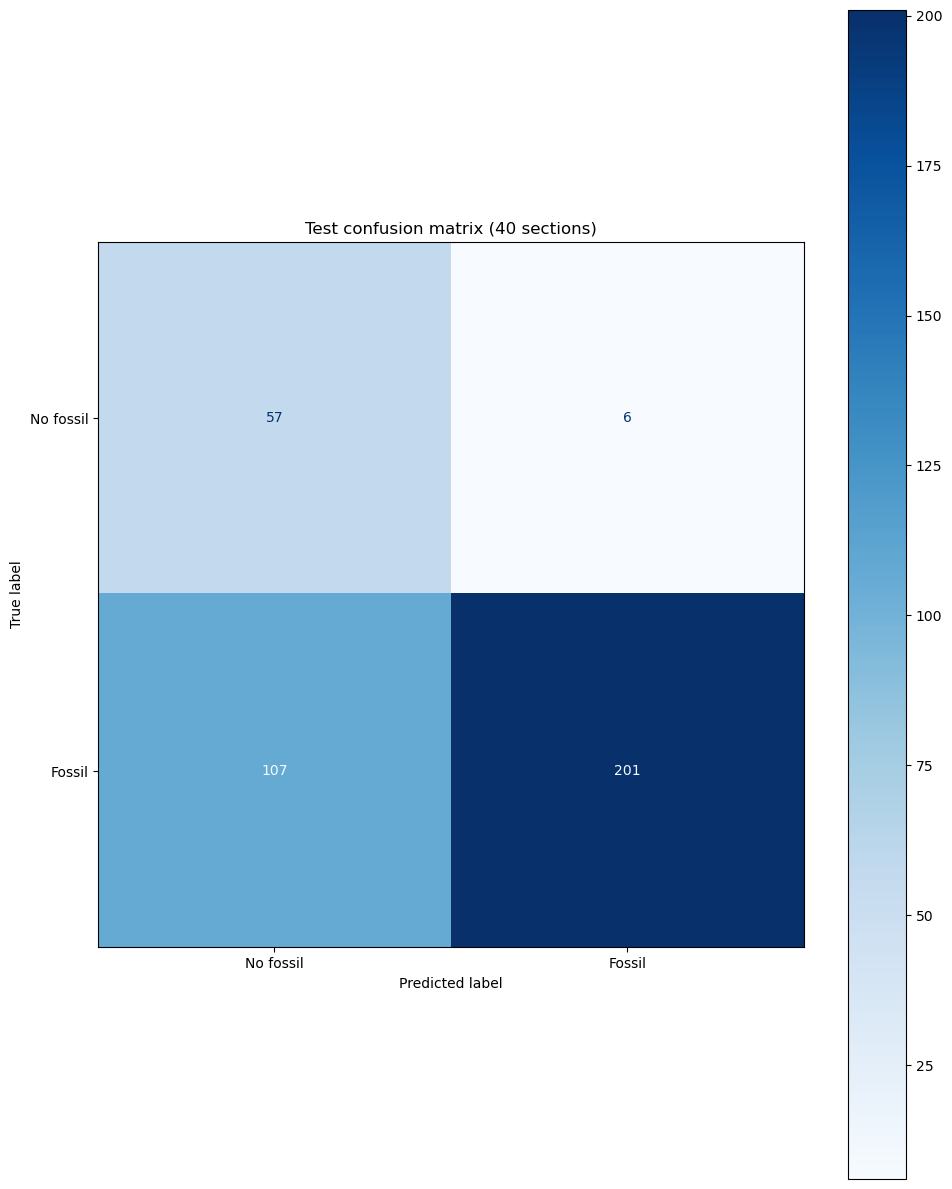

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0', 'opf_81.0', 'opf_41.0', 'opf_11.2', 'ope_39.6', 'opf_81.0', 'opd_89.0', 'ope_37.5', 'ope_18.0', 'ope_101.1', 'ope_54.0', 'opb_34.1', 'ope_30.0', 'ope_34.0', 'ope_86.0', 'opd_12.0', 'opf_44.9', 'ope_101.0', 'opd_49.0', 'ope_70.0', 'opf_81.2', 'opf_51.0', 'opd_84.0', 'opf_93.0', 'ope_74.0', 'opf_22.0', 'ope_50.0', 'opd_59.0', 'opf_85.0', 'opb_41.6', 'opf_26.0', 'opf_7.0', 'ope_78.0', 'ope_66.0', 'opf_0.0', 'opd_76.0', 'opc_7.4', 'opd_26.0', 'opb_15.4', 'opf_73.0', 'opf_2.5']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opb_15.4c_patch2.png'
 '../../Data/Center_Fossil/resized_opb_41.6_patch3.png'
 '../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_opc_7.4_patch2.png'
 '../../Data/Center_Fossil/resized_opd_26.0d_patch1.png'
 '../../Data/Center_Fossil/resized_opd_26.0

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - auc: 0.9399 - binary_accuracy: 0.8297 - loss: 0.4978 - precision_1: 0.9773 - recall_1: 0.7713 - specificity_at_sensitivity_1: 0.8200 - val_auc: 0.8909 - val_binary_accuracy: 0.7523 - val_loss: 0.5223 - val_precision_1: 0.9605 - val_recall_1: 0.7526 - val_specificity_at_sensitivity_1: 0.7500
Epoch 2/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - auc: 0.9560 - binary_accuracy: 0.8328 - loss: 0.3442 - precision_1: 0.9942 - recall_1: 0.7623 - specificity_at_sensitivity_1: 0.8700 - val_auc: 0.8823 - val_binary_accuracy: 0.8073 - val_loss: 0.3779 - val_precision_1: 0.9524 - val_recall_1: 0.8247 - val_specificity_at_sensitivity_1: 0.5833
Epoch 3/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - auc: 0.9545 - binary_accuracy: 0.8638 - loss: 0.4392 - precision_1: 0.9786 - recall_1: 0.8206 - specificity_at_sensitivity_1: 0.8500 - val_auc: 0.8935 - val_binary_accuracy: 0.7706 - val_loss: 0.5031 - val_precision_1: 0.9615 - val_recall

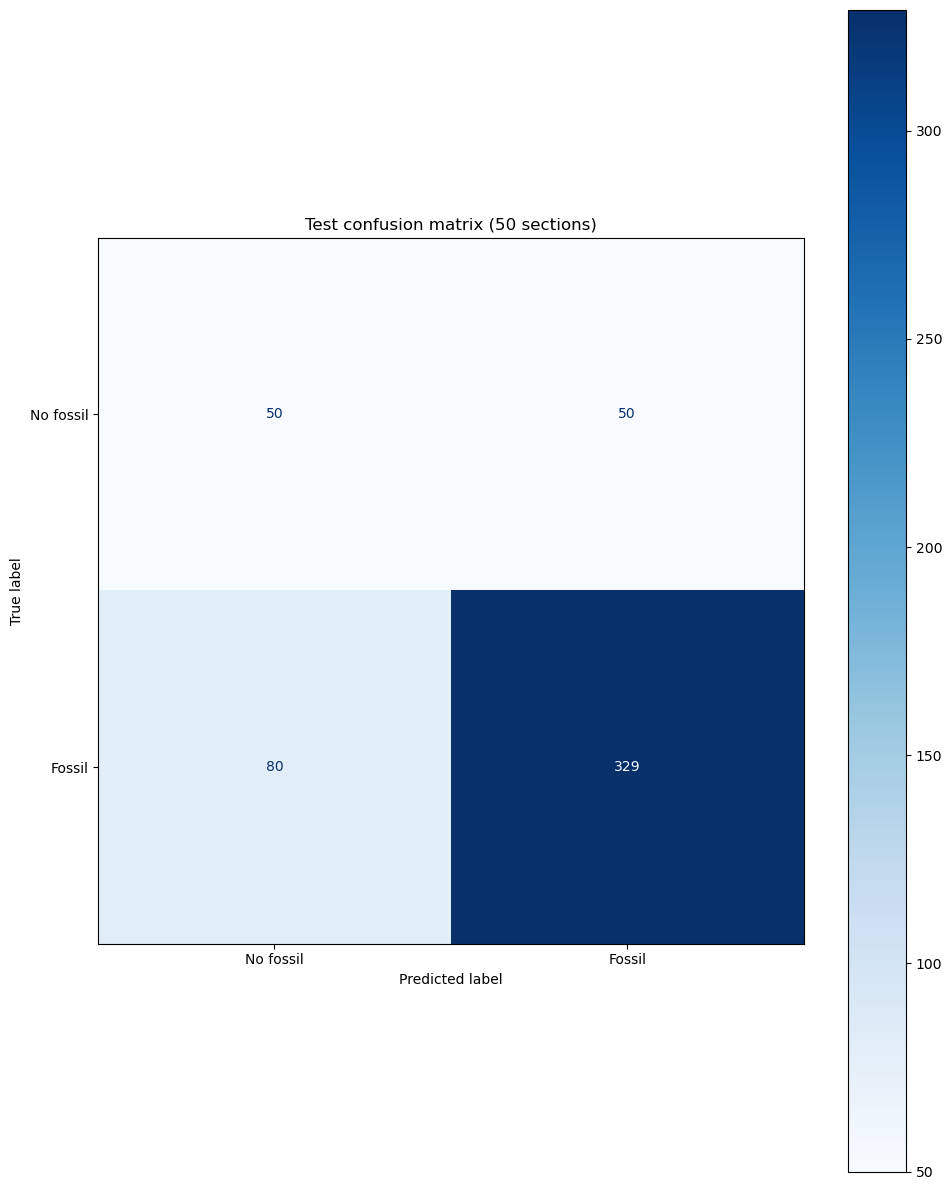

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0', 'opf_81.0', 'opf_41.0', 'opf_11.2', 'ope_39.6', 'opf_81.0', 'opd_89.0', 'ope_37.5', 'ope_18.0', 'ope_101.1', 'ope_54.0', 'opb_34.1', 'ope_30.0', 'ope_34.0', 'ope_86.0', 'opd_12.0', 'opf_44.9', 'ope_101.0', 'opd_49.0', 'ope_70.0', 'opf_81.2', 'opf_51.0', 'opd_84.0', 'opf_93.0', 'ope_74.0', 'opf_22.0', 'ope_50.0', 'opd_59.0', 'opf_85.0', 'opb_41.6', 'opf_26.0', 'opf_7.0', 'ope_78.0', 'ope_66.0', 'opf_0.0', 'opd_76.0', 'opc_7.4', 'opd_26.0', 'opb_15.4', 'opf_73.0', 'opf_2.5', 'opc_0.0', 'opf_85.0', 'opf_14.0', 'opd_0.0', 'opd_64.0', 'ope_26.0', 'ope_2.0', 'opf_5.0', 'ope_94.0', 'ope_62.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opb_15.4c_patch2.png'
 '../../Data/Center_Fossil/resized_opb_41.6_patch3.png'
 '../../Data/Center_Fossil/resized_opc_0.0b_patch1.png'
 '../../Data/Center_Fossil/resized_opc_

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - auc: 0.9395 - binary_accuracy: 0.8291 - loss: 0.7292 - precision_1: 0.9658 - recall_1: 0.7902 - specificity_at_sensitivity_1: 0.8393 - val_auc: 0.9365 - val_binary_accuracy: 0.6857 - val_loss: 1.6303 - val_precision_1: 1.0000 - val_recall_1: 0.6508 - val_specificity_at_sensitivity_1: 0.0000e+00
Epoch 2/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - auc: 0.9549 - binary_accuracy: 0.7688 - loss: 0.6475 - precision_1: 0.9899 - recall_1: 0.6853 - specificity_at_sensitivity_1: 0.9107 - val_auc: 0.9546 - val_binary_accuracy: 0.7571 - val_loss: 0.9545 - val_precision_1: 1.0000 - val_recall_1: 0.7302 - val_specificity_at_sensitivity_1: 1.0000
Epoch 3/8
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - auc: 0.9735 - binary_accuracy: 0.8744 - loss: 0.3541 - precision_1: 0.9917 - recall_1: 0.8322 - specificity_at_sensitivity_1: 0.9821 - val_auc: 0.9580 - val_binary_accuracy: 0.8286 - val_loss: 0.4708 - val_precision_1: 1.0000 - val_recall_1

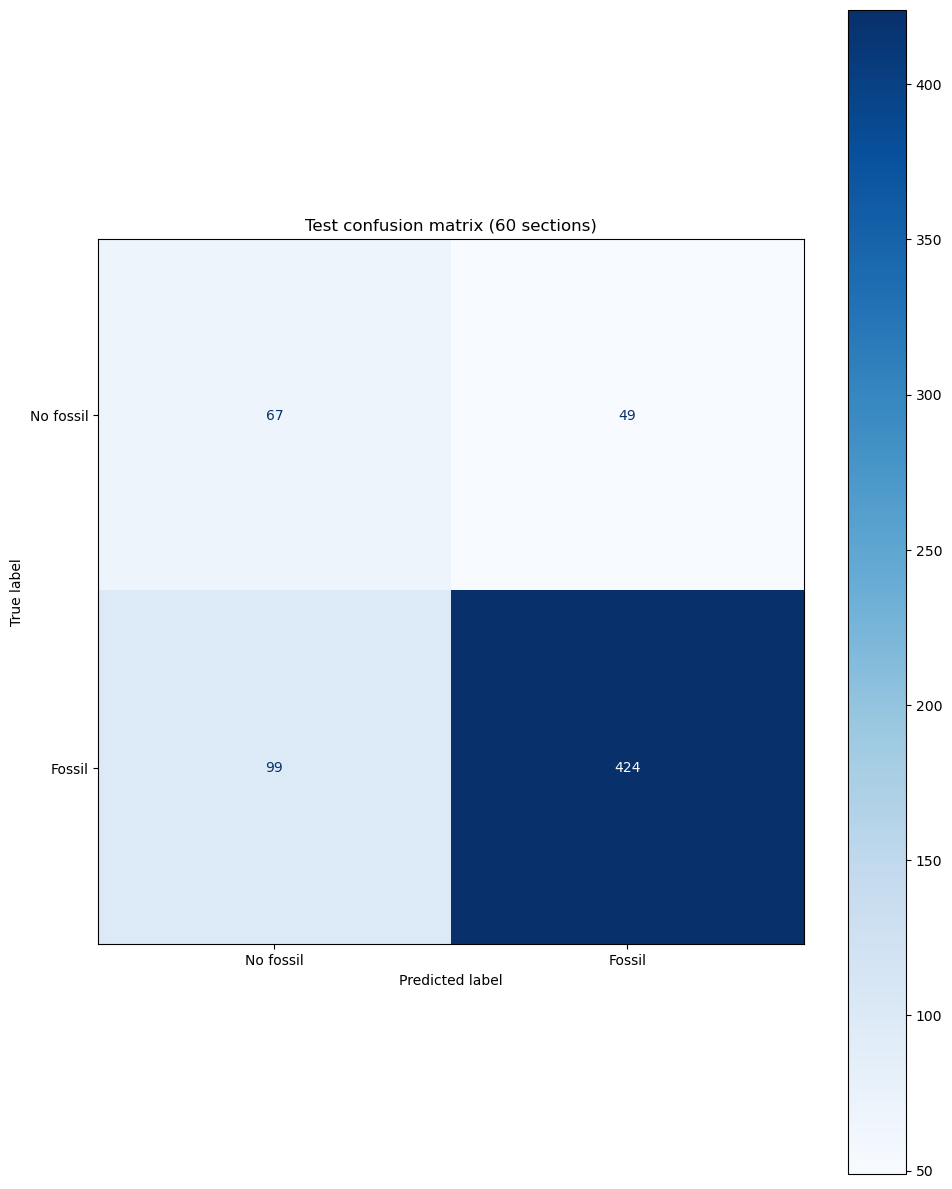

In [17]:
num_sections = [10, 20, 30, 40, 50, 60]
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
center_folder = "../../Data/Center_Fossil"
no_center_fossil_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"
our_layer_histories = []
whole_model_histories = []
test_evals = []
for num_test_sections in num_sections:
    ours, whole_model, eval = model_fit_numbersections_wholepatch_old(num_test_sections)
    our_layer_histories.append(ours)
    whole_model_histories.append(whole_model)
    test_evals.append(eval)

This is the same model as above, except I also augmented some of the fossil data to see if this helps. Once I compare the two, I intend to lower the threshold to 0.5 to see if that helps with the non-fossil classification issue. After that, I plan to train a model on some representative thin sections and then ascertain abundance data. 

In [18]:
# This file path will need to change
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
center_folder = "../../Data/Center_Fossil"
no_center_fossil_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"


def TrainTestValSplit(image_folder, sections):
    test_data_names = []
    remaining_data_names = []

    # List the folder ONCE; each file is checked against ALL sections
    for filename in os.listdir(image_folder):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            filepath = os.path.join(image_folder, filename)
            if any(section in filename for section in sections):
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)

    print(f"Test Data Names from {image_folder}: {np.sort(test_data_names)}")

    # Split remaining data into training and validation sets at random
    random.shuffle(remaining_data_names)
    split = int(len(remaining_data_names) * 0.7)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]
    print(f"Training Data: {np.sort(training_data_names)}")
    print(f"Validation Data: {np.sort(validation_data_names)}")

    # Read in images
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    # Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data

augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25),
    layers.RandomContrast(0.2)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x
def model_fit_numbersections_wholepatch_old(num_test_sections):
    center_folder = "../../Data/Center_Fossil"
    no_center_fossil_folder = "../../Data/No_Center_Fossil"
    no_fossil_folder = "../../Data/No_Fossil"

    #This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
    sections = GetRandomThinSections(image_samples, num_test_sections)
    print(f"Sections Isolated for Testing:")
    print(sections)

    train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
    train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(no_center_fossil_folder, sections)
    train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

    # Now, get label data setting fossils to 1 and no fossil to 0

    Y_train = np.concatenate([np.ones(train_center.shape[0]), np.ones(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
    Y_val = np.concatenate([np.ones(val_center.shape[0]), np.ones(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
    Y_test = np.concatenate([np.ones(test_center.shape[0]), np.ones(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
    training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
    validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
    testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

    # Transform numpy arrays to tf datasets

    training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
    validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
    testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))

    # Shuffle data
    training_data = training_data.shuffle(len(Y_train))
    #validation_data = validation_data.shuffle(len(Y_val))
    #testing_data = testing_data.shuffle(len(Y_test))
    
    # Augment Data
    training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
    )

    nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
    fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

    augfossil = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil2 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil3 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil4 = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    


    training_data = training_data.concatenate(augfossil)
    training_data = training_data.concatenate(augfossil2)
    training_data = training_data.concatenate(augfossil3)
    training_data = training_data.concatenate(augfossil4)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos

    training_data = training_data.shuffle(2*n_pos + 4*n_neg)
    
    n_train = sum(1 for _ in training_data)
    training_data = training_data.apply(tf.data.experimental.assert_cardinality(n_train))
    
    # Batch and prefetch data 

    batch_size = 32 # this could change

    training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)
    testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE)

    n_pos = int(Y_train.sum())
    n_neg = len(Y_train) - n_pos
    class_weight = {0: len(Y_train) / (2 * n_neg), 1: len(Y_train) / (2 * n_pos)}
    print(f"train: {len(Y_train)} samples ({n_pos} pos, {n_neg} neg), class_weight={class_weight}")

    THRESH = 0.55   # change this to whatever cutoff you want
    # Create the base model with the pre-trained imagenet weights
    base_model = keras.applications.Xception(
        weights = 'imagenet',
        input_shape = (200, 200, 3),
        include_top = False) # Why do we not include imagenet at the top? 

    # Freeze the base model weights (they will not be trained)
    base_model.trainable = False

    # Create a new model that goes on top of the base imagenet model
    inputs = keras.Input(shape = (200, 200, 3))
    # We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(1.0, fill_mode="reflect")(x)   # full rotation, black corners
    #x = layers.RandomContrast(0.2)(x)
    #x = layers.RandomBrightness(0.2, value_range=(0, 255))(x)

    x = layers.Rescaling(scale=1/127.5, offset=-1)(x)
    #x = layers.AutoContrast(value_range = (0, 255))(x)
    x = base_model(x, training=False)                         # (batch, 7, 7, 2048)
    # Combine average pooling (overall context) with max pooling (strongest local response)
    avg_pool = layers.GlobalAveragePooling2D()(x)             # (batch, 2048)
    max_pool = layers.GlobalMaxPooling2D()(x)                 # (batch, 2048)
    x = layers.Concatenate()([avg_pool, max_pool])            # (batch, 4096)

    x = layers.Dropout(0.1)(x)
    x = layers.Dense(128, activation="relu")(x)               # hidden layer
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    # Central-region pooling + global context
    #center = layers.Cropping2D(cropping=((3, 3), (3, 3)))(x)  # central 3x3 of the 7x7 map
    #center = layers.GlobalAveragePooling2D()(center)
    #context = layers.GlobalAveragePooling2D()(x)
    #x = layers.Concatenate()([center, context])
    #x = layers.GlobalAveragePooling2D()(x)

   # x = layers.Dropout(0.1)(x)
    #outputs = layers.Dense(1, activation="sigmoid")(x)
    #model = keras.Model(inputs, outputs)

    model.summary(show_trainable = True)

    # Train the new top layer of the model
    model.compile(
        optimizer = keras.optimizers.Adam(), # play with this also
        loss = keras.losses.BinaryCrossentropy(), #check this also
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)]
    )

    epochs = 20 # also play with this
    print(f"Fitting top layer of model")
    early_stop = keras.callbacks.EarlyStopping(
            monitor = "val_auc", mode = "max", patience = 10, restore_best_weights = True)
    
    history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data, class_weight = class_weight, callbacks = [early_stop])

    # Fine tune entire model
    # Fine tune (gently)
    base_model.trainable = True

    # Keep everything frozen except the last 30 layers

    # Keep batch norm layers frozen so the pretrained statistics aren't disturbed
    for layer in base_model.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    model.summary(show_trainable=True)   # now shows the real trainable state

    model.compile(
        optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
        loss = keras.losses.BinaryCrossentropy(),
        metrics = [keras.metrics.BinaryAccuracy(threshold=THRESH), keras.metrics.AUC(name="auc"), keras.metrics.Precision(thresholds=THRESH), keras.metrics.Recall(thresholds=THRESH), keras.metrics.SpecificityAtSensitivity(0.9)] #check this -- we have a binary model so it should be ok
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor = "val_auc", mode = "max", patience = 5, restore_best_weights = True)

    epochs = 8 #??
    print(f"Fitting end-to-end model")
    history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data, callbacks = [early_stop], class_weight = class_weight)
        # Validate model on test data
    print(f"Test dataset evaluation:")
    test_eval = model.evaluate(testing_data)
        # ---- Confusion matrix on the test set ----
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    # Test data is not shuffled, so predictions line up with Y_test
    y_prob = model.predict(testing_data).ravel()
    y_pred = (y_prob >= THRESH).astype(int)
    y_true = Y_test.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion matrix ({num_test_sections} test sections):")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

    fig, ax = plt.subplots(figsize=(10, 12))
    ConfusionMatrixDisplay(cm, display_labels=["No fossil", "Fossil"]).plot(
        ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Test confusion matrix ({num_test_sections} sections)")
    plt.tight_layout()
    plt.show()
    
    del model, base_model, training_data, validation_data, testing_data
    keras.backend.clear_session()
    gc.collect()
    return history_our_layers, history_whole_model, test_eval

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch1.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch2.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch3.png'
 '../../Data/Center_Fossil/resized_ope_58.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch1.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0a_patch5.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_90.0b_patch3.png'
 '../../Data/Center_Fossil/resized_ope_90.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opf_16.0b_patch2.png'
 '../../Data/Center_Fossil/resized_opf_16.0c_patch3.png'
 '../../Data/Center_Fossil/resized_opf_16.0d_patch5.png'
 '../

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip_1     │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation_1 │ (None, 200,     │         0 │ random_flip_1… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - auc: 0.9327 - binary_accuracy: 0.8331 - loss: 0.4295 - precision_1: 0.9662 - recall_1: 0.8004 - specificity_at_sensitivity_1: 0.7623 - val_auc: 0.9344 - val_binary_accuracy: 0.8377 - val_loss: 0.4832 - val_precision_1: 0.9814 - val_recall_1: 0.8229 - val_specificity_at_sensitivity_1: 0.8056
Epoch 2/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 472ms/step - auc: 0.9333 - binary_accuracy: 0.8265 - loss: 0.4738 - precision_1: 0.9658 - recall_1: 0.7915 - specificity_at_sensitivity_1: 0.7809 - val_auc: 0.9408 - val_binary_accuracy: 0.8728 - val_loss: 0.3375 - val_precision_1: 0.9766 - val_recall_1: 0.8698 - val_specificity_at_sensitivity_1: 0.8611
Epoch 3/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 17s 397ms/step - auc: 0.9485 - binary_accuracy: 0.8610 - loss: 0.4327 - precision_1: 0.9725 - recall_1: 0.8341 - specificity_at_sensitivity_1: 0.8796 - val_auc: 0.9263 - val_binary_accuracy: 0.8465 - val_loss: 0.5332 - val_precision_1: 0.9758 - val_

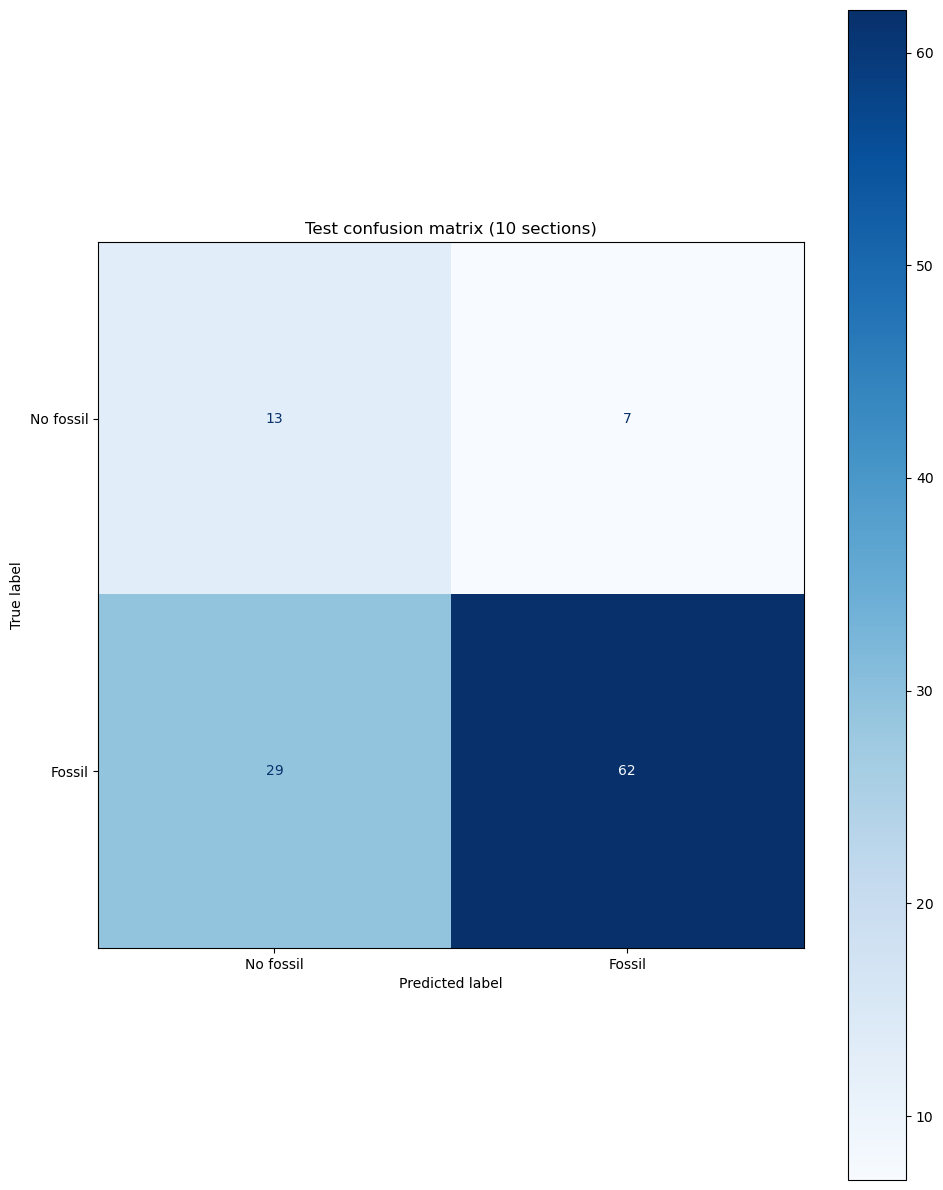

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0', 'opf_81.0', 'opf_41.0', 'opf_11.2', 'ope_39.6', 'opf_81.0', 'opd_89.0', 'ope_37.5', 'ope_18.0', 'ope_101.1', 'ope_54.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_opd_89.0b_patch2.png'
 '../../Data/Center_Fossil/resized_opd_89.0b_patch4.png'
 '../../Data/Center_Fossil/resized_ope_101.1_patch3.png'
 '../../Data/Center_Fossil/resized_ope_101.1_patch5.png'
 '../../Data/Center_Fossil/resized_ope_54.0_patch4.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch1.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch2.png'
 '../../Data/Center_Fossil/resized_ope_58.0a_patch3.png'
 '../../Data/Center_Fossil/resized_ope_58.0b_patch2.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch1.png'
 '../../Data/Center_Fossil/resized_ope_82.0c_patch5.png'

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - auc: 0.9198 - binary_accuracy: 0.8076 - loss: 0.5034 - precision_1: 0.9560 - recall_1: 0.7709 - specificity_at_sensitivity_1: 0.7466 - val_auc: 0.8932 - val_binary_accuracy: 0.8079 - val_loss: 0.4756 - val_precision_1: 0.9521 - val_recall_1: 0.8129 - val_specificity_at_sensitivity_1: 0.5312
Epoch 2/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 590ms/step - auc: 0.9395 - binary_accuracy: 0.8361 - loss: 0.4087 - precision_1: 0.9679 - recall_1: 0.8013 - specificity_at_sensitivity_1: 0.8277 - val_auc: 0.8978 - val_binary_accuracy: 0.8374 - val_loss: 0.4873 - val_precision_1: 0.9600 - val_recall_1: 0.8421 - val_specificity_at_sensitivity_1: 0.6250
Epoch 3/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 432ms/step - auc: 0.9438 - binary_accuracy: 0.8490 - loss: 0.4239 - precision_1: 0.9686 - recall_1: 0.8190 - specificity_at_sensitivity_1: 0.8378 - val_auc: 0.9017 - val_binary_accuracy: 0.8374 - val_loss: 0.4817 - val_precision_1: 0.9539 - val_

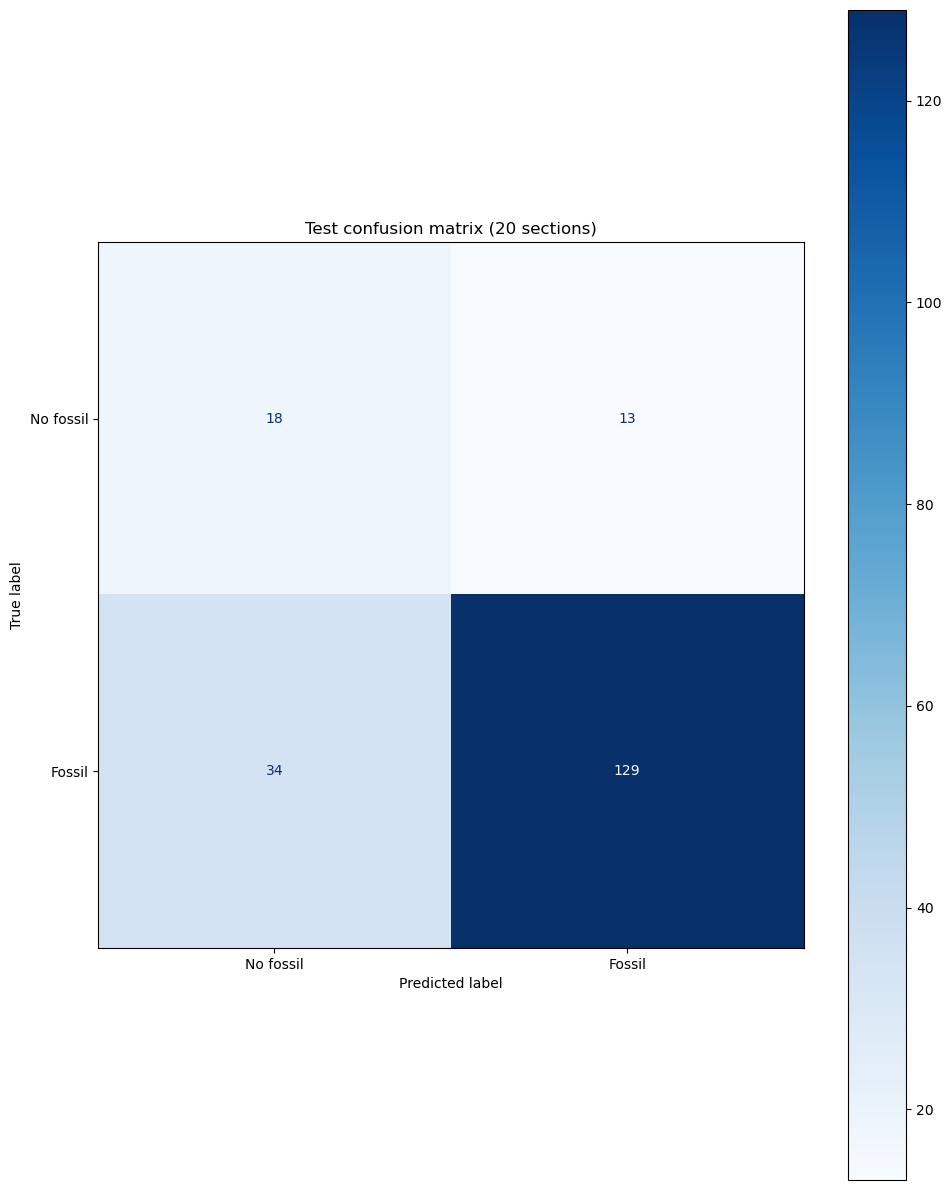

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0', 'opf_81.0', 'opf_41.0', 'opf_11.2', 'ope_39.6', 'opf_81.0', 'opd_89.0', 'ope_37.5', 'ope_18.0', 'ope_101.1', 'ope_54.0', 'opb_34.1', 'ope_30.0', 'ope_34.0', 'ope_86.0', 'opd_12.0', 'opf_44.9', 'ope_101.0', 'opd_49.0', 'ope_70.0', 'opf_81.2']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_opd_89.0b_patch2.png'
 '../../Data/Center_Fossil/resized_opd_89.0b_patch4.png'
 '../../Data/Center_Fossil/resized_ope_101.0(1)_patch1.png'
 '../../Data/Center_Fossil/resized_ope_101.0(1)_patch2.png'
 '../../Data/Center_Fossil/resized_ope_101.0_patch4.png'
 '../../Data/Center_Fossil/resized_ope_101.1_patch3.png'
 '../../Data/Center_Fossil/resized_ope_101.1_patch5.png'
 '../../Data/Center_Fossil/resized_ope_30.0a_patch5.png'
 '../../Data/Center_Fossil/resized_ope_54.

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - auc: 0.8613 - binary_accuracy: 0.7668 - loss: 0.8526 - precision_1: 0.9352 - recall_1: 0.7355 - specificity_at_sensitivity_1: 0.5547 - val_auc: 0.9192 - val_binary_accuracy: 0.8315 - val_loss: 0.5113 - val_precision_1: 0.9845 - val_recall_1: 0.8141 - val_specificity_at_sensitivity_1: 0.7143
Epoch 2/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 22s 650ms/step - auc: 0.8695 - binary_accuracy: 0.7739 - loss: 0.9919 - precision_1: 0.9315 - recall_1: 0.7493 - specificity_at_sensitivity_1: 0.5781 - val_auc: 0.9049 - val_binary_accuracy: 0.8424 - val_loss: 0.6200 - val_precision_1: 0.9635 - val_recall_1: 0.8462 - val_specificity_at_sensitivity_1: 0.5357
Epoch 3/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 431ms/step - auc: 0.8865 - binary_accuracy: 0.7882 - loss: 0.9394 - precision_1: 0.9609 - recall_1: 0.7438 - specificity_at_sensitivity_1: 0.6484 - val_auc: 0.9024 - val_binary_accuracy: 0.7880 - val_loss: 0.8487 - val_precision_1: 0.9916 - val_

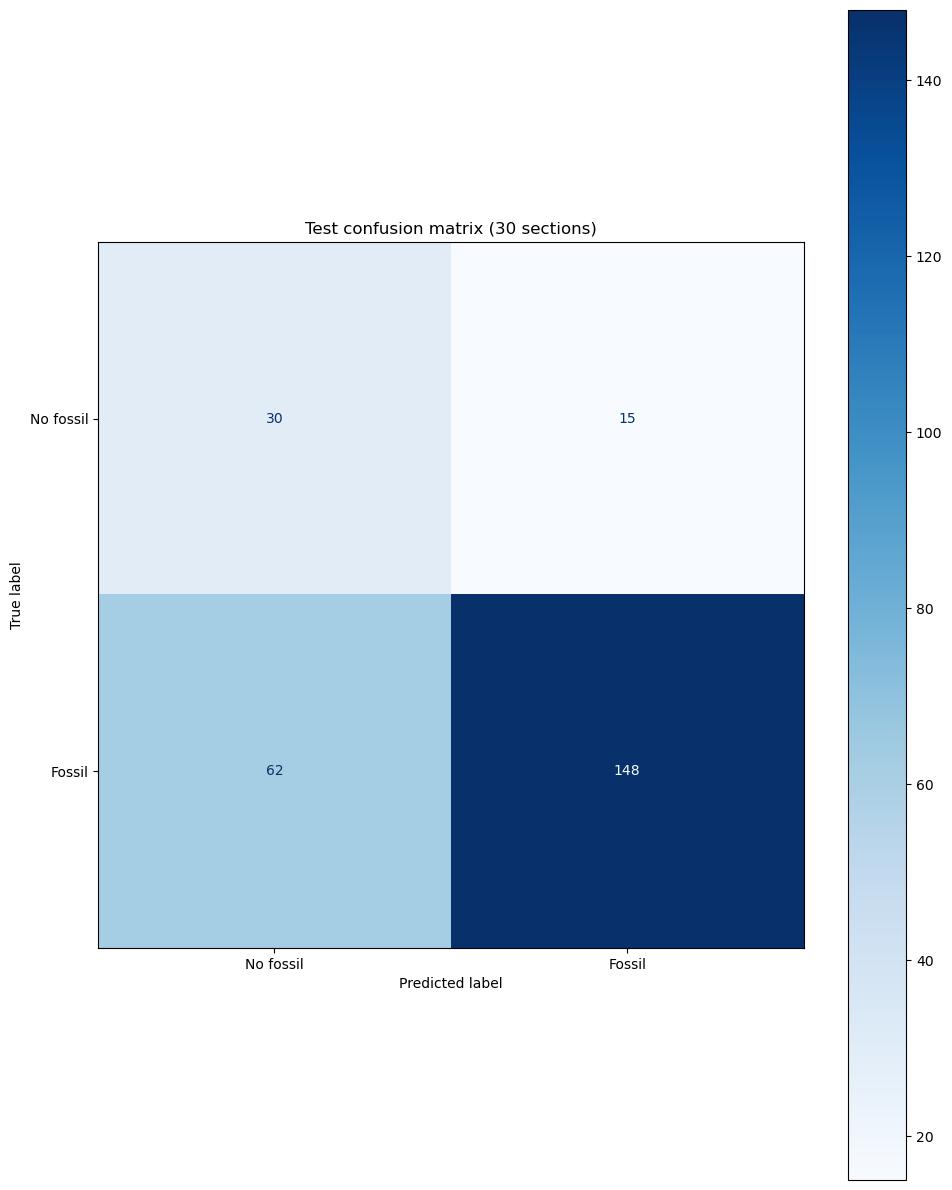

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0', 'opf_81.0', 'opf_41.0', 'opf_11.2', 'ope_39.6', 'opf_81.0', 'opd_89.0', 'ope_37.5', 'ope_18.0', 'ope_101.1', 'ope_54.0', 'opb_34.1', 'ope_30.0', 'ope_34.0', 'ope_86.0', 'opd_12.0', 'opf_44.9', 'ope_101.0', 'opd_49.0', 'ope_70.0', 'opf_81.2', 'opf_51.0', 'opd_84.0', 'opf_93.0', 'ope_74.0', 'opf_22.0', 'ope_50.0', 'opd_59.0', 'opf_85.0', 'opb_41.6', 'opf_26.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opb_41.6_patch3.png'
 '../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_opd_59.0a_patch1.png'
 '../../Data/Center_Fossil/resized_opd_59.0a_patch2.png'
 '../../Data/Center_Fossil/resized_opd_59.0a_patch5.png'
 '../../Data/Center_Fossil/resized_opd_59.0b_patch1.png'
 '../../Data/Center_Fossil/resized_opd_59.0c_patch1.png'
 '../../Data/Center_Fossil/resized_opd_59.0

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - auc: 0.9076 - binary_accuracy: 0.8018 - loss: 0.5716 - precision_1: 0.9634 - recall_1: 0.7619 - specificity_at_sensitivity_1: 0.6520 - val_auc: 0.8959 - val_binary_accuracy: 0.8000 - val_loss: 0.6292 - val_precision_1: 0.9709 - val_recall_1: 0.7874 - val_specificity_at_sensitivity_1: 0.6522
Epoch 2/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 777ms/step - auc: 0.9069 - binary_accuracy: 0.7904 - loss: 0.6712 - precision_1: 0.9509 - recall_1: 0.7568 - specificity_at_sensitivity_1: 0.7010 - val_auc: 0.8826 - val_binary_accuracy: 0.7867 - val_loss: 0.8931 - val_precision_1: 0.9798 - val_recall_1: 0.7638 - val_specificity_at_sensitivity_1: 0.6522
Epoch 3/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 465ms/step - auc: 0.9141 - binary_accuracy: 0.8043 - loss: 0.6200 - precision_1: 0.9482 - recall_1: 0.7789 - specificity_at_sensitivity_1: 0.7353 - val_auc: 0.8846 - val_binary_accuracy: 0.7867 - val_loss: 1.1051 - val_precision_1: 0.9897 - val_

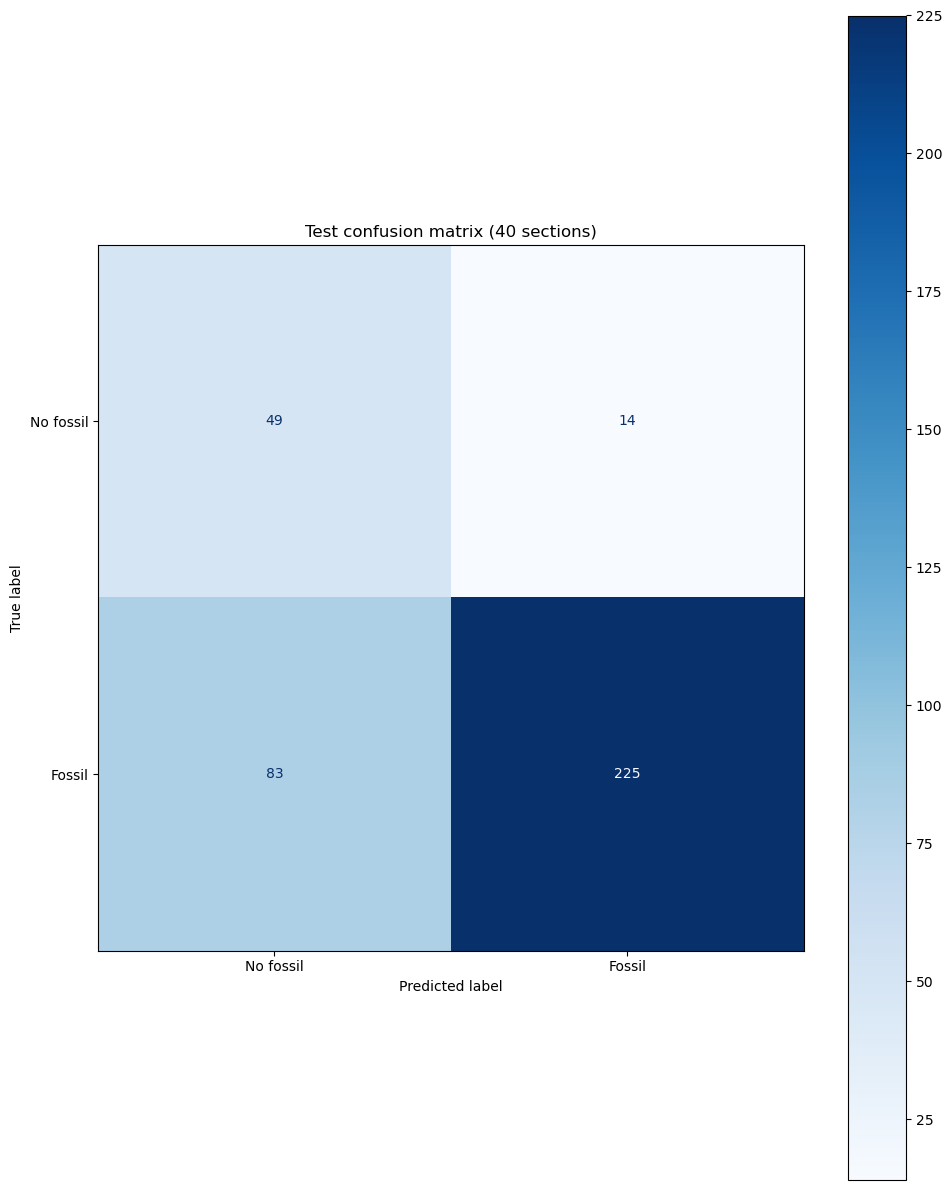

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0', 'opf_81.0', 'opf_41.0', 'opf_11.2', 'ope_39.6', 'opf_81.0', 'opd_89.0', 'ope_37.5', 'ope_18.0', 'ope_101.1', 'ope_54.0', 'opb_34.1', 'ope_30.0', 'ope_34.0', 'ope_86.0', 'opd_12.0', 'opf_44.9', 'ope_101.0', 'opd_49.0', 'ope_70.0', 'opf_81.2', 'opf_51.0', 'opd_84.0', 'opf_93.0', 'ope_74.0', 'opf_22.0', 'ope_50.0', 'opd_59.0', 'opf_85.0', 'opb_41.6', 'opf_26.0', 'opf_7.0', 'ope_78.0', 'ope_66.0', 'opf_0.0', 'opd_76.0', 'opc_7.4', 'opd_26.0', 'opb_15.4', 'opf_73.0', 'opf_2.5']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opb_15.4c_patch2.png'
 '../../Data/Center_Fossil/resized_opb_41.6_patch3.png'
 '../../Data/Center_Fossil/resized_opc_39.6_patch4.png'
 '../../Data/Center_Fossil/resized_opc_7.4_patch2.png'
 '../../Data/Center_Fossil/resized_opd_26.0d_patch1.png'
 '../../Data/Center_Fossil/resized_opd_26.0

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - auc: 0.9551 - binary_accuracy: 0.8462 - loss: 0.4400 - precision_1: 0.9840 - recall_1: 0.8251 - specificity_at_sensitivity_1: 0.8600 - val_auc: 0.8767 - val_binary_accuracy: 0.8807 - val_loss: 0.3689 - val_precision_1: 0.9375 - val_recall_1: 0.9278 - val_specificity_at_sensitivity_1: 0.5000
Epoch 2/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 979ms/step - auc: 0.9590 - binary_accuracy: 0.8828 - loss: 0.3725 - precision_1: 0.9751 - recall_1: 0.8789 - specificity_at_sensitivity_1: 0.8900 - val_auc: 0.8956 - val_binary_accuracy: 0.7890 - val_loss: 0.5743 - val_precision_1: 0.9868 - val_recall_1: 0.7732 - val_specificity_at_sensitivity_1: 0.4167
Epoch 3/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 553ms/step - auc: 0.9805 - binary_accuracy: 0.9231 - loss: 0.2262 - precision_1: 0.9951 - recall_1: 0.9103 - specificity_at_sensitivity_1: 0.9800 - val_auc: 0.8484 - val_binary_accuracy: 0.8807 - val_loss: 0.3704 - val_precision_1: 0.9375 - val_

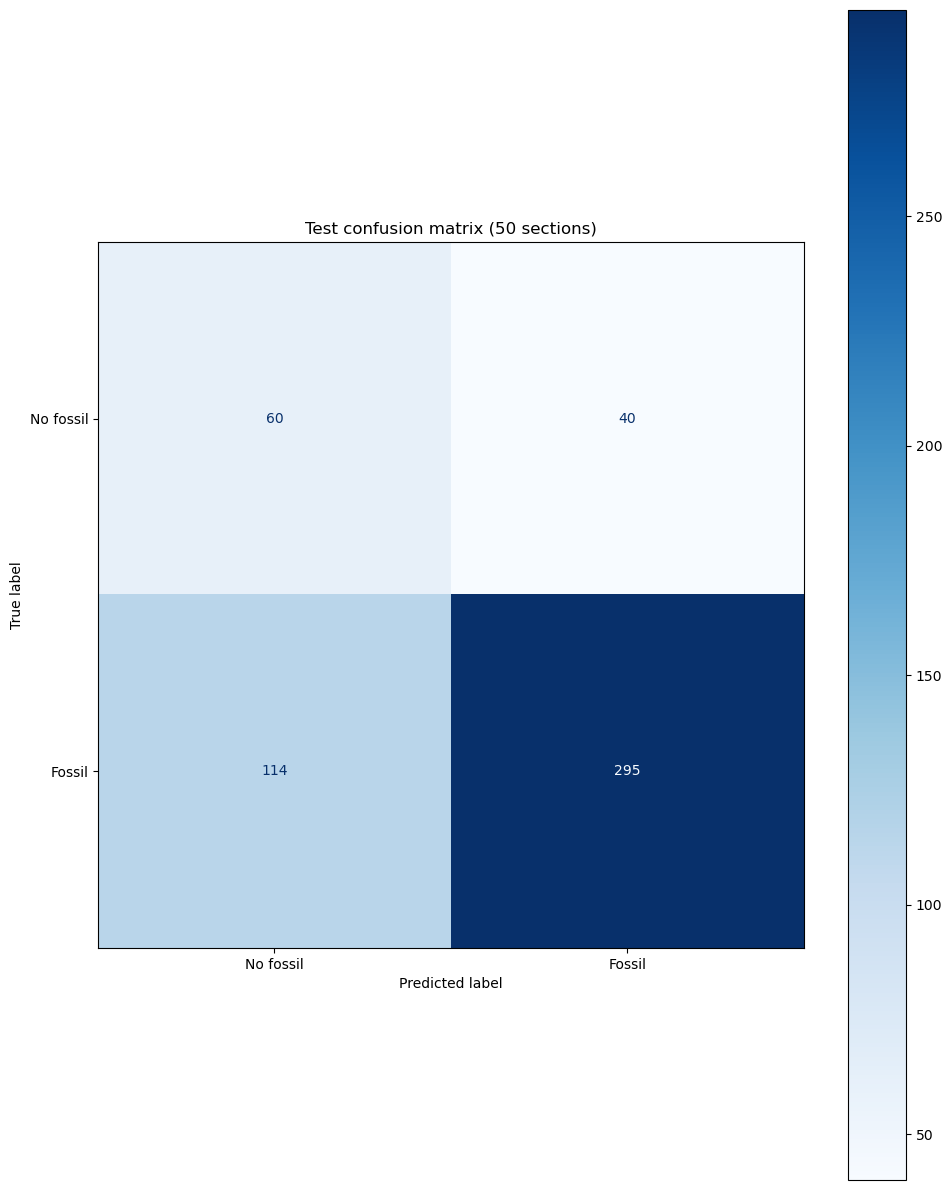

Sections Isolated for Testing:
['opc_39.6', 'opf_69.0', 'ope_90.0', 'opf_9.0', 'ope_58.0', 'opf_37.0', 'opf_16.0', 'opf_97.0', 'opf_33.0', 'ope_82.0', 'opf_81.0', 'opf_41.0', 'opf_11.2', 'ope_39.6', 'opf_81.0', 'opd_89.0', 'ope_37.5', 'ope_18.0', 'ope_101.1', 'ope_54.0', 'opb_34.1', 'ope_30.0', 'ope_34.0', 'ope_86.0', 'opd_12.0', 'opf_44.9', 'ope_101.0', 'opd_49.0', 'ope_70.0', 'opf_81.2', 'opf_51.0', 'opd_84.0', 'opf_93.0', 'ope_74.0', 'opf_22.0', 'ope_50.0', 'opd_59.0', 'opf_85.0', 'opb_41.6', 'opf_26.0', 'opf_7.0', 'ope_78.0', 'ope_66.0', 'opf_0.0', 'opd_76.0', 'opc_7.4', 'opd_26.0', 'opb_15.4', 'opf_73.0', 'opf_2.5', 'opc_0.0', 'opf_85.0', 'opf_14.0', 'opd_0.0', 'opd_64.0', 'ope_26.0', 'ope_2.0', 'opf_5.0', 'ope_94.0', 'ope_62.0']
Test Data Names from ../../Data/Center_Fossil: ['../../Data/Center_Fossil/resized_opb_15.4c_patch2.png'
 '../../Data/Center_Fossil/resized_opb_41.6_patch3.png'
 '../../Data/Center_Fossil/resized_opc_0.0b_patch1.png'
 '../../Data/Center_Fossil/resized_opc_

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1     │ (None, 200,     │         0 │ -              │   -   │
│ (InputLayer)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_flip       │ (None, 200,     │         0 │ input_layer_1… │   -   │
│ (RandomFlip)      │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ random_rotation   │ (None, 200,     │         0 │ random_flip[0… │   -   │
│ (RandomRotation)  │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 200,     │         0 │ random_rotati… │   -   │
│ (Rescaling)       │ 200, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ xception          │ (None, 7, 7,    │ 20,861,4… │ rescaling[0][… │   N   │
│ (Functional)      │ 2048)           │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_average_p… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ global_max_pooli… │ (None, 2048)    │         0 │ xception[0][0] │   -   │
│ (GlobalMaxPoolin… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ concatenate       │ (None, 4096)    │         0 │ global_averag… │   -   │
│ (Concatenate)     │                 │           │ global_max_po… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout (Dropout) │ (None, 4096)    │         0 │ concatenate[0… │   -   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense (Dense)     │ (None, 128)     │   524,416 │ dropout[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_1         │ (None, 128)     │         0 │ dense[0][0]    │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_1 (Dense)   │ (None, 1)       │       129 │ dropout_1[0][… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 21,386,025 (81.58 MB)

 Trainable params: 524,545 (2.00 MB)

...

 Total params: 22,435,117 (85.58 MB)

 Trainable params: 21,276,969 (81.17 MB)

 Non-trainable params: 109,056 (426.00 KB)

 Optimizer params: 1,049,092 (4.00 MB)

Fitting end-to-end model
Epoch 1/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 280s 26s/step - auc: 0.9930 - binary_accuracy: 0.9649 - loss: 0.1510 - precision_1: 0.9928 - recall_1: 0.9650 - specificity_at_sensitivity_1: 0.9821 - val_auc: 0.8696 - val_binary_accuracy: 0.9286 - val_loss: 0.2744 - val_precision_1: 0.9677 - val_recall_1: 0.9524 - val_specificity_at_sensitivity_1: 0.7143
Epoch 2/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - auc: 0.9874 - binary_accuracy: 0.9444 - loss: 0.1749 - precision_1: 0.9963 - recall_1: 0.9371 - specificity_at_sensitivity_1: 0.9821 - val_auc: 0.8719 - val_binary_accuracy: 0.9143 - val_loss: 0.2321 - val_precision_1: 0.9524 - val_recall_1: 0.9524 - val_specificity_at_sensitivity_1: 0.7143
Epoch 3/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 927ms/step - auc: 0.9943 - binary_accuracy: 0.9708 - loss: 0.1343 - precision_1: 0.9929 - recall_1: 0.9720 - specificity_at_sensitivity_1: 0.9821 - val_auc: 0.9444 - val_binary_accuracy: 0.8857 - val_loss: 0.2312 - val_precision_1: 0.9661 - val_r

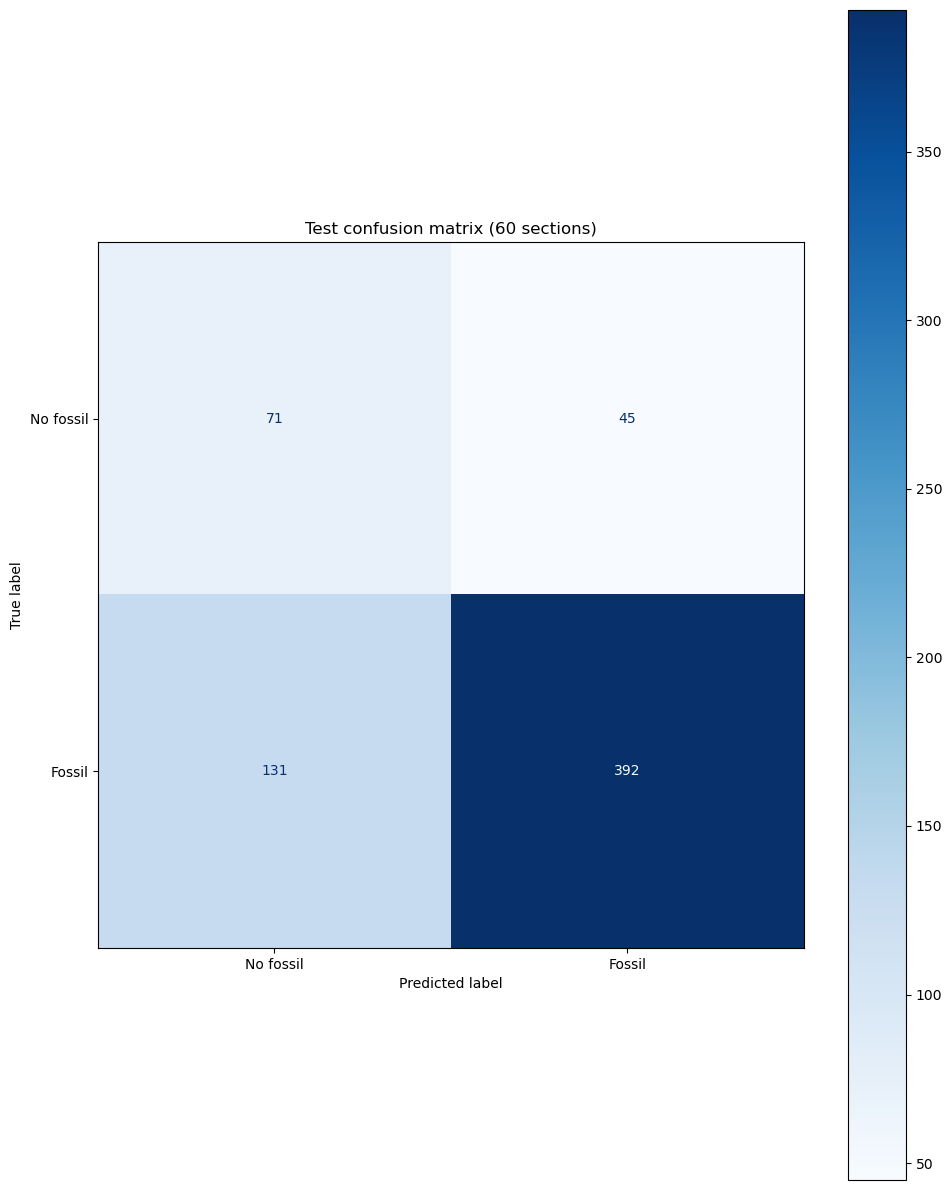

In [19]:
num_sections = [10, 20, 30, 40, 50, 60]
image_samples = pd.read_csv("../../Data/ImageSamples.csv")
center_folder = "../../Data/Center_Fossil"
no_center_fossil_folder = "../../Data/No_Center_Fossil"
no_fossil_folder = "../../Data/No_Fossil"
our_layer_histories = []
whole_model_histories = []
test_evals = []
for num_test_sections in num_sections:
    ours, whole_model, eval = model_fit_numbersections_wholepatch_old(num_test_sections)
    our_layer_histories.append(ours)
    whole_model_histories.append(whole_model)
    test_evals.append(eval)